# 1. STAR NETWORK $S_{n}$ #
### Diffusion on a fuzzy $S_{10}$


         FUZZY STAR NETWORK MATRICES

Fuzzy Adjacency Matrix Af:
[[0.   0.34 0.12 0.74 0.55 0.13 0.13 0.11 0.34 0.38]
 [0.34 0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.12 0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.74 0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.55 0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.13 0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.13 0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.11 0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.34 0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.38 0.   0.   0.   0.   0.   0.   0.   0.   0.  ]]

Fuzzy Degree Matrix Df:
[[2.84 0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.34 0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.12 0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.74 0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.55 0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.13 0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.13 0.   0.   0.  ]
 [0.   0

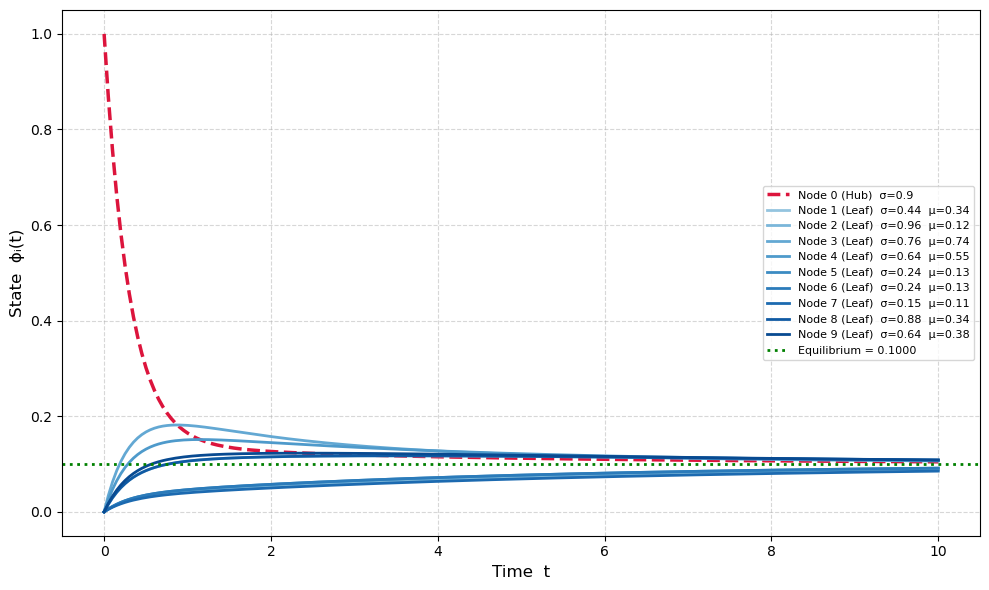

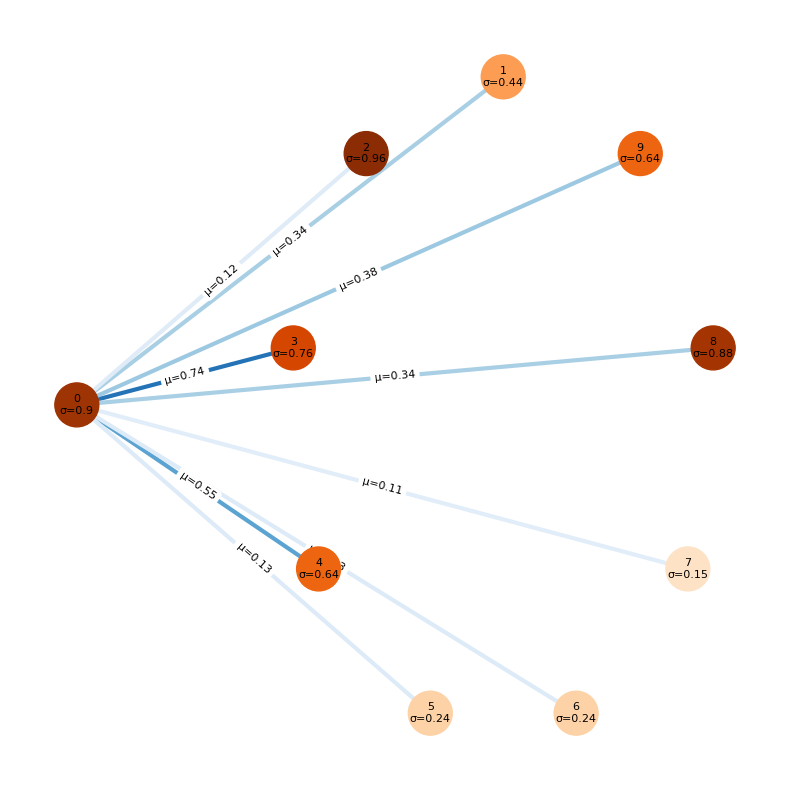


           DIFFUSION SUMMARY
Network        : Fuzzy Star S9  (10 nodes)
Source node    : Hub (Node 0),  ϕ(0) = 1.0
Equilibrium    : 0.1000  (= 1/n)

Final states at t = 10:
  Node 0: ϕ(10) = 0.1046
  Node 1: ϕ(10) = 0.1085
  Node 2: ϕ(10) = 0.0885
  Node 3: ϕ(10) = 0.1063
  Node 4: ϕ(10) = 0.1073
  Node 5: ϕ(10) = 0.0914
  Node 6: ϕ(10) = 0.0914
  Node 7: ϕ(10) = 0.0852
  Node 8: ϕ(10) = 0.1085
  Node 9: ϕ(10) = 0.1084

Edge memberships µ (hub → leaf):
  (0, 1): µ = 0.34  —  slower diffusion
  (0, 2): µ = 0.12  —  slower diffusion
  (0, 3): µ = 0.74  —  faster diffusion
  (0, 4): µ = 0.55  —  faster diffusion
  (0, 5): µ = 0.13  —  slower diffusion
  (0, 6): µ = 0.13  —  slower diffusion
  (0, 7): µ = 0.11  —  slower diffusion
  (0, 8): µ = 0.34  —  slower diffusion
  (0, 9): µ = 0.38  —  slower diffusion


In [2]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.linalg import expm

# ── Parameters ────────────────────────────────────────────────────────────────
NUM_LEAVES  = 9
T_END       = 10
NUM_STEPS   = 200

# ── Step 1: Build the Star Fuzzy Network ──────────────────────────────────────
G = nx.Graph()

# Hub node (node 0) with high membership
G.add_node(0, sigma=0.9)

# Leaf nodes with random membership values σ(v) ∈ (0.1, 1]
np.random.seed(42)
for i in range(1, NUM_LEAVES + 1):
    sigma = round(np.random.uniform(0.1, 1.0), 2)
    G.add_node(i, sigma=sigma)

# Add edges from hub to each leaf, respecting µ(u,v) ≤ min(σ(hub), σ(leaf))
for i in range(1, NUM_LEAVES + 1):
    sigma_hub  = G.nodes[0]['sigma']
    sigma_leaf = G.nodes[i]['sigma']
    max_mu     = min(sigma_hub, sigma_leaf)
    mu         = round(np.random.uniform(0.1, max_mu), 2)
    G.add_edge(0, i, mu=mu)

# ── Step 2: Build the Fuzzy Laplacian Matrix Lf = Df - Af ────────────────────
n     = G.number_of_nodes()
nodes = list(G.nodes())
idx   = {node: i for i, node in enumerate(nodes)}

# Fuzzy adjacency matrix Af
Af = np.zeros((n, n))
for u, v, data in G.edges(data=True):
    i, j     = idx[u], idx[v]
    Af[i][j] = data['mu']
    Af[j][i] = data['mu']

# Fuzzy degree matrix Df
Df = np.diag(Af.sum(axis=1))

# Fuzzy Laplacian
Lf = Df - Af

print("=" * 50)
print("         FUZZY STAR NETWORK MATRICES")
print("=" * 50)
print("\nFuzzy Adjacency Matrix Af:")
print(np.round(Af, 2))
print("\nFuzzy Degree Matrix Df:")
print(np.round(Df, 2))
print("\nFuzzy Laplacian Matrix Lf:")
print(np.round(Lf, 2))

# ── Step 3: Set Initial Conditions ϕ(0) ──────────────────────────────────────
# Hub node starts with all the substance; all leaves start at 0.0
phi0         = np.zeros(n)
phi0[idx[0]] = 1.0

equilibrium = phi0.sum() / n

print(f"\nInitial state ϕ(0)     : {phi0}")
print(f"Theoretical equilibrium : {equilibrium:.4f}  (= 1/n)")

# ── Step 4: Simulate Fuzzy Diffusion ϕ(t) = e^{-t*Lf} ϕ(0) ──────────────────
time_steps = np.linspace(0, T_END, NUM_STEPS)
phi_t      = np.zeros((NUM_STEPS, n))

for k, t in enumerate(time_steps):
    phi_t[k] = expm(-t * Lf) @ phi0

# ── Step 5: Plot Diffusion Curves ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

# Hub node curve
ax.plot(time_steps, phi_t[:, idx[0]],
        label=f"Node 0 (Hub)  σ={G.nodes[0]['sigma']}",
        color='crimson', linewidth=2.5, linestyle='--')

# Leaf node curves — each differs based on its µ value
colors = cm.Blues(np.linspace(0.4, 0.9, NUM_LEAVES))
for i in range(1, NUM_LEAVES + 1):
    mu_val = G[0][i]['mu']
    ax.plot(time_steps, phi_t[:, idx[i]],
            label=f"Node {i} (Leaf)  σ={G.nodes[i]['sigma']}  µ={mu_val}",
            color=colors[i - 1], linewidth=2)

# Equilibrium line
ax.axhline(y=equilibrium, color='green', linestyle=':', linewidth=2,
           label=f"Equilibrium = {equilibrium:.4f}")

ax.set_xlabel("Time  t", fontsize=12)
ax.set_ylabel("State  ϕᵢ(t)", fontsize=12)
#ax.set_title("Diffusion on a Fuzzy S10 Network\n"
            # "ϕ(t) = e^{−tLf} ϕ(0)  |  Source: Hub Node 0", fontsize=11)
ax.legend(fontsize=8, loc='right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("Diffusion_on_fuzzy_S10.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# ── Step 6: Visualise the Star Fuzzy Network ──────────────────────────────────
# ── FIX: nx.star_layout does not exist in any NetworkX version ────────────────
# nx.shell_layout with nlist places:
# — outer shell : all leaf nodes 1..NUM_LEAVES
# — inner shell  : hub node 0 at the centre
# This correctly produces the star topology appearance.

active_edges = [(u, v) for u, v in G.edges()]
edge_mus     = [G[u][v]['mu'] for u, v in active_edges]
edge_colors  = [cm.Blues(mu) for mu in edge_mus]
node_sigmas  = [G.nodes[nd]['sigma'] for nd in G.nodes()]
node_labels  = {nd: f"{nd}\nσ={G.nodes[nd]['sigma']}" for nd in G.nodes()}
edge_labels  = {(u, v): f"µ={G[u][v]['mu']}" for u, v in active_edges}

# ── THE FIX ───────────────────────────────────────────────────────────────────
pos = nx.shell_layout(G, nlist=[list(range(1, NUM_LEAVES + 1)), [0]])

fig2, ax2 = plt.subplots(figsize=(8, 8))

nx.draw_networkx_nodes(G, pos,
                       node_color=node_sigmas,
                       cmap=plt.cm.Oranges,
                       node_size=1000,
                       vmin=0, vmax=1,
                       ax=ax2)

nx.draw_networkx_edges(G, pos,
                       edgelist=active_edges,
                       edge_color=edge_colors,
                       width=3,
                       ax=ax2)

nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8, ax=ax2)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, ax=ax2)

#ax2.set_title(f" Fuzzy S{NUM_LEAVES+1} Network", fontsize=11)
ax2.axis("off")
plt.tight_layout()
plt.savefig("fuzzy_S10_network.pdf", dpi=150, bbox_inches="tight", format='pdf' )
plt.show()

# ── Step 7: Print Final Summary ───────────────────────────────────────────────
print(f"\n{'=' * 50}")
print(f"           DIFFUSION SUMMARY")
print(f"{'=' * 50}")
print(f"Network        : Fuzzy Star S{NUM_LEAVES}  ({n} nodes)")
print(f"Source node    : Hub (Node 0),  ϕ(0) = 1.0")
print(f"Equilibrium    : {equilibrium:.4f}  (= 1/n)")
print(f"\nFinal states at t = {T_END}:")
for node in nodes:
    print(f"  Node {node}: ϕ({T_END}) = {phi_t[-1, idx[node]]:.4f}")
print(f"\nEdge memberships µ (hub → leaf):")
for i in range(1, NUM_LEAVES + 1):
    print(f"  (0, {i}): µ = {G[0][i]['mu']}  —  "
          f"{'faster' if G[0][i]['mu'] > 0.5 else 'slower'} diffusion")

## Diffusion on a fuzzy $S_{20}$

         FUZZY STAR NETWORK MATRICES

Fuzzy Adjacency Matrix Af:
[[0.   0.2  0.59 0.19 0.26 0.15 0.16 0.14 0.26 0.38 0.48 0.1  0.59 0.23
  0.11 0.25 0.26 0.32 0.24 0.14]
 [0.2  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.  ]
 [0.59 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.  ]
 [0.19 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.  ]
 [0.26 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.  ]
 [0.15 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.  ]
 [0.16 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.  ]
 [0.14 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.  ]
 [0.26 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.  ]
 [0.38

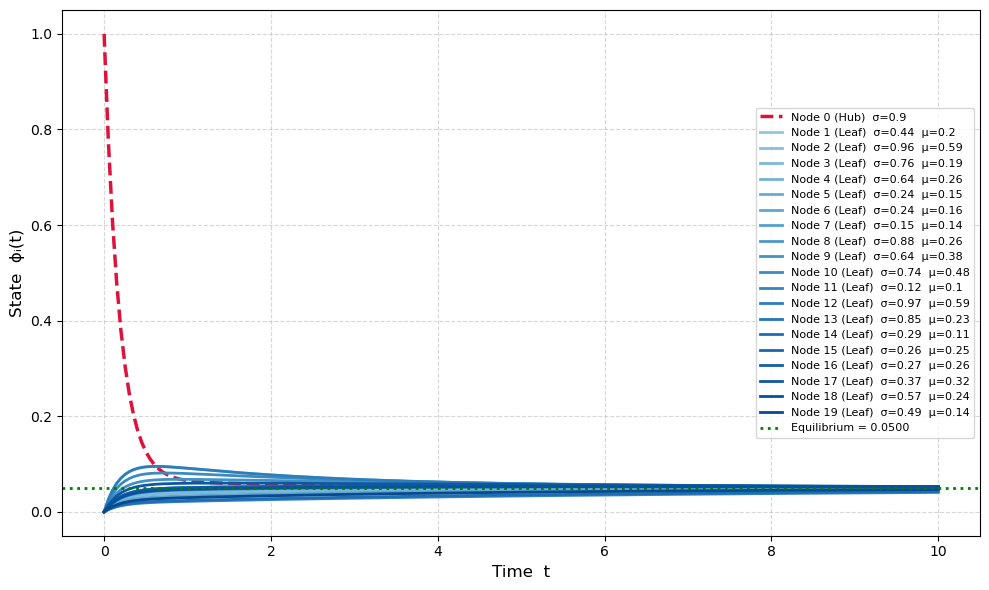

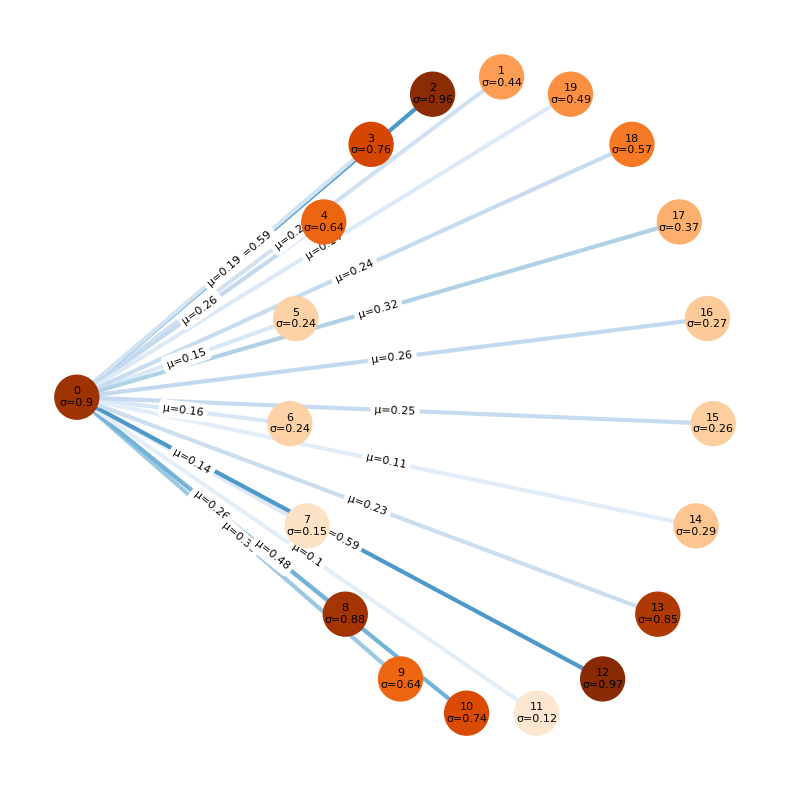


           DIFFUSION SUMMARY
Network        : Fuzzy Star S19  (20 nodes)
Source node    : Hub (Node 0),  ϕ(0) = 1.0
Equilibrium    : 0.0500  (= 1/n)

Final states at t = 10:
  Node 0: ϕ(10) = 0.0512
  Node 1: ϕ(10) = 0.0509
  Node 2: ϕ(10) = 0.0520
  Node 3: ϕ(10) = 0.0504
  Node 4: ϕ(10) = 0.0524
  Node 5: ϕ(10) = 0.0476
  Node 6: ϕ(10) = 0.0485
  Node 7: ϕ(10) = 0.0466
  Node 8: ϕ(10) = 0.0524
  Node 9: ϕ(10) = 0.0527
  Node 10: ϕ(10) = 0.0523
  Node 11: ϕ(10) = 0.0406
  Node 12: ϕ(10) = 0.0520
  Node 13: ϕ(10) = 0.0519
  Node 14: ϕ(10) = 0.0424
  Node 15: ϕ(10) = 0.0523
  Node 16: ϕ(10) = 0.0524
  Node 17: ϕ(10) = 0.0528
  Node 18: ϕ(10) = 0.0521
  Node 19: ϕ(10) = 0.0466

Edge memberships µ (hub → leaf):
  (0, 1): µ = 0.2  —  slower diffusion
  (0, 2): µ = 0.59  —  faster diffusion
  (0, 3): µ = 0.19  —  slower diffusion
  (0, 4): µ = 0.26  —  slower diffusion
  (0, 5): µ = 0.15  —  slower diffusion
  (0, 6): µ = 0.16  —  slower diffusion
  (0, 7): µ = 0.14  —  slower diffusion
  

In [3]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.linalg import expm

# ── Parameters ────────────────────────────────────────────────────────────────
NUM_LEAVES  = 19
T_END       = 10
NUM_STEPS   = 200

# ── Step 1: Build the Star Fuzzy Network ──────────────────────────────────────
G = nx.Graph()

# Hub node (node 0) with high membership
G.add_node(0, sigma=0.9)

# Leaf nodes with random membership values σ(v) ∈ (0.1, 1]
np.random.seed(42)
for i in range(1, NUM_LEAVES + 1):
    sigma = round(np.random.uniform(0.1, 1.0), 2)
    G.add_node(i, sigma=sigma)

# Add edges from hub to each leaf, respecting µ(u,v) ≤ min(σ(hub), σ(leaf))
for i in range(1, NUM_LEAVES + 1):
    sigma_hub  = G.nodes[0]['sigma']
    sigma_leaf = G.nodes[i]['sigma']
    max_mu     = min(sigma_hub, sigma_leaf)
    mu         = round(np.random.uniform(0.1, max_mu), 2)
    G.add_edge(0, i, mu=mu)

# ── Step 2: Build the Fuzzy Laplacian Matrix Lf = Df - Af ────────────────────
n     = G.number_of_nodes()
nodes = list(G.nodes())
idx   = {node: i for i, node in enumerate(nodes)}

# Fuzzy adjacency matrix Af
Af = np.zeros((n, n))
for u, v, data in G.edges(data=True):
    i, j     = idx[u], idx[v]
    Af[i][j] = data['mu']
    Af[j][i] = data['mu']

# Fuzzy degree matrix Df
Df = np.diag(Af.sum(axis=1))

# Fuzzy Laplacian
Lf = Df - Af

print("=" * 50)
print("         FUZZY STAR NETWORK MATRICES")
print("=" * 50)
print("\nFuzzy Adjacency Matrix Af:")
print(np.round(Af, 2))
print("\nFuzzy Degree Matrix Df:")
print(np.round(Df, 2))
print("\nFuzzy Laplacian Matrix Lf:")
print(np.round(Lf, 2))

# ── Step 3: Set Initial Conditions ϕ(0) ──────────────────────────────────────
# Hub node starts with all the substance; all leaves start at 0.0
phi0         = np.zeros(n)
phi0[idx[0]] = 1.0

equilibrium = phi0.sum() / n

print(f"\nInitial state ϕ(0)     : {phi0}")
print(f"Theoretical equilibrium : {equilibrium:.4f}  (= 1/n)")

# ── Step 4: Simulate Fuzzy Diffusion ϕ(t) = e^{-t*Lf} ϕ(0) ──────────────────
time_steps = np.linspace(0, T_END, NUM_STEPS)
phi_t      = np.zeros((NUM_STEPS, n))

for k, t in enumerate(time_steps):
    phi_t[k] = expm(-t * Lf) @ phi0

# ── Step 5: Plot Diffusion Curves ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

# Hub node curve
ax.plot(time_steps, phi_t[:, idx[0]],
        label=f"Node 0 (Hub)  σ={G.nodes[0]['sigma']}",
        color='crimson', linewidth=2.5, linestyle='--')

# Leaf node curves — each differs based on its µ value
colors = cm.Blues(np.linspace(0.4, 0.9, NUM_LEAVES))
for i in range(1, NUM_LEAVES + 1):
    mu_val = G[0][i]['mu']
    ax.plot(time_steps, phi_t[:, idx[i]],
            label=f"Node {i} (Leaf)  σ={G.nodes[i]['sigma']}  µ={mu_val}",
            color=colors[i - 1], linewidth=2)

# Equilibrium line
ax.axhline(y=equilibrium, color='green', linestyle=':', linewidth=2,
           label=f"Equilibrium = {equilibrium:.4f}")

ax.set_xlabel("Time  t", fontsize=12)
ax.set_ylabel("State  ϕᵢ(t)", fontsize=12)
#ax.set_title("Diffusion on a Fuzzy S20 Network\n"
             #"ϕ(t) = e^{−tLf} ϕ(0)  |  Source: Hub Node 0", fontsize=11)
ax.legend(fontsize=8, loc='right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("Diffusion_on_fuzzy_S20.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# ── Step 6: Visualise the Star Fuzzy Network ──────────────────────────────────
# ── FIX: nx.star_layout does not exist in any NetworkX version ────────────────
# nx.shell_layout with nlist places:
# — outer shell : all leaf nodes 1..NUM_LEAVES
# — inner shell  : hub node 0 at the centre
# This correctly produces the star topology appearance.

active_edges = [(u, v) for u, v in G.edges()]
edge_mus     = [G[u][v]['mu'] for u, v in active_edges]
edge_colors  = [cm.Blues(mu) for mu in edge_mus]
node_sigmas  = [G.nodes[nd]['sigma'] for nd in G.nodes()]
node_labels  = {nd: f"{nd}\nσ={G.nodes[nd]['sigma']}" for nd in G.nodes()}
edge_labels  = {(u, v): f"µ={G[u][v]['mu']}" for u, v in active_edges}

# ── THE FIX ───────────────────────────────────────────────────────────────────
pos = nx.shell_layout(G, nlist=[list(range(1, NUM_LEAVES + 1)), [0]])

fig2, ax2 = plt.subplots(figsize=(8, 8))

nx.draw_networkx_nodes(G, pos,
                       node_color=node_sigmas,
                       cmap=plt.cm.Oranges,
                       node_size=1000,
                       vmin=0, vmax=1,
                       ax=ax2)

nx.draw_networkx_edges(G, pos,
                       edgelist=active_edges,
                       edge_color=edge_colors,
                       width=3,
                       ax=ax2)

nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8, ax=ax2)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, ax=ax2)

#ax2.set_title(f"Fuzzy S{NUM_LEAVES+1} Network", fontsize=11)
ax2.axis("off")
plt.tight_layout()
plt.savefig("fuzzy_S20_network.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# ── Step 7: Print Final Summary ───────────────────────────────────────────────
print(f"\n{'=' * 50}")
print(f"           DIFFUSION SUMMARY")
print(f"{'=' * 50}")
print(f"Network        : Fuzzy Star S{NUM_LEAVES}  ({n} nodes)")
print(f"Source node    : Hub (Node 0),  ϕ(0) = 1.0")
print(f"Equilibrium    : {equilibrium:.4f}  (= 1/n)")
print(f"\nFinal states at t = {T_END}:")
for node in nodes:
    print(f"  Node {node}: ϕ({T_END}) = {phi_t[-1, idx[node]]:.4f}")
print(f"\nEdge memberships µ (hub → leaf):")
for i in range(1, NUM_LEAVES + 1):
    print(f"  (0, {i}): µ = {G[0][i]['mu']}  —  "
          f"{'faster' if G[0][i]['mu'] > 0.5 else 'slower'} diffusion")

## Fuzzy Diffusion (Hub Node) Comparison  $S_{10}$ vs $S_{20}$

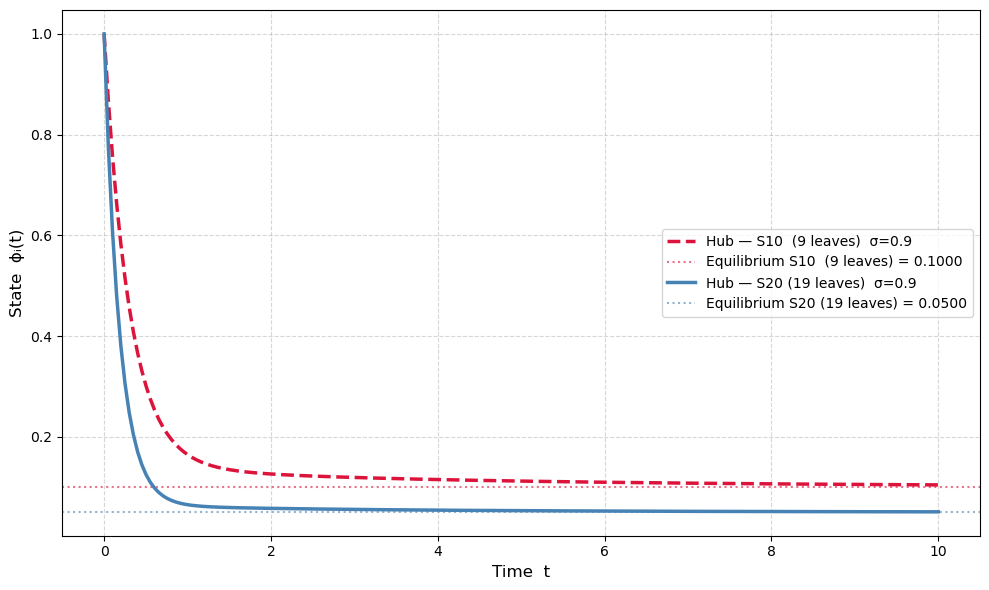

In [4]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

T_END, NUM_STEPS = 10, 200
time_steps = np.linspace(0, T_END, NUM_STEPS)

configs = [
    {"NUM_LEAVES": 9,  "color": "crimson",    "linestyle": "--", "label": "S10  (9 leaves)"},
    {"NUM_LEAVES": 19, "color": "steelblue",  "linestyle": "-",  "label": "S20 (19 leaves)"},
]

fig, ax = plt.subplots(figsize=(10, 6))

for cfg in configs:
    NUM_LEAVES = cfg["NUM_LEAVES"]

    # Build graph
    G = nx.Graph()
    G.add_node(0, sigma=0.9)
    np.random.seed(42)
    for i in range(1, NUM_LEAVES + 1):
        G.add_node(i, sigma=round(np.random.uniform(0.1, 1.0), 2))
    for i in range(1, NUM_LEAVES + 1):
        max_mu = min(G.nodes[0]['sigma'], G.nodes[i]['sigma'])
        G.add_edge(0, i, mu=round(np.random.uniform(0.1, max_mu), 2))

    # Build matrices
    n     = G.number_of_nodes()
    idx   = {node: k for k, node in enumerate(G.nodes())}
    Af    = np.zeros((n, n))
    for u, v, data in G.edges(data=True):
        Af[idx[u]][idx[v]] = Af[idx[v]][idx[u]] = data['mu']
    Lf = np.diag(Af.sum(axis=1)) - Af

    # Simulate
    phi0         = np.zeros(n)
    phi0[idx[0]] = 1.0
    equilibrium  = phi0.sum() / n
    phi_t        = np.array([expm(-t * Lf) @ phi0 for t in time_steps])

    # Plot hub curve
    ax.plot(time_steps, phi_t[:, idx[0]],
            color=cfg["color"], linestyle=cfg["linestyle"], linewidth=2.5,
            label=f"Hub — {cfg['label']}  σ=0.9")

    # Plot equilibrium line
    ax.axhline(y=equilibrium, color=cfg["color"], linestyle=":", linewidth=1.5, alpha=0.6,
               label=f"Equilibrium {cfg['label']} = {equilibrium:.4f}")

ax.set_xlabel("Time  t", fontsize=12)
ax.set_ylabel("State  ϕᵢ(t)", fontsize=12)
#ax.set_title("Comparison of the diffusion between the hub nodes of fuzzy S10 vs S20 ", fontsize=11)
ax.legend(fontsize=10, loc='right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("diffusion_comparison_fuzzy_S10_vs_S20.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

## Diffusion on a Crisps $S_{10}$


Classical Adjacency Matrix A:
[[0. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]

Classical Degree Matrix D:
[[9. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]

Classical Laplacian Matrix L:
[[ 9. -1. -1. -1. -1. -1. -1. -1. -1. -1.]
 [-1.  1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [-1.  0.  1.  0.  0.  0.  0.  0.  0.  0.]
 [-1.  0.  0.  1.  0.  0.  0.  0.  0.  0.]
 [-1.  0.  0.  0.  1.  0.  0.  0.  0.  0.]
 [-1.  0.  0.  0.  0.  1.  0.  0. 

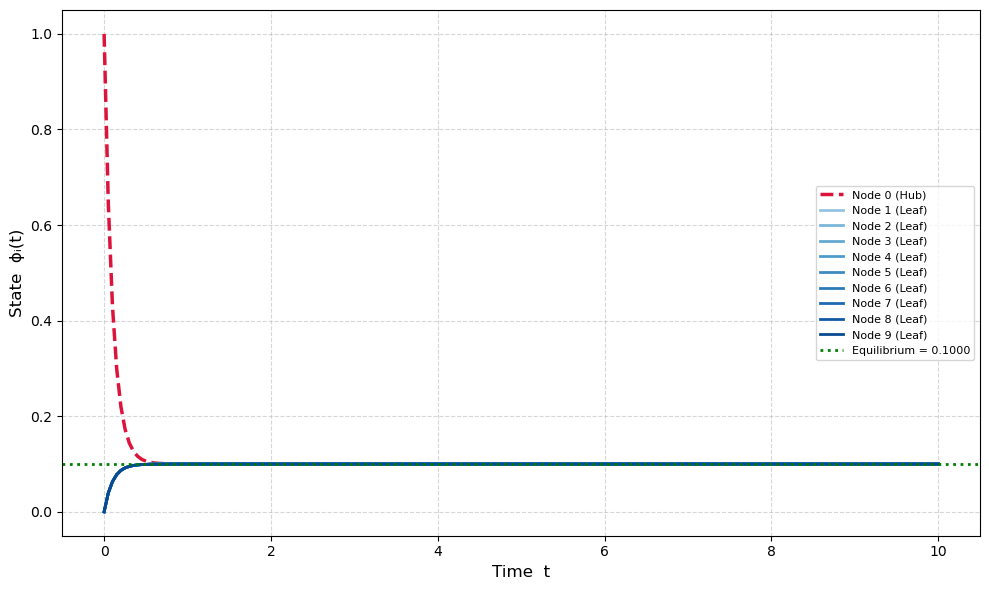

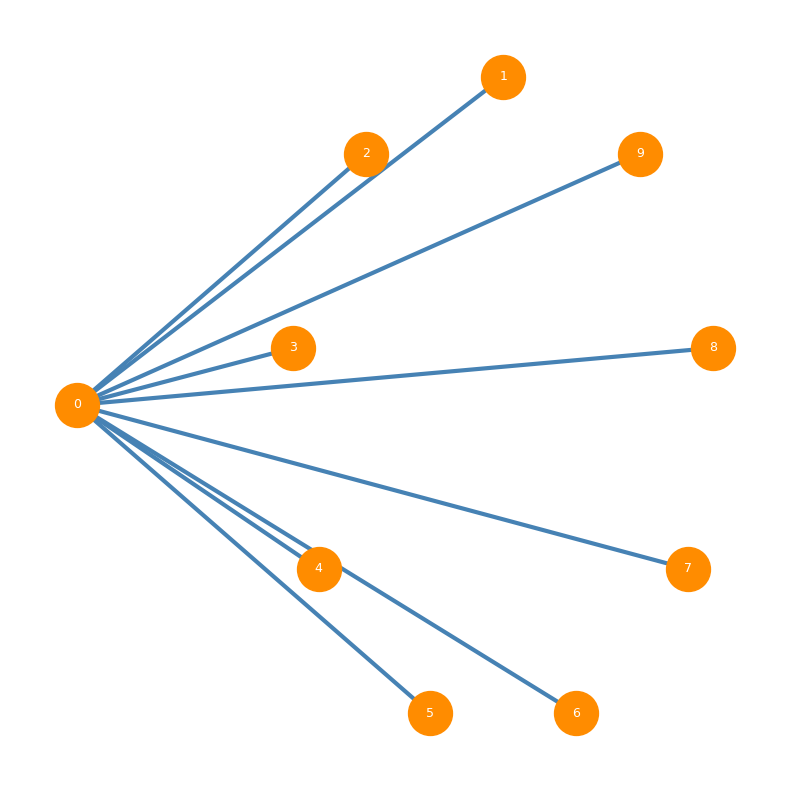


Diffusion Summary
────────────────────────────────────────
Network        : Crisp S9  (10 nodes)
Source node    : Hub (Node 0),  ϕ(0) = 1.0
Diffusion const: C = 1.0
Equilibrium    : 0.1000  (= 1/n)

Final states at t = 10:
  Node 0: ϕ(10) = 0.1000
  Node 1: ϕ(10) = 0.1000
  Node 2: ϕ(10) = 0.1000
  Node 3: ϕ(10) = 0.1000
  Node 4: ϕ(10) = 0.1000
  Node 5: ϕ(10) = 0.1000
  Node 6: ϕ(10) = 0.1000
  Node 7: ϕ(10) = 0.1000
  Node 8: ϕ(10) = 0.1000
  Node 9: ϕ(10) = 0.1000


In [5]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.linalg import expm

# ── Parameters ─────────────────────────────────────────────────────────────────
NUM_LEAVES = 9
T_END      = 10
NUM_STEPS  = 200

# ── Step 1: Build the Crisp Star Network ───────────────────────────────────────
G_crisp = nx.star_graph(NUM_LEAVES)

# ── Step 2: Build the Classical Laplacian L = D - A ───────────────────────────
n     = G_crisp.number_of_nodes()
nodes = list(G_crisp.nodes())
idx   = {node: i for i, node in enumerate(nodes)}

A = np.zeros((n, n))
for u, v in G_crisp.edges():
    i, j    = idx[u], idx[v]
    A[i][j] = 1
    A[j][i] = 1

D = np.diag(A.sum(axis=1))
L = D - A
C = 1.0

print("Classical Adjacency Matrix A:")
print(np.round(A, 2))
print("\nClassical Degree Matrix D:")
print(np.round(D, 2))
print("\nClassical Laplacian Matrix L:")
print(np.round(L, 2))

# ── Step 3: Set Initial Conditions ϕ(0) ───────────────────────────────────────
phi0         = np.zeros(n)
phi0[idx[0]] = 1.0

print(f"\nInitial state ϕ(0): {phi0}")
print(f"Theoretical equilibrium (average): {phi0.sum()/n:.4f}")

# ── Step 4: Simulate Classical Diffusion ϕ(t) = e^{-tCL} ϕ(0) ────────────────
time_steps = np.linspace(0, T_END, NUM_STEPS)
phi_t      = np.zeros((NUM_STEPS, n))

for k, t in enumerate(time_steps):
    phi_t[k] = expm(-C * t * L) @ phi0

equilibrium = phi0.sum() / n

# ── Step 5: Plot Diffusion Curves ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(time_steps, phi_t[:, idx[0]],
        label=f"Node 0 (Hub)",
        color='crimson', linewidth=2.5, linestyle='--')

colors = cm.Blues(np.linspace(0.4, 0.9, NUM_LEAVES))
for i in range(1, NUM_LEAVES + 1):
    ax.plot(time_steps, phi_t[:, idx[i]],
            label=f"Node {i} (Leaf)",
            color=colors[i-1], linewidth=2)

ax.axhline(y=equilibrium, color='green', linestyle=':', linewidth=2,
           label=f"Equilibrium = {equilibrium:.4f}")

ax.set_xlabel("Time  t", fontsize=12)
ax.set_ylabel("State  ϕᵢ(t)", fontsize=12)
#ax.set_title("Diffusion on a Crisps S10 Network\n"
            # "ϕ(t) = e^{−tCL} ϕ(0)  |  Source: Hub Node 0  |  C = 1.0", fontsize=11)
ax.legend(fontsize=8, loc='right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("diffusion_on_a_Crisps_S10.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# ── Step 6: Visualise the Crisp Star Network ───────────────────────────────────
# ── FIX: nx.star_layout does not exist — use nx.shell_layout instead ──────────
# shell_layout places nodes in concentric rings:
# — outer ring: all leaf nodes 1..NUM_LEAVES
# — centre    : hub node 0
# This produces the correct star appearance.

node_labels = {nd: f"{nd}" for nd in G_crisp.nodes()}
pos         = nx.shell_layout(G_crisp,
                              nlist=[list(range(1, NUM_LEAVES + 1)), [0]])

fig2, ax2 = plt.subplots(figsize=(8, 8))

nx.draw_networkx_nodes(G_crisp, pos,
                       node_color='darkorange',
                       node_size=1000,
                       ax=ax2)

nx.draw_networkx_edges(G_crisp, pos,
                       edge_color='steelblue',
                       width=3,
                       ax=ax2)

nx.draw_networkx_labels(G_crisp, pos,
                        labels=node_labels,
                        font_size=9,
                        font_color='white',
                        ax=ax2)

#ax2.set_title(f"Crisp S{NUM_LEAVES+1} Network",
             # fontsize=13)
ax2.axis("off")
plt.tight_layout()
plt.savefig("Crisp_S10_network.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# ── Step 7: Print Final Summary ────────────────────────────────────────────────
print(f"\nDiffusion Summary")
print(f"{'─'*40}")
print(f"Network        : Crisp S{NUM_LEAVES}  ({n} nodes)")
print(f"Source node    : Hub (Node 0),  ϕ(0) = 1.0")
print(f"Diffusion const: C = {C}")
print(f"Equilibrium    : {equilibrium:.4f}  (= 1/n)")
print(f"\nFinal states at t = {T_END}:")
for node in nodes:
    print(f"  Node {node}: ϕ({T_END}) = {phi_t[-1, idx[node]]:.4f}")

## Diffusion on a Crisps $S_{20}$


Classical Adjacency Matrix A:
[[0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.

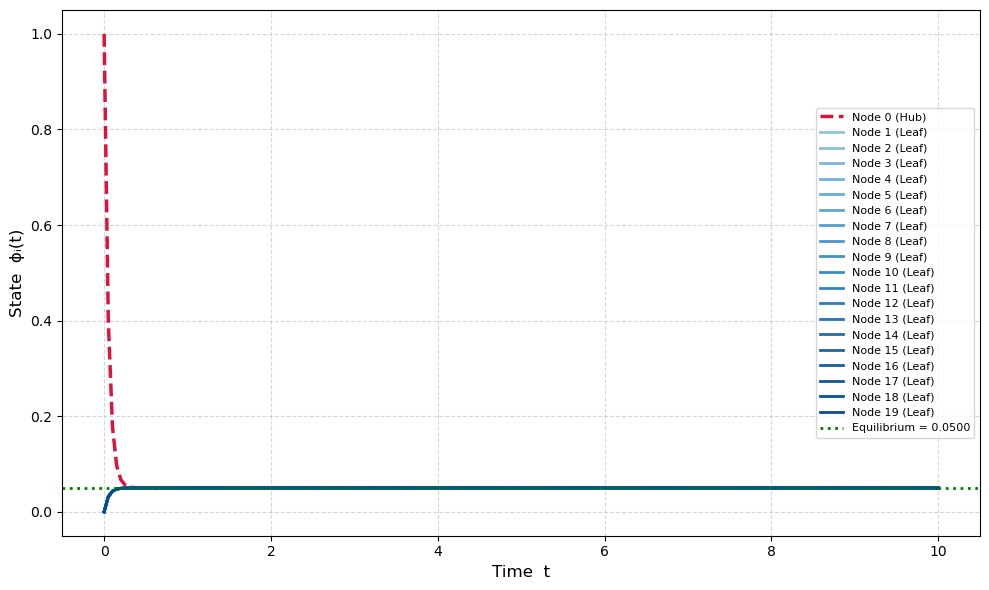

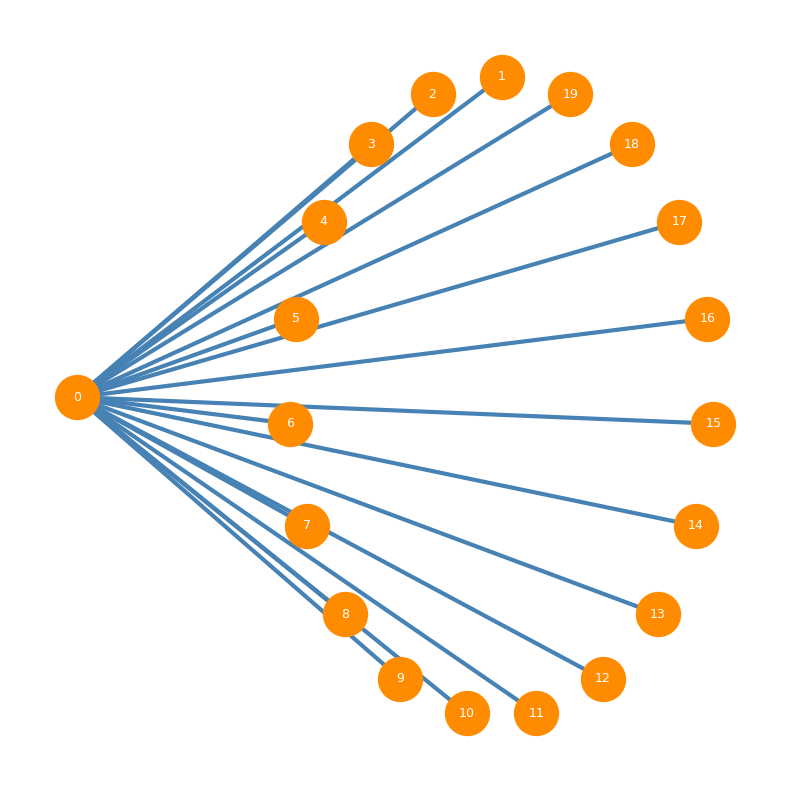


Diffusion Summary
────────────────────────────────────────
Network        : Crisp Star S19  (20 nodes)
Source node    : Hub (Node 0),  ϕ(0) = 1.0
Diffusion const: C = 1.0
Equilibrium    : 0.0500  (= 1/n)

Final states at t = 10:
  Node 0: ϕ(10) = 0.0500
  Node 1: ϕ(10) = 0.0500
  Node 2: ϕ(10) = 0.0500
  Node 3: ϕ(10) = 0.0500
  Node 4: ϕ(10) = 0.0500
  Node 5: ϕ(10) = 0.0500
  Node 6: ϕ(10) = 0.0500
  Node 7: ϕ(10) = 0.0500
  Node 8: ϕ(10) = 0.0500
  Node 9: ϕ(10) = 0.0500
  Node 10: ϕ(10) = 0.0500
  Node 11: ϕ(10) = 0.0500
  Node 12: ϕ(10) = 0.0500
  Node 13: ϕ(10) = 0.0500
  Node 14: ϕ(10) = 0.0500
  Node 15: ϕ(10) = 0.0500
  Node 16: ϕ(10) = 0.0500
  Node 17: ϕ(10) = 0.0500
  Node 18: ϕ(10) = 0.0500
  Node 19: ϕ(10) = 0.0500


In [7]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.linalg import expm

# ── Parameters ─────────────────────────────────────────────────────────────────
NUM_LEAVES = 19
T_END      = 10
NUM_STEPS  = 200

# ── Step 1: Build the Crisp Star Network ───────────────────────────────────────
G_crisp = nx.star_graph(NUM_LEAVES)

# ── Step 2: Build the Classical Laplacian L = D - A ───────────────────────────
n     = G_crisp.number_of_nodes()
nodes = list(G_crisp.nodes())
idx   = {node: i for i, node in enumerate(nodes)}

A = np.zeros((n, n))
for u, v in G_crisp.edges():
    i, j    = idx[u], idx[v]
    A[i][j] = 1
    A[j][i] = 1

D = np.diag(A.sum(axis=1))
L = D - A
C = 1.0

print("Classical Adjacency Matrix A:")
print(np.round(A, 2))
print("\nClassical Degree Matrix D:")
print(np.round(D, 2))
print("\nClassical Laplacian Matrix L:")
print(np.round(L, 2))

# ── Step 3: Set Initial Conditions ϕ(0) ───────────────────────────────────────
phi0         = np.zeros(n)
phi0[idx[0]] = 1.0

print(f"\nInitial state ϕ(0): {phi0}")
print(f"Theoretical equilibrium (average): {phi0.sum()/n:.4f}")

# ── Step 4: Simulate Classical Diffusion ϕ(t) = e^{-tCL} ϕ(0) ────────────────
time_steps = np.linspace(0, T_END, NUM_STEPS)
phi_t      = np.zeros((NUM_STEPS, n))

for k, t in enumerate(time_steps):
    phi_t[k] = expm(-C * t * L) @ phi0

equilibrium = phi0.sum() / n

# ── Step 5: Plot Diffusion Curves ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(time_steps, phi_t[:, idx[0]],
        label=f"Node 0 (Hub)",
        color='crimson', linewidth=2.5, linestyle='--')

colors = cm.Blues(np.linspace(0.4, 0.9, NUM_LEAVES))
for i in range(1, NUM_LEAVES + 1):
    ax.plot(time_steps, phi_t[:, idx[i]],
            label=f"Node {i} (Leaf)",
            color=colors[i-1], linewidth=2)

ax.axhline(y=equilibrium, color='green', linestyle=':', linewidth=2,
           label=f"Equilibrium = {equilibrium:.4f}")

ax.set_xlabel("Time  t", fontsize=12)
ax.set_ylabel("State  ϕᵢ(t)", fontsize=12)
#ax.set_title("Diffusion on a Crisps S20 Network\n"
            # "ϕ(t) = e^{−tCL} ϕ(0)  |  Source: Hub Node 0  |  C = 1.0", fontsize=11)
ax.legend(fontsize=8, loc='right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("Diffusion_on_Crisps_S20.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# ── Step 6: Visualise the Crisp Star Network ───────────────────────────────────
# ── FIX: nx.star_layout does not exist — use nx.shell_layout instead ──────────
# shell_layout places nodes in concentric rings:
# — outer ring: all leaf nodes 1..NUM_LEAVES
# — centre    : hub node 0
# This produces the correct star appearance.

node_labels = {nd: f"{nd}" for nd in G_crisp.nodes()}
pos         = nx.shell_layout(G_crisp,
                              nlist=[list(range(1, NUM_LEAVES + 1)), [0]])

fig2, ax2 = plt.subplots(figsize=(8, 8))

nx.draw_networkx_nodes(G_crisp, pos,
                       node_color='darkorange',
                       node_size=1000,
                       ax=ax2)

nx.draw_networkx_edges(G_crisp, pos,
                       edge_color='steelblue',
                       width=3,
                       ax=ax2)

nx.draw_networkx_labels(G_crisp, pos,
                        labels=node_labels,
                        font_size=9,
                        font_color='white',
                        ax=ax2)

#ax2.set_title(f"Crisp S{NUM_LEAVES+1} Network",
             # fontsize=11)
ax2.axis("off")
plt.tight_layout()
plt.savefig("crisp_S20_network.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# ── Step 7: Print Final Summary ────────────────────────────────────────────────
print(f"\nDiffusion Summary")
print(f"{'─'*40}")
print(f"Network        : Crisp Star S{NUM_LEAVES}  ({n} nodes)")
print(f"Source node    : Hub (Node 0),  ϕ(0) = 1.0")
print(f"Diffusion const: C = {C}")
print(f"Equilibrium    : {equilibrium:.4f}  (= 1/n)")
print(f"\nFinal states at t = {T_END}:")
for node in nodes:
    print(f"  Node {node}: ϕ({T_END}) = {phi_t[-1, idx[node]]:.4f}")

## Crisps Diffusion (Hub Node) Comparison  $S_{10}$ vs $S_{20}$

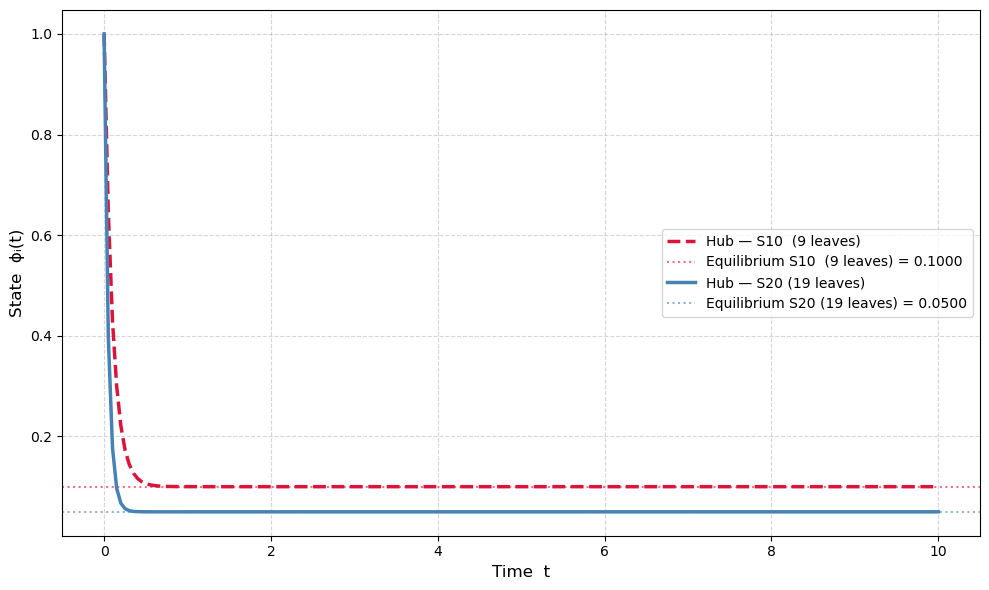

In [8]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

T_END, NUM_STEPS = 10, 200
time_steps = np.linspace(0, T_END, NUM_STEPS)
C = 1.0

configs = [
    {"NUM_LEAVES": 9,  "color": "crimson",   "linestyle": "--", "label": "S10  (9 leaves)"},
    {"NUM_LEAVES": 19, "color": "steelblue", "linestyle": "-",  "label": "S20 (19 leaves)"},
]

fig, ax = plt.subplots(figsize=(10, 6))

for cfg in configs:
    NUM_LEAVES = cfg["NUM_LEAVES"]

    # Build crisp star
    G_crisp = nx.star_graph(NUM_LEAVES)
    n       = G_crisp.number_of_nodes()
    idx     = {node: i for i, node in enumerate(G_crisp.nodes())}

    # Classical Laplacian
    A = np.zeros((n, n))
    for u, v in G_crisp.edges():
        A[idx[u]][idx[v]] = A[idx[v]][idx[u]] = 1
    L = np.diag(A.sum(axis=1)) - A

    # Initial conditions
    phi0         = np.zeros(n)
    phi0[idx[0]] = 1.0
    equilibrium  = phi0.sum() / n

    # Simulate
    phi_t = np.array([expm(-C * t * L) @ phi0 for t in time_steps])

    # Plot
    ax.plot(time_steps, phi_t[:, idx[0]],
            color=cfg["color"], linestyle=cfg["linestyle"], linewidth=2.5,
            label=f"Hub — {cfg['label']}")

    ax.axhline(y=equilibrium, color=cfg["color"], linestyle=":", linewidth=1.5, alpha=0.6,
               label=f"Equilibrium {cfg['label']} = {equilibrium:.4f}")

ax.set_xlabel("Time  t", fontsize=12)
ax.set_ylabel("State  ϕᵢ(t)", fontsize=12)
#ax.set_title("Comparison of the Diffusion between the hub node of a Crisps S10 Vs S20\n"
            # , fontsize=11)
ax.legend(fontsize=10, loc='right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("diffusion_comparison_Crisps S10 vs S20.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

## Diffusion on crisps and fuzzy $S_{10}$ network in one plot

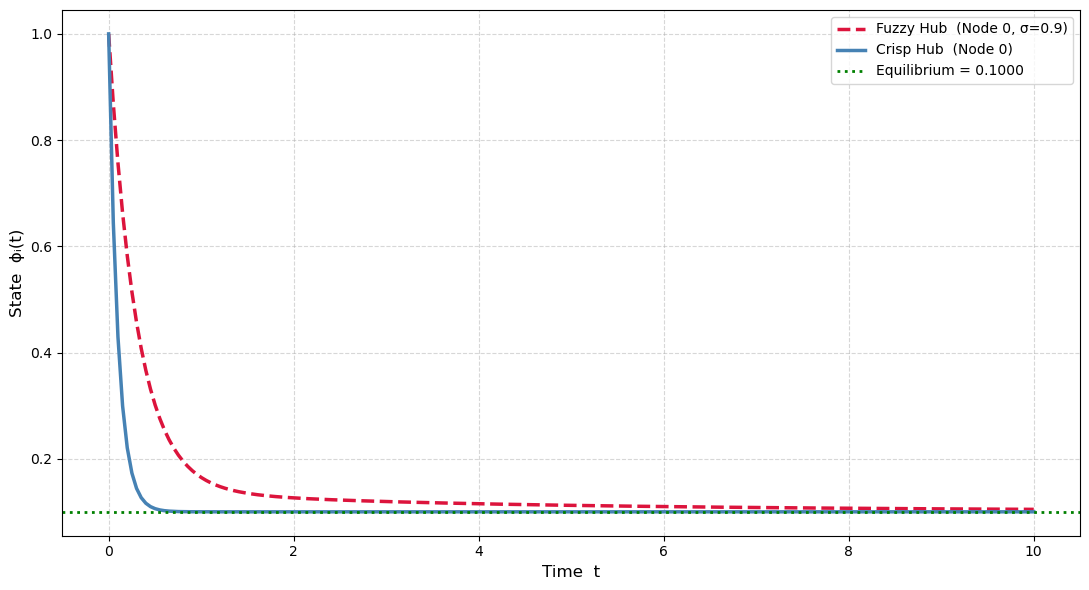

In [9]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

# ── Parameters ─────────────────────────────────────────────────────────────────
NUM_LEAVES = 9
T_END      = 10
NUM_STEPS  = 200
time_steps = np.linspace(0, T_END, NUM_STEPS)

# ══════════════════════════════════════════════════════════════════════════════
# FUZZY NETWORK
# ══════════════════════════════════════════════════════════════════════════════
G = nx.Graph()
G.add_node(0, sigma=0.9)

np.random.seed(42)
for i in range(1, NUM_LEAVES + 1):
    sigma = round(np.random.uniform(0.1, 1.0), 2)
    G.add_node(i, sigma=sigma)

for i in range(1, NUM_LEAVES + 1):
    sigma_hub  = G.nodes[0]['sigma']
    sigma_leaf = G.nodes[i]['sigma']
    max_mu     = min(sigma_hub, sigma_leaf)
    mu         = round(np.random.uniform(0.1, max_mu), 2)
    G.add_edge(0, i, mu=mu)

n_f   = G.number_of_nodes()
idx_f = {node: i for i, node in enumerate(G.nodes())}

Af = np.zeros((n_f, n_f))
for u, v, data in G.edges(data=True):
    i, j     = idx_f[u], idx_f[v]
    Af[i][j] = data['mu']
    Af[j][i] = data['mu']

Df = np.diag(Af.sum(axis=1))
Lf = Df - Af

phi0_f         = np.zeros(n_f)
phi0_f[idx_f[0]] = 1.0
equilibrium_f  = phi0_f.sum() / n_f

phi_t_f = np.zeros((NUM_STEPS, n_f))
for k, t in enumerate(time_steps):
    phi_t_f[k] = expm(-t * Lf) @ phi0_f

# ══════════════════════════════════════════════════════════════════════════════
# CRISP NETWORK
# ══════════════════════════════════════════════════════════════════════════════
G_crisp = nx.star_graph(NUM_LEAVES)
n_c     = G_crisp.number_of_nodes()
nodes_c = list(G_crisp.nodes())
idx_c   = {node: i for i, node in enumerate(nodes_c)}

A = np.zeros((n_c, n_c))
for u, v in G_crisp.edges():
    i, j    = idx_c[u], idx_c[v]
    A[i][j] = 1
    A[j][i] = 1

D = np.diag(A.sum(axis=1))
L = D - A
C = 1.0

phi0_c         = np.zeros(n_c)
phi0_c[idx_c[0]] = 1.0
equilibrium_c  = phi0_c.sum() / n_c

phi_t_c = np.zeros((NUM_STEPS, n_c))
for k, t in enumerate(time_steps):
    phi_t_c[k] = expm(-C * t * L) @ phi0_c

# ══════════════════════════════════════════════════════════════════════════════
# COMBINED PLOT
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(11, 6))

# Fuzzy hub
ax.plot(time_steps, phi_t_f[:, idx_f[0]],
        label=f"Fuzzy Hub  (Node 0, σ={G.nodes[0]['sigma']})",
        color='crimson', linewidth=2.5, linestyle='--')

# Crisp hub
ax.plot(time_steps, phi_t_c[:, idx_c[0]],
        label="Crisp Hub  (Node 0)",
        color='steelblue', linewidth=2.5, linestyle='-')

# Shared equilibrium line (same for both since n and ϕ(0) are identical)
ax.axhline(y=equilibrium_f, color='green', linestyle=':', linewidth=2,
           label=f"Equilibrium = {equilibrium_f:.4f}")

ax.set_xlabel("Time  t", fontsize=12)
ax.set_ylabel("State  ϕᵢ(t)", fontsize=12)
#ax.set_title("Comparison of the Diffusion between the hub node of a Crisps and Fuzzy S10\n"
            # , fontsize=11)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("fuzzy_vs_crisp_diffusion_S10.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

## Diffusion on crisps and fuzzy $S_{20}$ network in one plot

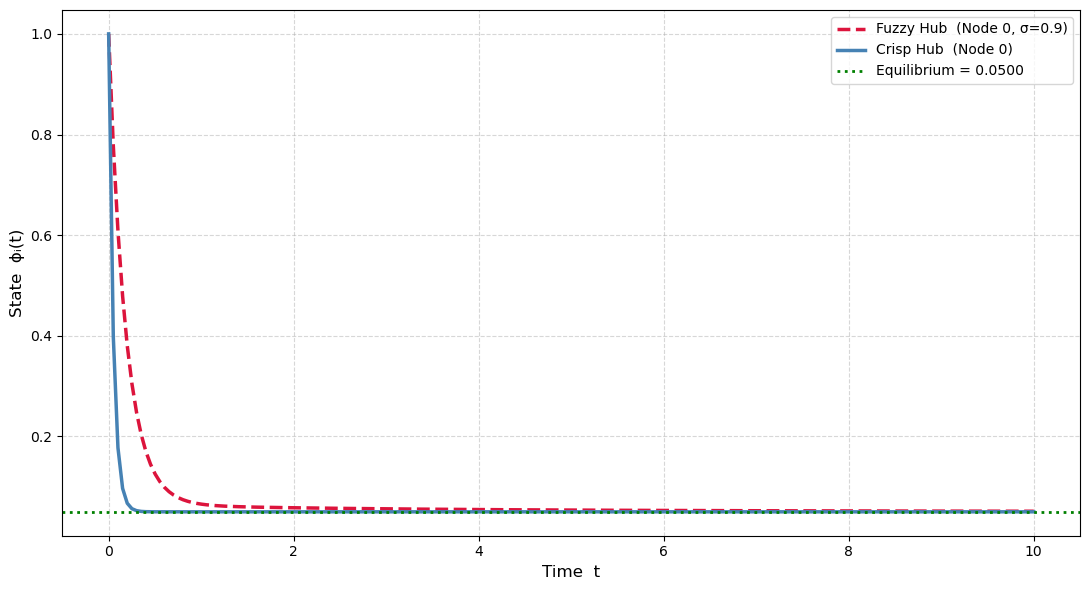

In [10]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

# ── Parameters ─────────────────────────────────────────────────────────────────
NUM_LEAVES = 19
T_END      = 10
NUM_STEPS  = 200
time_steps = np.linspace(0, T_END, NUM_STEPS)

# ══════════════════════════════════════════════════════════════════════════════
# FUZZY NETWORK
# ══════════════════════════════════════════════════════════════════════════════
G = nx.Graph()
G.add_node(0, sigma=0.9)

np.random.seed(42)
for i in range(1, NUM_LEAVES + 1):
    sigma = round(np.random.uniform(0.1, 1.0), 2)
    G.add_node(i, sigma=sigma)

for i in range(1, NUM_LEAVES + 1):
    sigma_hub  = G.nodes[0]['sigma']
    sigma_leaf = G.nodes[i]['sigma']
    max_mu     = min(sigma_hub, sigma_leaf)
    mu         = round(np.random.uniform(0.1, max_mu), 2)
    G.add_edge(0, i, mu=mu)

n_f   = G.number_of_nodes()
idx_f = {node: i for i, node in enumerate(G.nodes())}

Af = np.zeros((n_f, n_f))
for u, v, data in G.edges(data=True):
    i, j     = idx_f[u], idx_f[v]
    Af[i][j] = data['mu']
    Af[j][i] = data['mu']

Df = np.diag(Af.sum(axis=1))
Lf = Df - Af

phi0_f         = np.zeros(n_f)
phi0_f[idx_f[0]] = 1.0
equilibrium_f  = phi0_f.sum() / n_f

phi_t_f = np.zeros((NUM_STEPS, n_f))
for k, t in enumerate(time_steps):
    phi_t_f[k] = expm(-t * Lf) @ phi0_f

# ══════════════════════════════════════════════════════════════════════════════
# CRISP NETWORK
# ══════════════════════════════════════════════════════════════════════════════
G_crisp = nx.star_graph(NUM_LEAVES)
n_c     = G_crisp.number_of_nodes()
nodes_c = list(G_crisp.nodes())
idx_c   = {node: i for i, node in enumerate(nodes_c)}

A = np.zeros((n_c, n_c))
for u, v in G_crisp.edges():
    i, j    = idx_c[u], idx_c[v]
    A[i][j] = 1
    A[j][i] = 1

D = np.diag(A.sum(axis=1))
L = D - A
C = 1.0

phi0_c         = np.zeros(n_c)
phi0_c[idx_c[0]] = 1.0
equilibrium_c  = phi0_c.sum() / n_c

phi_t_c = np.zeros((NUM_STEPS, n_c))
for k, t in enumerate(time_steps):
    phi_t_c[k] = expm(-C * t * L) @ phi0_c

# ══════════════════════════════════════════════════════════════════════════════
# COMBINED PLOT
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(11, 6))

# Fuzzy hub
ax.plot(time_steps, phi_t_f[:, idx_f[0]],
        label=f"Fuzzy Hub  (Node 0, σ={G.nodes[0]['sigma']})",
        color='crimson', linewidth=2.5, linestyle='--')

# Crisp hub
ax.plot(time_steps, phi_t_c[:, idx_c[0]],
        label="Crisp Hub  (Node 0)",
        color='steelblue', linewidth=2.5, linestyle='-')

# Shared equilibrium line (same for both since n and ϕ(0) are identical)
ax.axhline(y=equilibrium_f, color='green', linestyle=':', linewidth=2,
           label=f"Equilibrium = {equilibrium_f:.4f}")

ax.set_xlabel("Time  t", fontsize=12)
ax.set_ylabel("State  ϕᵢ(t)", fontsize=12)
#ax.set_title("Comparison of the Diffusion between the hub node of a Crisps and Fuzzy S20\n"
           # , fontsize=11)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("fuzzy_vs_crisp_diffusion_S20.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# 2. COMPLETE NETWORK $K_{10}$ #
## Diffusion on a crisps $K_{10}$

     CLASSICAL CRISP COMPLETE NETWORK K10

Adjacency Matrix A:
[[0. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 0. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 0. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 0. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 0. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 0. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 0. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 0.]]

Degree Matrix D:
[[9. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 9. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 9. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 9. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 9. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 9. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 9. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 9. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 9. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 9.]]

Laplacian Matrix L:
[[ 9. -1. -1. -1. -1. -1. -1. -1. -1. -1.]
 [-1.  9. -1. -1. -1. -1. -1. -1. -1. -1.]
 [-1. -1.  9. -1. -1. -1. -1. -1. -1. -1.]
 [-1. -1. -1.  9. -1. -1. -1. -1. -1. -1.]
 [-1. -1. -1. -1.  9. -1. -1. -1. -1. -1.]
 [-1. -1. -1. -1. -1.

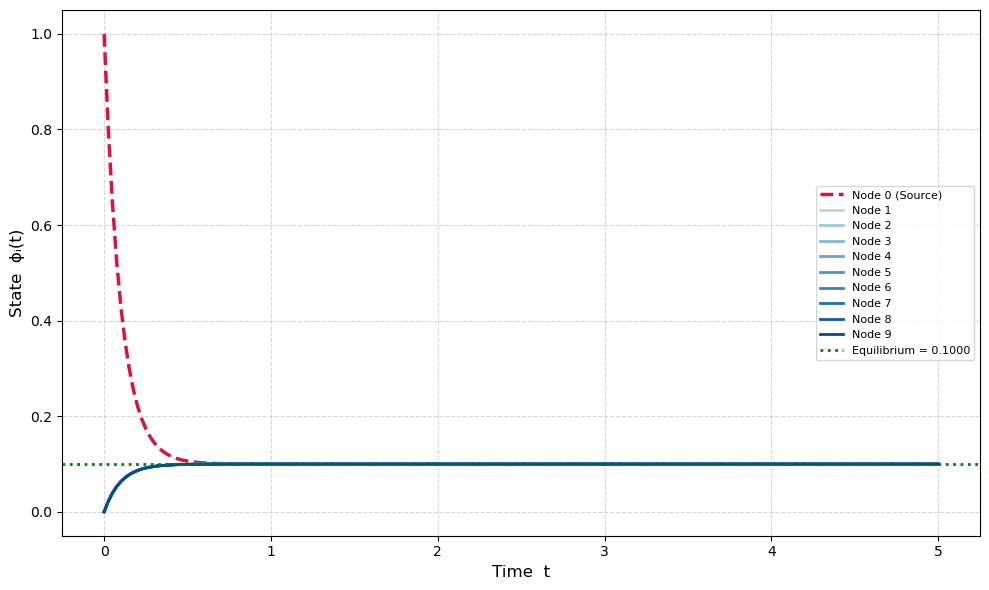

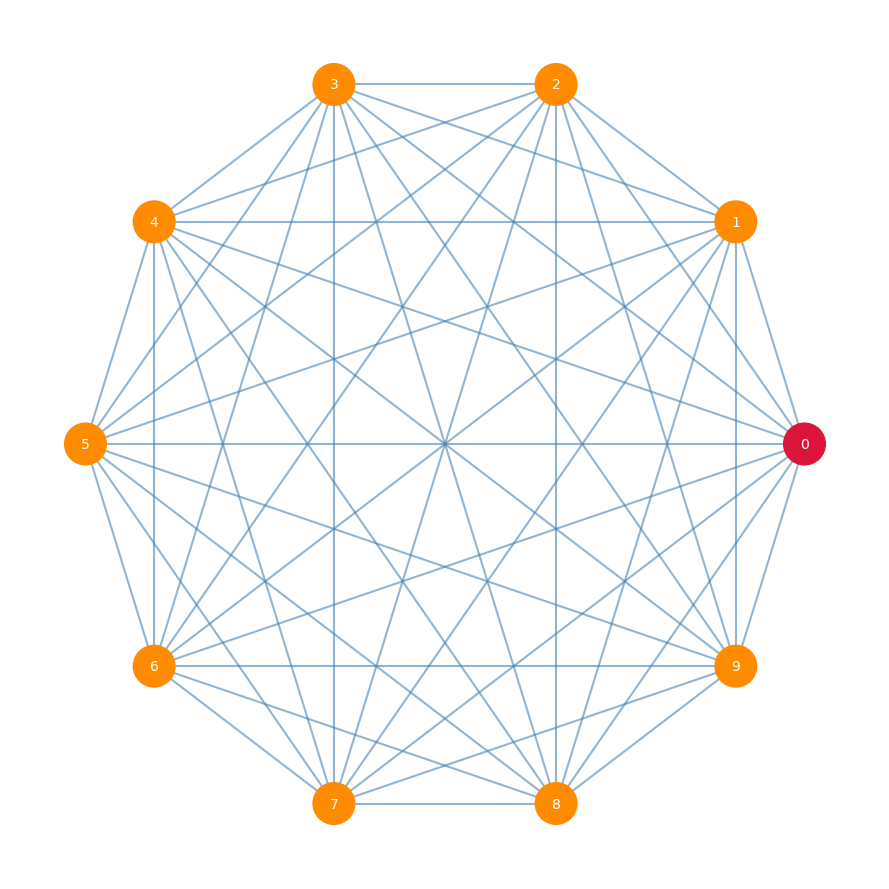


              DIFFUSION SUMMARY
Network         : Crisp Complete K10  (10 nodes)
Source node     : Node 0,  ϕ(0) = 1.0
Diffusion const : C = 1.0
Node degree     : 9  (every node connected to all others)
Equilibrium     : 0.1000  (= 1/n = 1/10)

Final states at t = 5:
  Node 0: ϕ(5) = 0.1000
  Node 1: ϕ(5) = 0.1000
  Node 2: ϕ(5) = 0.1000
  Node 3: ϕ(5) = 0.1000
  Node 4: ϕ(5) = 0.1000
  Node 5: ϕ(5) = 0.1000
  Node 6: ϕ(5) = 0.1000
  Node 7: ϕ(5) = 0.1000
  Node 8: ϕ(5) = 0.1000
  Node 9: ϕ(5) = 0.1000

Key Observation:
  All 9 non-source nodes have identical diffusion curves
  because every node has degree 9 and every edge weight = 1.
  Diffusion is very fast due to direct connections between all nodes.
  This extreme symmetry is a fundamental limitation of the crisp model.


In [18]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.linalg import expm

# ── Parameters ─────────────────────────────────────────────────────────────────
# A complete network on 10 nodes means every pair of nodes is connected.
# From Definition 2.2.1 (Category b): a complete network Kn has every pair
# of nodes adjacent to each other.
NUM_NODES  = 10
T_END      = 5
NUM_STEPS  = 200
C          = 1.0      # diffusion constant

# ── Step 1: Build the Crisp Complete Network ───────────────────────────────────
# nx.complete_graph(n) builds Kn — every node connected to every other node.
# All edges are binary (weight = 1) as per classical network definition.

G_crisp = nx.complete_graph(NUM_NODES)

# ── Step 2: Build Classical Matrices A, D, L ───────────────────────────────────
# A — binary adjacency matrix: Aij = 1 if edge exists, 0 otherwise
# D — degree matrix: diagonal matrix of node degrees
# L — classical Laplacian: L = D - A (Section 2.3.5)
# In a complete network K10, every node has degree n-1 = 9

n     = G_crisp.number_of_nodes()
nodes = list(G_crisp.nodes())
idx   = {node: i for i, node in enumerate(nodes)}

# Binary adjacency matrix
A = np.zeros((n, n))
for u, v in G_crisp.edges():
    i, j    = idx[u], idx[v]
    A[i][j] = 1
    A[j][i] = 1              # symmetric — undirected

# Degree matrix
D = np.diag(A.sum(axis=1))

# Classical Laplacian
L = D - A

print("=" * 55)
print("     CLASSICAL CRISP COMPLETE NETWORK K10")
print("=" * 55)
print("\nAdjacency Matrix A:")
print(np.round(A, 2))
print("\nDegree Matrix D:")
print(np.round(D, 2))
print("\nLaplacian Matrix L:")
print(np.round(L, 2))

# ── Step 3: Set Initial Conditions ϕ(0) ───────────────────────────────────────
# Node 0 is the single source — starts with all the substance (value = 1.0).
# All other nodes start at 0.0.
# From equation (3.2.8): ϕ(t) = e^{-CtL} ϕ(0)

phi0         = np.zeros(n)
phi0[idx[0]] = 1.0

equilibrium  = phi0.sum() / n     # Theorem 3.3.2: all nodes converge to average

print(f"\nInitial state ϕ(0)     : {phi0}")
print(f"Theoretical equilibrium : {equilibrium:.4f}  (= 1/n = 1/{n})")

# ── Step 4: Simulate Classical Diffusion ϕ(t) = e^{-CtL} ϕ(0) ────────────────
# In a complete network, diffusion is extremely fast because every node is
# directly connected to every other node — no intermediate hops needed.

time_steps = np.linspace(0, T_END, NUM_STEPS)
phi_t      = np.zeros((NUM_STEPS, n))

for k, t in enumerate(time_steps):
    phi_t[k] = expm(-C * t * L) @ phi0

# ── Step 5: Plot Diffusion Curves ──────────────────────────────────────────────
# In a complete crisp network all non-source nodes behave identically because
# every node has the same degree (n-1) and the same edge weight (1).
# All curves except node 0 will perfectly overlap — showing the symmetry
# limitation of crisp networks.

fig1, ax1 = plt.subplots(figsize=(10, 6))

# Source node curve
ax1.plot(time_steps, phi_t[:, idx[0]],
         label="Node 0 (Source)",
         color='crimson', linewidth=2.5, linestyle='--')

# All other node curves
colors = cm.Blues(np.linspace(0.3, 0.9, NUM_NODES - 1))
for i in range(1, NUM_NODES):
    ax1.plot(time_steps, phi_t[:, idx[i]],
             label=f"Node {i}",
             color=colors[i - 1], linewidth=2)

# Equilibrium line
ax1.axhline(y=equilibrium, color='green', linestyle=':', linewidth=2,
            label=f"Equilibrium = {equilibrium:.4f}")

ax1.set_xlabel("Time  t", fontsize=12)
ax1.set_ylabel("State  ϕᵢ(t)", fontsize=12)
#ax1.set_title("Diffusion on a Crisps K10 Network\n"
             # "ϕ(t) = e^{−tCL} ϕ(0)  |  Source: Node 0  |  C = 1.0",
              #fontsize=11)
ax1.legend(fontsize=8, loc='right')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("diffusion_on_a_crisps_K10.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# ── Step 6: Visualise the Complete Network ─────────────────────────────────────
# nx.circular_layout places all nodes evenly around a circle — the best
# layout for a complete network since every node has the same degree.
# Node 0 (source) is highlighted in red; all others in orange.

pos = nx.circular_layout(G_crisp)

# Colour node 0 differently to mark it as the source
node_colors = ['crimson' if nd == 0 else 'darkorange' for nd in G_crisp.nodes()]
node_labels = {nd: f"{nd}" for nd in G_crisp.nodes()}
edge_labels = {(u, v): "1" for u, v in G_crisp.edges()}

fig2, ax2 = plt.subplots(figsize=(9, 9))

nx.draw_networkx_nodes(G_crisp, pos,
                       node_color=node_colors,
                       node_size=900,
                       ax=ax2)

nx.draw_networkx_edges(G_crisp, pos,
                       edge_color='steelblue',
                       width=1.5,
                       alpha=0.6,
                       ax=ax2)

nx.draw_networkx_labels(G_crisp, pos,
                        labels=node_labels,
                        font_size=10,
                        font_color='white',
                        ax=ax2)

#ax2.set_title(f"Crisp K{NUM_NODES} Network\n"
           # ,
             # fontsize=11)
ax2.axis("off")
plt.tight_layout()
plt.savefig("crisp_K10_network.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# ── Step 7: Print Final Summary ────────────────────────────────────────────────
print(f"\n{'=' * 55}")
print(f"              DIFFUSION SUMMARY")
print(f"{'=' * 55}")
print(f"Network         : Crisp Complete K{NUM_NODES}  ({n} nodes)")
print(f"Source node     : Node 0,  ϕ(0) = 1.0")
print(f"Diffusion const : C = {C}")
print(f"Node degree     : {NUM_NODES - 1}  (every node connected to all others)")
print(f"Equilibrium     : {equilibrium:.4f}  (= 1/n = 1/{n})")
print(f"\nFinal states at t = {T_END}:")
for node in nodes:
    print(f"  Node {node}: ϕ({T_END}) = {phi_t[-1, idx[node]]:.4f}")
print(f"\nKey Observation:")
print(f"  All {NUM_NODES - 1} non-source nodes have identical diffusion curves")
print(f"  because every node has degree {NUM_NODES-1} and every edge weight = 1.")
print(f"  Diffusion is very fast due to direct connections between all nodes.")
print(f"  This extreme symmetry is a fundamental limitation of the crisp model.")

## Diffusion on a crisps $K_{20}$

     CLASSICAL CRISP COMPLETE NETWORK K20

Adjacency Matrix A:
[[0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1.

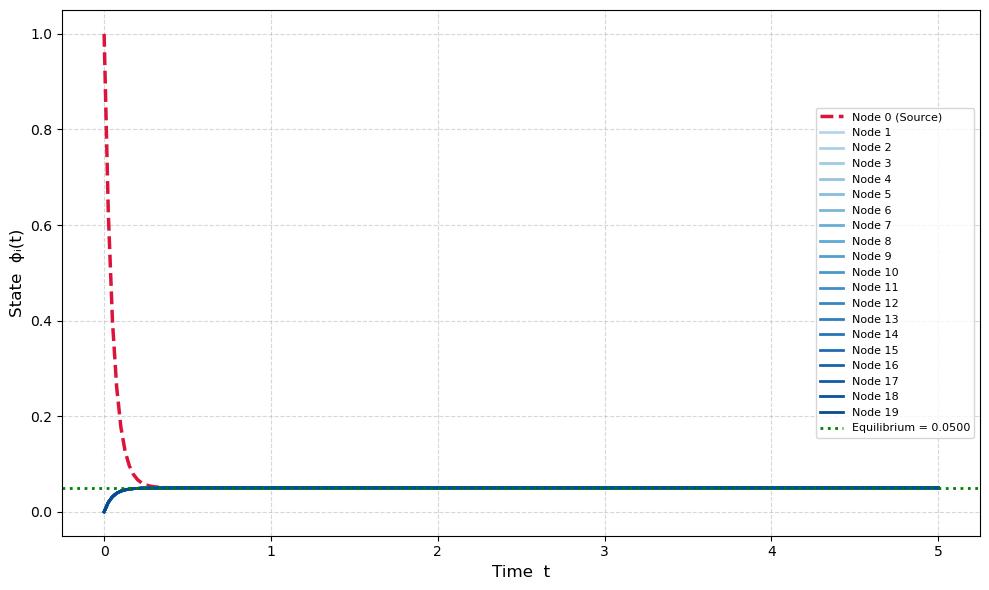

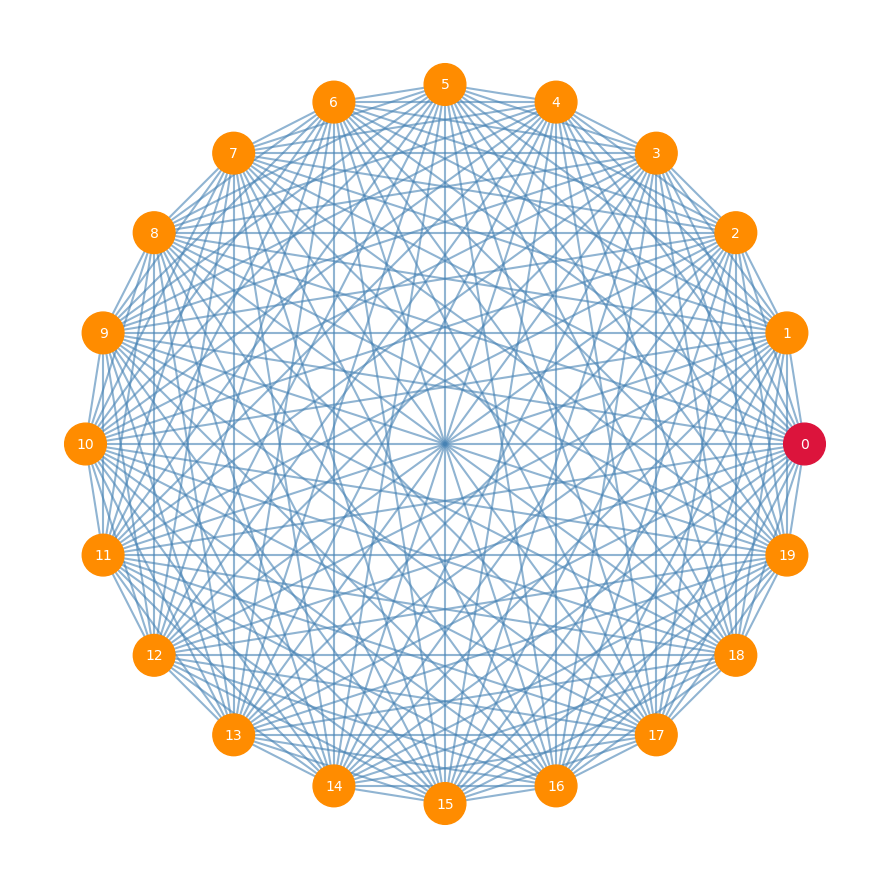


              DIFFUSION SUMMARY
Network         : Crisp Complete K20  (20 nodes)
Source node     : Node 0,  ϕ(0) = 1.0
Diffusion const : C = 1.0
Node degree     : 19  (every node connected to all others)
Equilibrium     : 0.0500  (= 1/n = 1/20)

Final states at t = 5:
  Node 0: ϕ(5) = 0.0500
  Node 1: ϕ(5) = 0.0500
  Node 2: ϕ(5) = 0.0500
  Node 3: ϕ(5) = 0.0500
  Node 4: ϕ(5) = 0.0500
  Node 5: ϕ(5) = 0.0500
  Node 6: ϕ(5) = 0.0500
  Node 7: ϕ(5) = 0.0500
  Node 8: ϕ(5) = 0.0500
  Node 9: ϕ(5) = 0.0500
  Node 10: ϕ(5) = 0.0500
  Node 11: ϕ(5) = 0.0500
  Node 12: ϕ(5) = 0.0500
  Node 13: ϕ(5) = 0.0500
  Node 14: ϕ(5) = 0.0500
  Node 15: ϕ(5) = 0.0500
  Node 16: ϕ(5) = 0.0500
  Node 17: ϕ(5) = 0.0500
  Node 18: ϕ(5) = 0.0500
  Node 19: ϕ(5) = 0.0500

Key Observation:
  All 19 non-source nodes have identical diffusion curves
  because every node has degree 19 and every edge weight = 1.
  Diffusion is very fast due to direct connections between all nodes.
  This extreme symmetry is a fun

In [19]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.linalg import expm

# ── Parameters ─────────────────────────────────────────────────────────────────
# A complete network on 10 nodes means every pair of nodes is connected.
# From Definition 2.2.1 (Category b): a complete network Kn has every pair
# of nodes adjacent to each other.
NUM_NODES  = 20
T_END      = 5
NUM_STEPS  = 200
C          = 1.0      # diffusion constant

# ── Step 1: Build the Crisp Complete Network ───────────────────────────────────
# nx.complete_graph(n) builds Kn — every node connected to every other node.
# All edges are binary (weight = 1) as per classical network definition.

G_crisp = nx.complete_graph(NUM_NODES)

# ── Step 2: Build Classical Matrices A, D, L ───────────────────────────────────
# A — binary adjacency matrix: Aij = 1 if edge exists, 0 otherwise
# D — degree matrix: diagonal matrix of node degrees
# L — classical Laplacian: L = D - A (Section 2.3.5)
# In a complete network K10, every node has degree n-1 = 9

n     = G_crisp.number_of_nodes()
nodes = list(G_crisp.nodes())
idx   = {node: i for i, node in enumerate(nodes)}

# Binary adjacency matrix
A = np.zeros((n, n))
for u, v in G_crisp.edges():
    i, j    = idx[u], idx[v]
    A[i][j] = 1
    A[j][i] = 1              # symmetric — undirected

# Degree matrix
D = np.diag(A.sum(axis=1))

# Classical Laplacian
L = D - A

print("=" * 55)
print("     CLASSICAL CRISP COMPLETE NETWORK K20")
print("=" * 55)
print("\nAdjacency Matrix A:")
print(np.round(A, 2))
print("\nDegree Matrix D:")
print(np.round(D, 2))
print("\nLaplacian Matrix L:")
print(np.round(L, 2))

# ── Step 3: Set Initial Conditions ϕ(0) ───────────────────────────────────────
# Node 0 is the single source — starts with all the substance (value = 1.0).
# All other nodes start at 0.0.
# From equation (3.2.8): ϕ(t) = e^{-CtL} ϕ(0)

phi0         = np.zeros(n)
phi0[idx[0]] = 1.0

equilibrium  = phi0.sum() / n     # Theorem 3.3.2: all nodes converge to average

print(f"\nInitial state ϕ(0)     : {phi0}")
print(f"Theoretical equilibrium : {equilibrium:.4f}  (= 1/n = 1/{n})")

# ── Step 4: Simulate Classical Diffusion ϕ(t) = e^{-CtL} ϕ(0) ────────────────
# In a complete network, diffusion is extremely fast because every node is
# directly connected to every other node — no intermediate hops needed.

time_steps = np.linspace(0, T_END, NUM_STEPS)
phi_t      = np.zeros((NUM_STEPS, n))

for k, t in enumerate(time_steps):
    phi_t[k] = expm(-C * t * L) @ phi0

# ── Step 5: Plot Diffusion Curves ──────────────────────────────────────────────
# In a complete crisp network all non-source nodes behave identically because
# every node has the same degree (n-1) and the same edge weight (1).
# All curves except node 0 will perfectly overlap — showing the symmetry
# limitation of crisp networks.

fig1, ax1 = plt.subplots(figsize=(10, 6))

# Source node curve
ax1.plot(time_steps, phi_t[:, idx[0]],
         label="Node 0 (Source)",
         color='crimson', linewidth=2.5, linestyle='--')

# All other node curves
colors = cm.Blues(np.linspace(0.3, 0.9, NUM_NODES - 1))
for i in range(1, NUM_NODES):
    ax1.plot(time_steps, phi_t[:, idx[i]],
             label=f"Node {i}",
             color=colors[i - 1], linewidth=2)

# Equilibrium line
ax1.axhline(y=equilibrium, color='green', linestyle=':', linewidth=2,
            label=f"Equilibrium = {equilibrium:.4f}")

ax1.set_xlabel("Time  t", fontsize=12)
ax1.set_ylabel("State  ϕᵢ(t)", fontsize=12)
#ax1.set_title("Diffusion on a Crisps K20 Network\n"
              #"ϕ(t) = e^{−tCL} ϕ(0)  |  Source: Node 0  |  C = 1.0",
              #fontsize=13)
ax1.legend(fontsize=8, loc='right')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("Diffusion_on_Crisps_K20.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# ── Step 6: Visualise the Complete Network ─────────────────────────────────────
# nx.circular_layout places all nodes evenly around a circle — the best
# layout for a complete network since every node has the same degree.
# Node 0 (source) is highlighted in red; all others in orange.

pos = nx.circular_layout(G_crisp)

# Colour node 0 differently to mark it as the source
node_colors = ['crimson' if nd == 0 else 'darkorange' for nd in G_crisp.nodes()]
node_labels = {nd: f"{nd}" for nd in G_crisp.nodes()}
edge_labels = {(u, v): "1" for u, v in G_crisp.edges()}

fig2, ax2 = plt.subplots(figsize=(9, 9))

nx.draw_networkx_nodes(G_crisp, pos,
                       node_color=node_colors,
                       node_size=900,
                       ax=ax2)

nx.draw_networkx_edges(G_crisp, pos,
                       edge_color='steelblue',
                       width=1.5,
                       alpha=0.6,
                       ax=ax2)

nx.draw_networkx_labels(G_crisp, pos,
                        labels=node_labels,
                        font_size=10,
                        font_color='white',
                        ax=ax2)

#ax2.set_title(f"Crisp K{NUM_NODES} Network\n"
              #,
              #fontsize=11)
ax2.axis("off")
plt.tight_layout()
plt.savefig("Crisp_K20_network.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# ── Step 7: Print Final Summary ────────────────────────────────────────────────
print(f"\n{'=' * 55}")
print(f"              DIFFUSION SUMMARY")
print(f"{'=' * 55}")
print(f"Network         : Crisp Complete K{NUM_NODES}  ({n} nodes)")
print(f"Source node     : Node 0,  ϕ(0) = 1.0")
print(f"Diffusion const : C = {C}")
print(f"Node degree     : {NUM_NODES - 1}  (every node connected to all others)")
print(f"Equilibrium     : {equilibrium:.4f}  (= 1/n = 1/{n})")
print(f"\nFinal states at t = {T_END}:")
for node in nodes:
    print(f"  Node {node}: ϕ({T_END}) = {phi_t[-1, idx[node]]:.4f}")
print(f"\nKey Observation:")
print(f"  All {NUM_NODES - 1} non-source nodes have identical diffusion curves")
print(f"  because every node has degree {NUM_NODES-1} and every edge weight = 1.")
print(f"  Diffusion is very fast due to direct connections between all nodes.")
print(f"  This extreme symmetry is a fundamental limitation of the crisp model.")

## Crisps Diffusion (Hub Node) Comparison  $K_{10}$ vs $K_{20}$

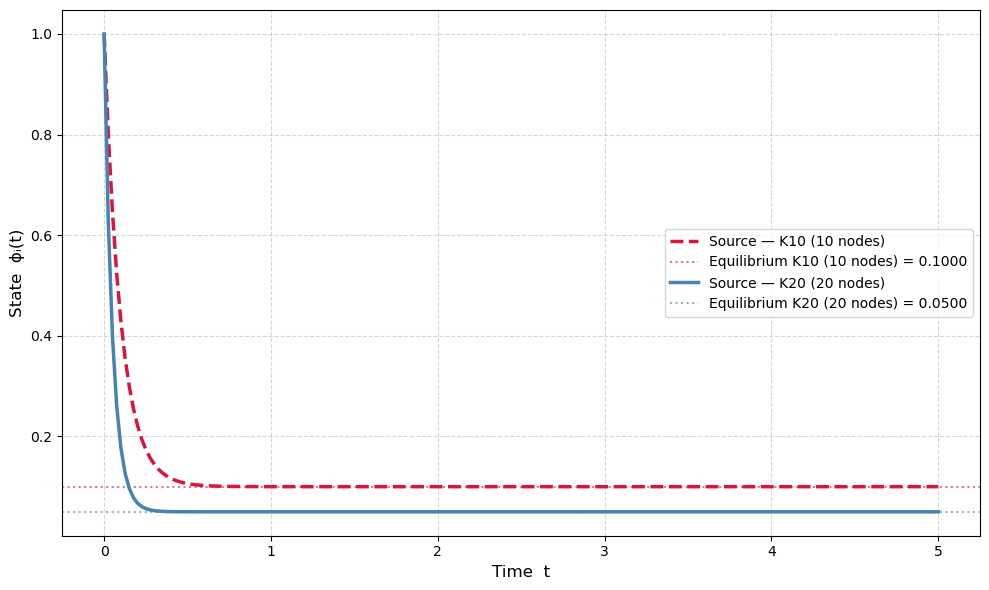

In [20]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

T_END, NUM_STEPS = 5, 200
time_steps = np.linspace(0, T_END, NUM_STEPS)
C = 1.0

configs = [
    {"NUM_NODES": 10, "color": "crimson",   "linestyle": "--", "label": "K10 (10 nodes)"},
    {"NUM_NODES": 20, "color": "steelblue", "linestyle": "-",  "label": "K20 (20 nodes)"},
]

fig, ax = plt.subplots(figsize=(10, 6))

for cfg in configs:
    NUM_NODES = cfg["NUM_NODES"]

    # Build complete graph
    G_crisp = nx.complete_graph(NUM_NODES)
    n       = G_crisp.number_of_nodes()
    idx     = {node: i for i, node in enumerate(G_crisp.nodes())}

    # Classical Laplacian
    A = np.zeros((n, n))
    for u, v in G_crisp.edges():
        A[idx[u]][idx[v]] = A[idx[v]][idx[u]] = 1
    L = np.diag(A.sum(axis=1)) - A

    # Initial conditions
    phi0         = np.zeros(n)
    phi0[idx[0]] = 1.0
    equilibrium  = phi0.sum() / n

    # Simulate
    phi_t = np.array([expm(-C * t * L) @ phi0 for t in time_steps])

    # Plot
    ax.plot(time_steps, phi_t[:, idx[0]],
            color=cfg["color"], linestyle=cfg["linestyle"], linewidth=2.5,
            label=f"Source — {cfg['label']}")

    ax.axhline(y=equilibrium, color=cfg["color"], linestyle=":", linewidth=1.5, alpha=0.6,
               label=f"Equilibrium {cfg['label']} = {equilibrium:.4f}")

ax.set_xlabel("Time  t", fontsize=12)
ax.set_ylabel("State  ϕᵢ(t)", fontsize=12)
#ax.set_title("Comparison of the Diffusion between the Hub nodes of a Crisps K10 vs K20\n"
            #, fontsize=13)
ax.legend(fontsize=10, loc='right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("Diffusion_comparison_crisps_K10_vs_K20.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

## Diffusion on a Fuzzy $K_{10}$

       FUZZY COMPLETE NETWORK K10 MATRICES

Fuzzy Adjacency Matrix Af:
[[0.   0.11 0.43 0.38 0.13 0.13 0.11 0.2  0.28 0.25]
 [0.11 0.   0.29 0.43 0.12 0.14 0.12 0.46 0.52 0.23]
 [0.43 0.29 0.   0.38 0.18 0.11 0.13 0.21 0.14 0.71]
 [0.38 0.43 0.38 0.   0.24 0.21 0.12 0.15 0.47 0.34]
 [0.13 0.12 0.18 0.24 0.   0.12 0.12 0.1  0.23 0.14]
 [0.13 0.14 0.11 0.21 0.12 0.   0.13 0.14 0.17 0.18]
 [0.11 0.12 0.13 0.12 0.12 0.13 0.   0.11 0.15 0.14]
 [0.2  0.46 0.21 0.15 0.1  0.14 0.11 0.   0.61 0.67]
 [0.28 0.52 0.14 0.47 0.23 0.17 0.15 0.61 0.   0.42]
 [0.25 0.23 0.71 0.34 0.14 0.18 0.14 0.67 0.42 0.  ]]

Fuzzy Degree Matrix Df:
[[2.02 0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   2.42 0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   2.58 0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   2.72 0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   1.38 0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   1.33 0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   1.13 0.   0.   0.  ]
 [

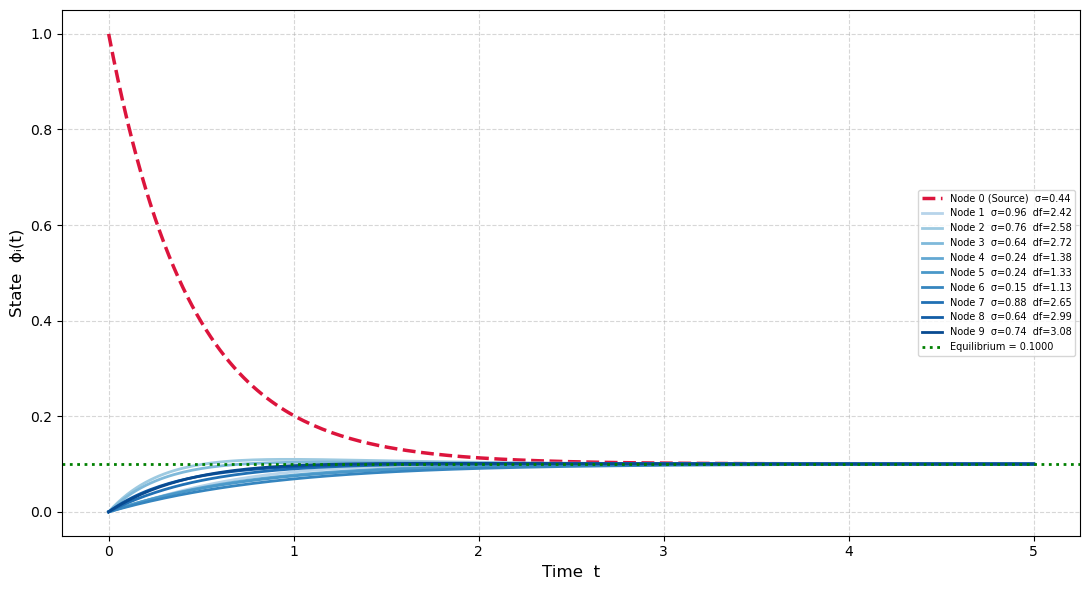

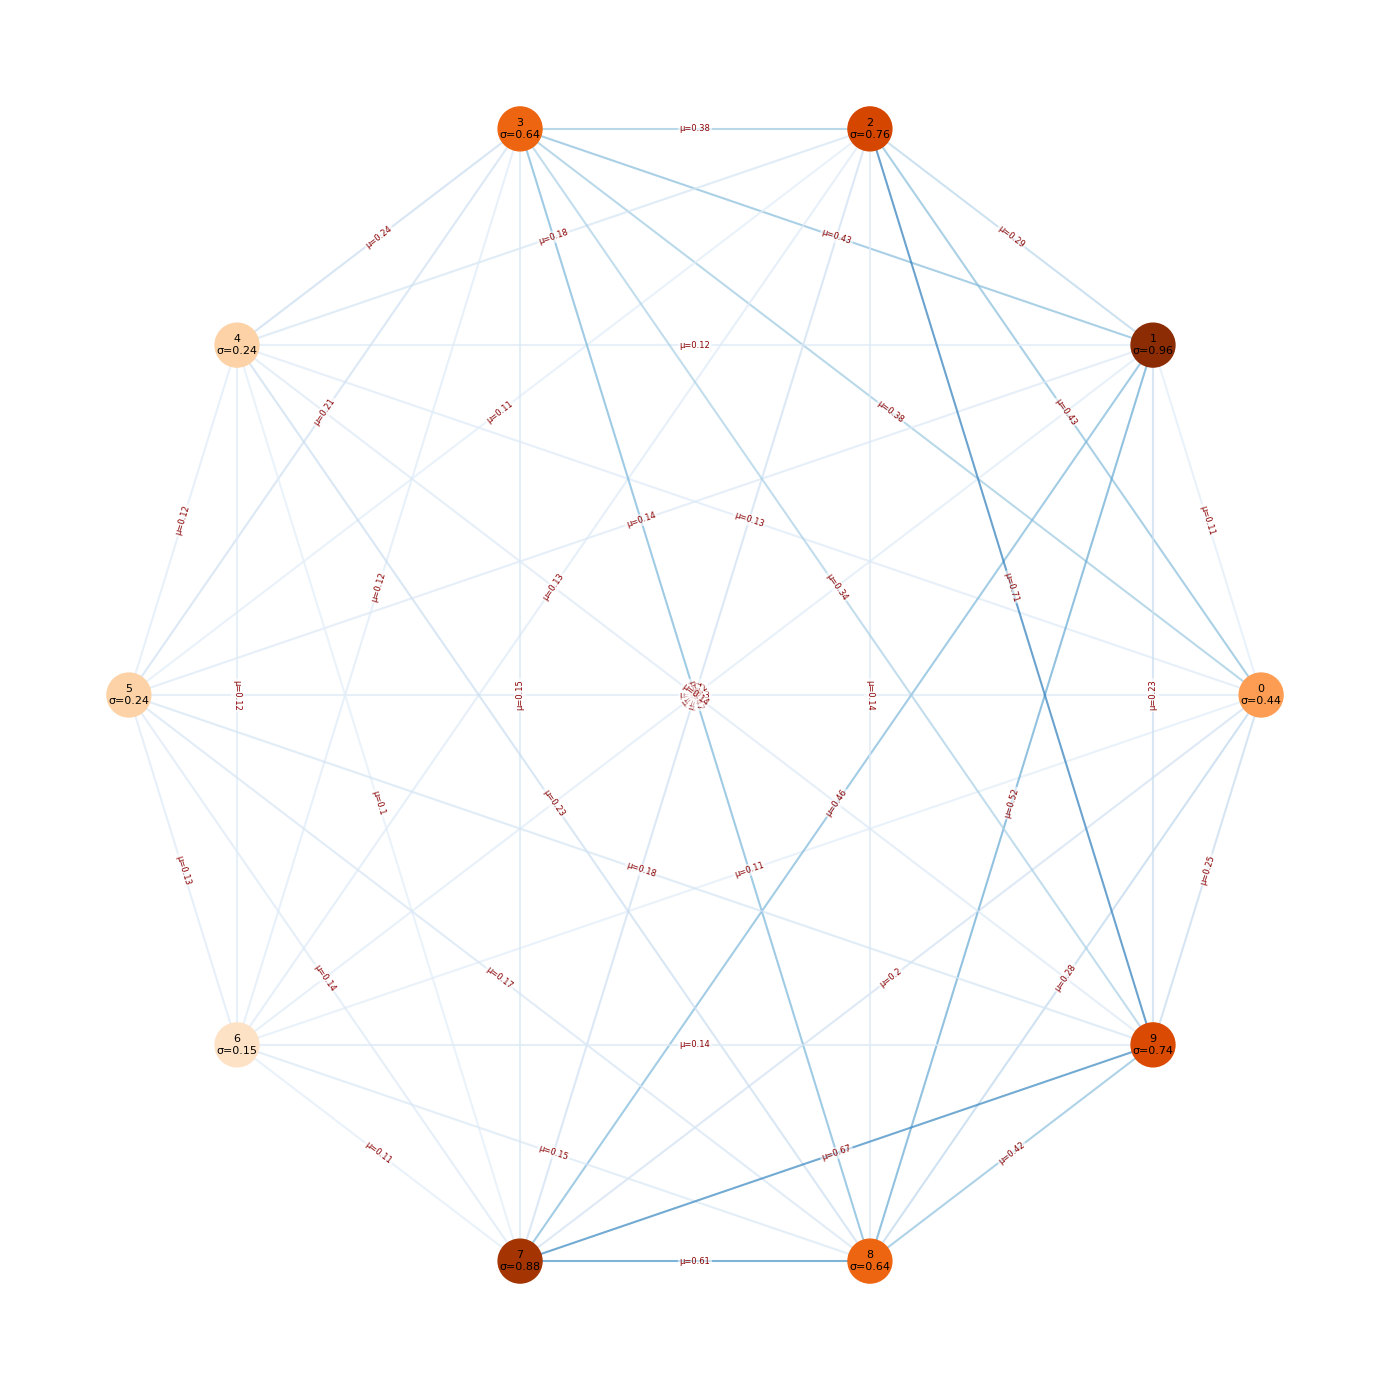


              DIFFUSION SUMMARY
Network         : Fuzzy Complete K10  (10 nodes)
Source node     : Node 0,  ϕ(0) = 1.0
Equilibrium     : 0.1000  (= 1/n = 1/10)
Total edges     : 45  (= n(n-1)/2 = 45)

Final states at t = 5:
  Node 0: ϕ(5) = 0.1001
  Node 1: ϕ(5) = 0.1000
  Node 2: ϕ(5) = 0.1000
  Node 3: ϕ(5) = 0.1000
  Node 4: ϕ(5) = 0.1000
  Node 5: ϕ(5) = 0.0999
  Node 6: ϕ(5) = 0.0998
  Node 7: ϕ(5) = 0.1000
  Node 8: ϕ(5) = 0.1000
  Node 9: ϕ(5) = 0.1000

Fuzzy degree df(i) of each node:
  Node 0: df = 2.02  —  slower than average convergence
  Node 1: df = 2.42  —  faster than average convergence
  Node 2: df = 2.58  —  faster than average convergence
  Node 3: df = 2.72  —  faster than average convergence
  Node 4: df = 1.38  —  slower than average convergence
  Node 5: df = 1.33  —  slower than average convergence
  Node 6: df = 1.13  —  slower than average convergence
  Node 7: df = 2.65  —  faster than average convergence
  Node 8: df = 2.99  —  faster than average convergen

In [21]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.linalg import expm

# ── Parameters ────────────────────────────────────────────────────────────────
# A complete fuzzy network K10 has every pair of nodes connected,
# each with a fuzzy edge membership µ(u,v) ≤ min(σ(u), σ(v))
# From Definition 2.5.1: G = (V, σ, µ) is complete if µ(x,y) = σ(x) ∧ σ(y)
# Here we draw µ randomly below that upper bound for a more realistic network.
NUM_NODES  = 10
T_END      = 5
NUM_STEPS  = 200

# ── Step 1: Build the Complete Fuzzy Network K10 ──────────────────────────────
G = nx.Graph()

# Add all nodes with random fuzzy membership values σ(v) ∈ (0.1, 1]
# σ(v) represents how strongly node v belongs to the network
np.random.seed(42)
for node in range(NUM_NODES):
    sigma = round(np.random.uniform(0.1, 1.0), 2)
    G.add_node(node, sigma=sigma)

# Add edges between every pair of nodes — this makes it a complete graph
# For each edge, µ(u,v) is drawn randomly but must satisfy:
# µ(u,v) ≤ min(σ(u), σ(v))  — from Definition 2.5.1 (Rosenfeld, 1975)
for u in range(NUM_NODES):
    for v in range(u + 1, NUM_NODES):
        sigma_u   = G.nodes[u]['sigma']
        sigma_v   = G.nodes[v]['sigma']
        max_mu    = min(sigma_u, sigma_v)
        mu        = round(np.random.uniform(0.1, max_mu), 2)
        G.add_edge(u, v, mu=mu)

# ── Step 2: Build the Fuzzy Laplacian Matrix Lf = Df - Af ────────────────────
# From Section 2.6.3: Lf = Df - Af
# Af — fuzzy adjacency matrix: Af[i][j] = µ(i,j)
# Df — fuzzy degree matrix: diagonal, Df[i][i] = sum of µ over all edges of i
# From Section 3.3.1: fuzzy diffusion equation is dϕ/dt = -Lf ϕ

n     = G.number_of_nodes()
nodes = list(G.nodes())
idx   = {node: i for i, node in enumerate(nodes)}

# Fuzzy adjacency matrix Af
Af = np.zeros((n, n))
for u, v, data in G.edges(data=True):
    i, j     = idx[u], idx[v]
    Af[i][j] = data['mu']
    Af[j][i] = data['mu']        # symmetric — undirected network

# Fuzzy degree matrix Df
Df = np.diag(Af.sum(axis=1))

# Fuzzy Laplacian
Lf = Df - Af

print("=" * 55)
print("       FUZZY COMPLETE NETWORK K10 MATRICES")
print("=" * 55)
print("\nFuzzy Adjacency Matrix Af:")
print(np.round(Af, 2))
print("\nFuzzy Degree Matrix Df:")
print(np.round(Df, 2))
print("\nFuzzy Laplacian Matrix Lf:")
print(np.round(Lf, 2))

# ── Step 3: Set Initial Conditions ϕ(0) ──────────────────────────────────────
# Node 0 is the single source — starts with all the substance (value = 1.0).
# All other nodes start at 0.0.
# From equation (3.3.6): ϕ(t) = e^{-tLf} ϕ(0)

phi0         = np.zeros(n)
phi0[idx[0]] = 1.0

equilibrium  = phi0.sum() / n    # Theorem 3.3.2: all nodes converge to 1/n

print(f"\nInitial state ϕ(0)     : {phi0}")
print(f"Theoretical equilibrium : {equilibrium:.4f}  (= 1/n = 1/{n})")
print(f"\nNode memberships σ:")
for nd in G.nodes():
    print(f"  Node {nd}: σ = {G.nodes[nd]['sigma']}")

# ── Step 4: Simulate Fuzzy Diffusion ϕ(t) = e^{-t*Lf} ϕ(0) ──────────────────
# From equation (3.3.6): solution to dϕ/dt = -Lf ϕ is ϕ(t) = e^{-tLf} ϕ(0)
# Unlike the crisp model, each node converges at a different rate because
# each edge carries a unique fuzzy weight µ(u,v) ∈ (0.1, 1].

time_steps = np.linspace(0, T_END, NUM_STEPS)
phi_t      = np.zeros((NUM_STEPS, n))

for k, t in enumerate(time_steps):
    phi_t[k] = expm(-t * Lf) @ phi0

# ── Step 5: Plot Diffusion Curves ─────────────────────────────────────────────
# In the fuzzy complete network, unlike the crisp version, every non-source
# node has a unique diffusion curve because each node has a different total
# fuzzy degree df(i) = sum of µ values over all its edges.
# Nodes with higher total fuzzy degree receive substance faster.

fig1, ax1 = plt.subplots(figsize=(11, 6))

# Source node curve
ax1.plot(time_steps, phi_t[:, idx[0]],
         label=f"Node 0 (Source)  σ={G.nodes[0]['sigma']}",
         color='crimson', linewidth=2.5, linestyle='--')

# All other node curves — coloured by their σ value
colors = cm.Blues(np.linspace(0.3, 0.9, NUM_NODES - 1))
for i in range(1, NUM_NODES):
    # compute total fuzzy degree of node i for the label
    df_i = round(sum(G[i][j]['mu'] for j in G.neighbors(i)), 3)
    ax1.plot(time_steps, phi_t[:, idx[i]],
             label=f"Node {i}  σ={G.nodes[i]['sigma']}  df={df_i}",
             color=colors[i - 1], linewidth=2)

# Equilibrium line
ax1.axhline(y=equilibrium, color='green', linestyle=':', linewidth=2,
            label=f"Equilibrium = {equilibrium:.4f}")

ax1.set_xlabel("Time  t", fontsize=12)
ax1.set_ylabel("State  ϕᵢ(t)", fontsize=12)
#ax1.set_title("Diffusion on a Fuzzy K10 Network\n"
             # "ϕ(t) = e^{−tLf} ϕ(0)  |  Source: Node 0", fontsize=11)
ax1.legend(fontsize=7, loc='right')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("Diffusion_on_a_fuzzy_K10.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# ── Step 6: Visualise the Complete Fuzzy Network ──────────────────────────────
# nx.circular_layout is the best choice for complete networks —
# all nodes are placed evenly around a circle.
# Node colours reflect σ (Oranges colourmap: darker = higher membership)
# Edge colours reflect µ (Blues colourmap: darker = stronger fuzzy tie)
# Edge labels show the fuzzy edge degree: dG(u,v) = dG(u) + dG(v) - 2µ(u,v)
# From Definition 2.5.5 (Al Mutab, 2019)

# Edge labels show fuzzy membership µ(u,v) for each edge
edge_labels = {
    (u, v): f"µ={G[u][v]['mu']}"
    for u, v in G.edges()
}

pos          = nx.circular_layout(G)
active_edges = [(u, v) for u, v in G.edges()]
edge_mus     = [G[u][v]['mu'] for u, v in active_edges]
edge_colors  = [cm.Blues(mu) for mu in edge_mus]
node_sigmas  = [G.nodes[nd]['sigma'] for nd in G.nodes()]
node_labels  = {nd: f"{nd}\nσ={G.nodes[nd]['sigma']}" for nd in G.nodes()}

fig2, ax2 = plt.subplots(figsize=(14, 14))

nx.draw_networkx_nodes(G, pos,
                       node_color=node_sigmas,
                       cmap=plt.cm.Oranges,
                       node_size=1000,
                       vmin=0, vmax=1,
                       ax=ax2)

nx.draw_networkx_edges(G, pos,
                       edgelist=active_edges,
                       edge_color=edge_colors,
                       width=1.5,
                       alpha=0.7,
                       ax=ax2)

nx.draw_networkx_labels(G, pos,
                        labels=node_labels,
                        font_size=8,
                        ax=ax2)

nx.draw_networkx_edge_labels(G, pos,
                             edge_labels=edge_labels,
                             font_size=6,
                             font_color='darkred',
                             bbox=dict(boxstyle='round,pad=0.2',
                                       fc='white', alpha=0.6, ec='none'),
                             ax=ax2)

#ax2.set_title(f"Fuzzy K{NUM_NODES} Network\n"
             #,
             # fontsize=11)
ax2.axis("off")
plt.tight_layout()
plt.savefig("fuzzy_K10_network.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()



# ── Step 7: Print Final Summary ───────────────────────────────────────────────
print(f"\n{'=' * 55}")
print(f"              DIFFUSION SUMMARY")
print(f"{'=' * 55}")
print(f"Network         : Fuzzy Complete K{NUM_NODES}  ({n} nodes)")
print(f"Source node     : Node 0,  ϕ(0) = 1.0")
print(f"Equilibrium     : {equilibrium:.4f}  (= 1/n = 1/{n})")
print(f"Total edges     : {G.number_of_edges()}  (= n(n-1)/2 = {n*(n-1)//2})")
print(f"\nFinal states at t = {T_END}:")
for node in nodes:
    print(f"  Node {node}: ϕ({T_END}) = {phi_t[-1, idx[node]]:.4f}")
print(f"\nFuzzy degree df(i) of each node:")
for nd in G.nodes():
    df = round(sum(G[nd][nb]['mu'] for nb in G.neighbors(nd)), 3)
    print(f"  Node {nd}: df = {df}  —  "
          f"{'faster' if df > Af.sum(axis=1).mean() else 'slower'} "
          f"than average convergence")

## Diffusion on a Fuzzy $K_{20}$

       FUZZY COMPLETE NETWORK K20 MATRICES

Fuzzy Adjacency Matrix Af:
[[0.   0.31 0.15 0.2  0.15 0.16 0.14 0.17 0.27 0.3  0.1  0.31 0.16 0.11
  0.25 0.26 0.32 0.2  0.13 0.28]
 [0.31 0.   0.39 0.17 0.17 0.1  0.15 0.3  0.46 0.3  0.11 0.57 0.24 0.28
  0.22 0.26 0.34 0.38 0.46 0.12]
 [0.15 0.39 0.   0.21 0.11 0.15 0.12 0.28 0.55 0.33 0.11 0.46 0.19 0.25
  0.11 0.27 0.31 0.19 0.1  0.31]
 [0.2  0.17 0.21 0.   0.2  0.2  0.14 0.14 0.29 0.16 0.12 0.44 0.28 0.11
  0.15 0.16 0.3  0.4  0.45 0.22]
 [0.15 0.17 0.11 0.2  0.   0.12 0.14 0.21 0.18 0.21 0.11 0.17 0.16 0.1
  0.12 0.1  0.19 0.14 0.17 0.23]
 [0.16 0.1  0.15 0.2  0.12 0.   0.11 0.16 0.21 0.13 0.1  0.14 0.12 0.23
  0.21 0.19 0.22 0.21 0.13 0.22]
 [0.14 0.15 0.12 0.14 0.14 0.11 0.   0.13 0.14 0.14 0.11 0.11 0.11 0.12
  0.14 0.14 0.1  0.13 0.12 0.11]
 [0.17 0.3  0.28 0.14 0.21 0.16 0.13 0.   0.16 0.32 0.12 0.35 0.49 0.23
  0.16 0.27 0.36 0.22 0.29 0.18]
 [0.27 0.46 0.55 0.29 0.18 0.21 0.14 0.16 0.   0.25 0.1  0.43 0.37 0.11
  0.14 0.25 0.16 0

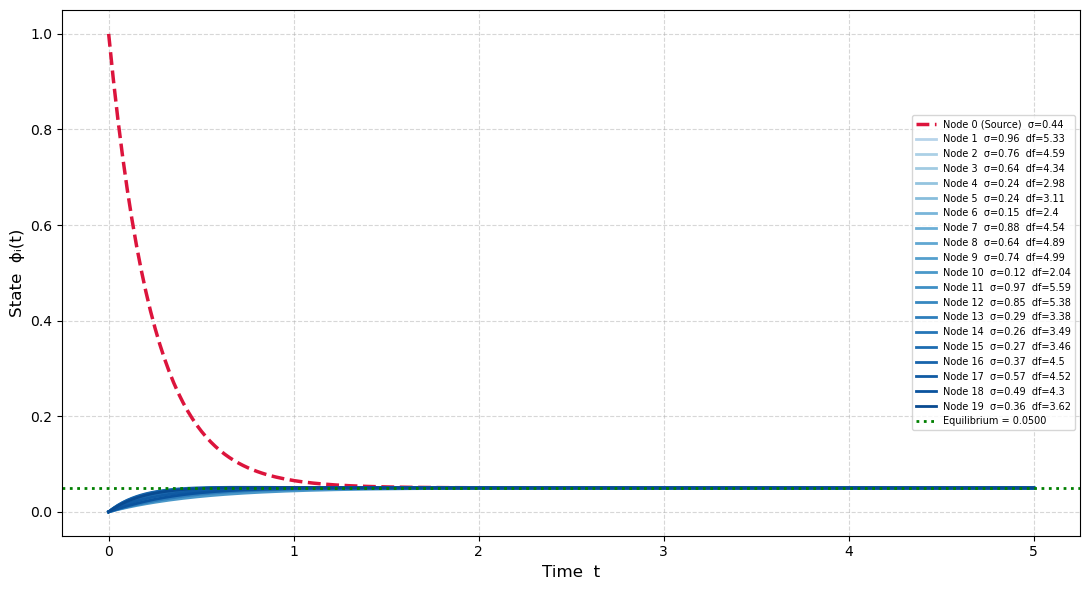

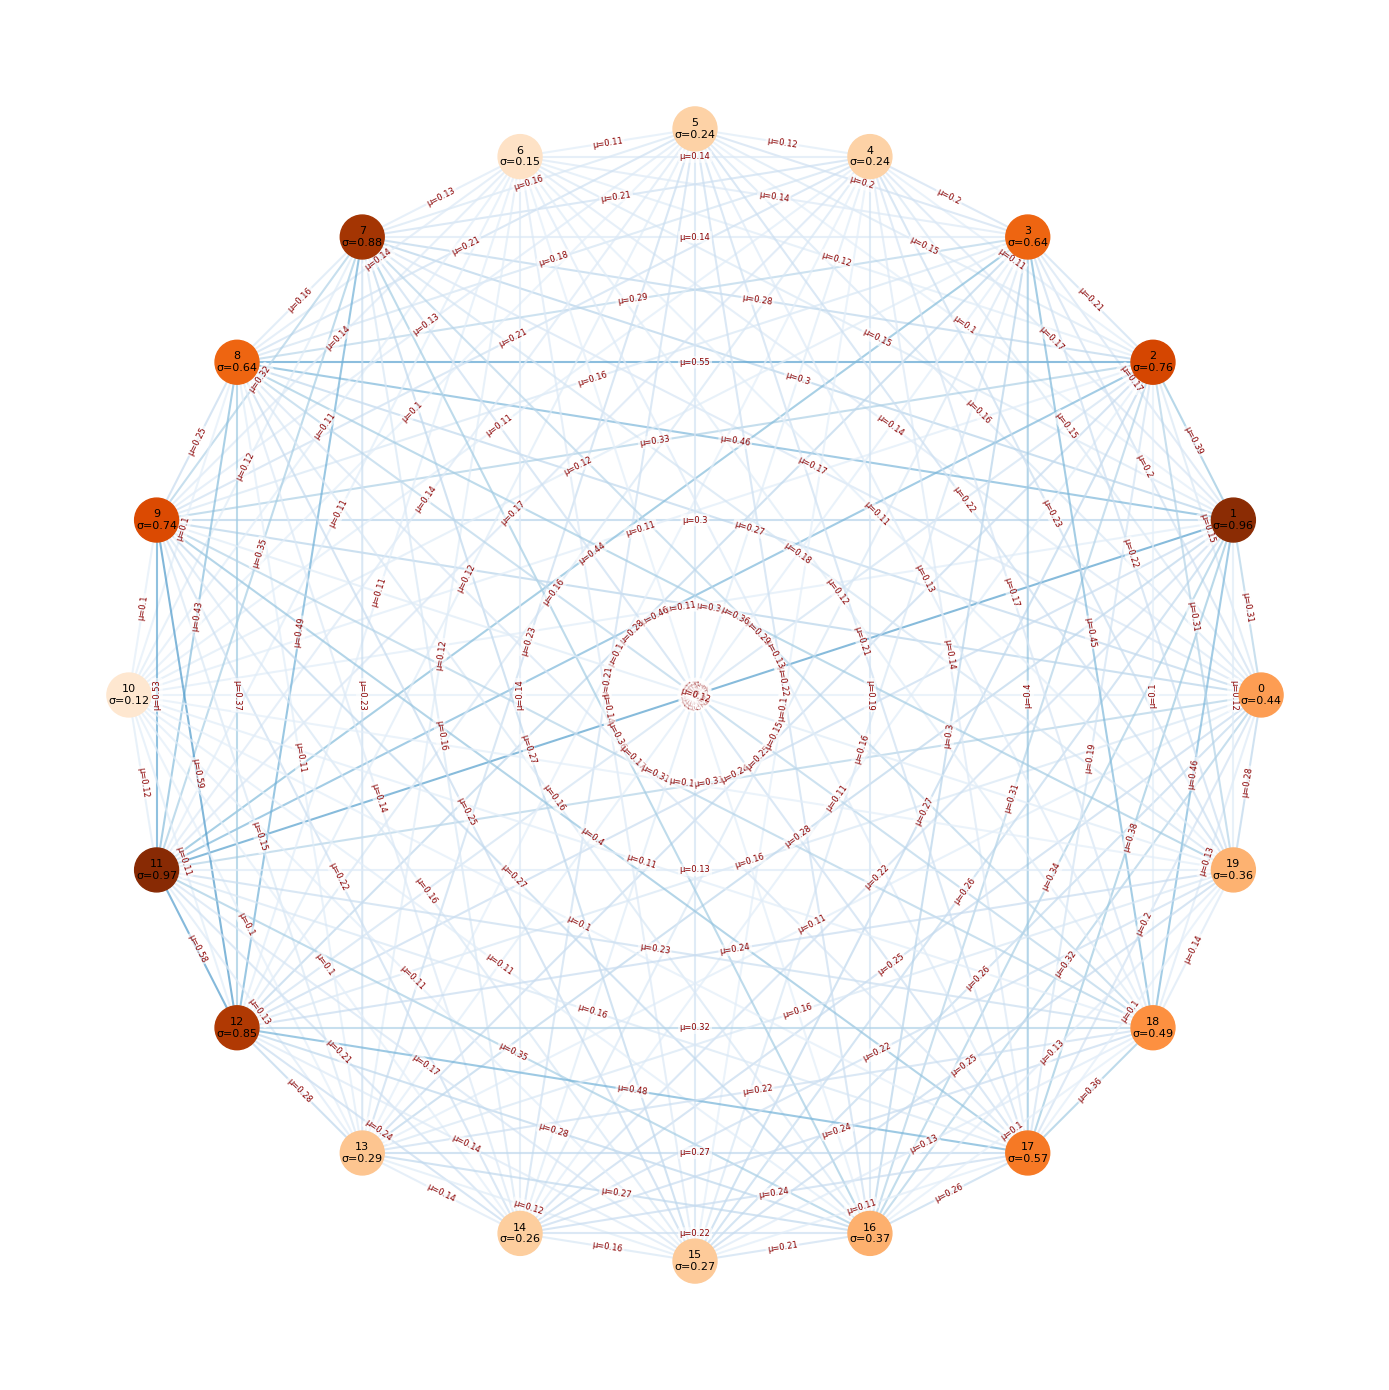


              DIFFUSION SUMMARY
Network         : Fuzzy Complete K20  (20 nodes)
Source node     : Node 0,  ϕ(0) = 1.0
Equilibrium     : 0.0500  (= 1/n = 1/20)
Total edges     : 190  (= n(n-1)/2 = 190)

Final states at t = 5:
  Node 0: ϕ(5) = 0.0500
  Node 1: ϕ(5) = 0.0500
  Node 2: ϕ(5) = 0.0500
  Node 3: ϕ(5) = 0.0500
  Node 4: ϕ(5) = 0.0500
  Node 5: ϕ(5) = 0.0500
  Node 6: ϕ(5) = 0.0500
  Node 7: ϕ(5) = 0.0500
  Node 8: ϕ(5) = 0.0500
  Node 9: ϕ(5) = 0.0500
  Node 10: ϕ(5) = 0.0500
  Node 11: ϕ(5) = 0.0500
  Node 12: ϕ(5) = 0.0500
  Node 13: ϕ(5) = 0.0500
  Node 14: ϕ(5) = 0.0500
  Node 15: ϕ(5) = 0.0500
  Node 16: ϕ(5) = 0.0500
  Node 17: ϕ(5) = 0.0500
  Node 18: ϕ(5) = 0.0500
  Node 19: ϕ(5) = 0.0500

Fuzzy degree df(i) of each node:
  Node 0: df = 3.97  —  slower than average convergence
  Node 1: df = 5.33  —  faster than average convergence
  Node 2: df = 4.59  —  faster than average convergence
  Node 3: df = 4.34  —  faster than average convergence
  Node 4: df = 2.98  —  s

In [22]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.linalg import expm

# ── Parameters ────────────────────────────────────────────────────────────────
# A complete fuzzy network K10 has every pair of nodes connected,
# each with a fuzzy edge membership µ(u,v) ≤ min(σ(u), σ(v))
# From Definition 2.5.1: G = (V, σ, µ) is complete if µ(x,y) = σ(x) ∧ σ(y)
# Here we draw µ randomly below that upper bound for a more realistic network.
NUM_NODES  = 20
T_END      = 5
NUM_STEPS  = 200

# ── Step 1: Build the Complete Fuzzy Network K10 ──────────────────────────────
G = nx.Graph()

# Add all nodes with random fuzzy membership values σ(v) ∈ (0.1, 1]
# σ(v) represents how strongly node v belongs to the network
np.random.seed(42)
for node in range(NUM_NODES):
    sigma = round(np.random.uniform(0.1, 1.0), 2)
    G.add_node(node, sigma=sigma)

# Add edges between every pair of nodes — this makes it a complete graph
# For each edge, µ(u,v) is drawn randomly but must satisfy:
# µ(u,v) ≤ min(σ(u), σ(v))  — from Definition 2.5.1 (Rosenfeld, 1975)
for u in range(NUM_NODES):
    for v in range(u + 1, NUM_NODES):
        sigma_u   = G.nodes[u]['sigma']
        sigma_v   = G.nodes[v]['sigma']
        max_mu    = min(sigma_u, sigma_v)
        mu        = round(np.random.uniform(0.1, max_mu), 2)
        G.add_edge(u, v, mu=mu)

# ── Step 2: Build the Fuzzy Laplacian Matrix Lf = Df - Af ────────────────────
# From Section 2.6.3: Lf = Df - Af
# Af — fuzzy adjacency matrix: Af[i][j] = µ(i,j)
# Df — fuzzy degree matrix: diagonal, Df[i][i] = sum of µ over all edges of i
# From Section 3.3.1: fuzzy diffusion equation is dϕ/dt = -Lf ϕ

n     = G.number_of_nodes()
nodes = list(G.nodes())
idx   = {node: i for i, node in enumerate(nodes)}

# Fuzzy adjacency matrix Af
Af = np.zeros((n, n))
for u, v, data in G.edges(data=True):
    i, j     = idx[u], idx[v]
    Af[i][j] = data['mu']
    Af[j][i] = data['mu']        # symmetric — undirected network

# Fuzzy degree matrix Df
Df = np.diag(Af.sum(axis=1))

# Fuzzy Laplacian
Lf = Df - Af

print("=" * 55)
print("       FUZZY COMPLETE NETWORK K20 MATRICES")
print("=" * 55)
print("\nFuzzy Adjacency Matrix Af:")
print(np.round(Af, 2))
print("\nFuzzy Degree Matrix Df:")
print(np.round(Df, 2))
print("\nFuzzy Laplacian Matrix Lf:")
print(np.round(Lf, 2))

# ── Step 3: Set Initial Conditions ϕ(0) ──────────────────────────────────────
# Node 0 is the single source — starts with all the substance (value = 1.0).
# All other nodes start at 0.0.
# From equation (3.3.6): ϕ(t) = e^{-tLf} ϕ(0)

phi0         = np.zeros(n)
phi0[idx[0]] = 1.0

equilibrium  = phi0.sum() / n    # Theorem 3.3.2: all nodes converge to 1/n

print(f"\nInitial state ϕ(0)     : {phi0}")
print(f"Theoretical equilibrium : {equilibrium:.4f}  (= 1/n = 1/{n})")
print(f"\nNode memberships σ:")
for nd in G.nodes():
    print(f"  Node {nd}: σ = {G.nodes[nd]['sigma']}")

# ── Step 4: Simulate Fuzzy Diffusion ϕ(t) = e^{-t*Lf} ϕ(0) ──────────────────
# From equation (3.3.6): solution to dϕ/dt = -Lf ϕ is ϕ(t) = e^{-tLf} ϕ(0)
# Unlike the crisp model, each node converges at a different rate because
# each edge carries a unique fuzzy weight µ(u,v) ∈ (0.1, 1].

time_steps = np.linspace(0, T_END, NUM_STEPS)
phi_t      = np.zeros((NUM_STEPS, n))

for k, t in enumerate(time_steps):
    phi_t[k] = expm(-t * Lf) @ phi0

# ── Step 5: Plot Diffusion Curves ─────────────────────────────────────────────
# In the fuzzy complete network, unlike the crisp version, every non-source
# node has a unique diffusion curve because each node has a different total
# fuzzy degree df(i) = sum of µ values over all its edges.
# Nodes with higher total fuzzy degree receive substance faster.

fig1, ax1 = plt.subplots(figsize=(11, 6))

# Source node curve
ax1.plot(time_steps, phi_t[:, idx[0]],
         label=f"Node 0 (Source)  σ={G.nodes[0]['sigma']}",
         color='crimson', linewidth=2.5, linestyle='--')

# All other node curves — coloured by their σ value
colors = cm.Blues(np.linspace(0.3, 0.9, NUM_NODES - 1))
for i in range(1, NUM_NODES):
    # compute total fuzzy degree of node i for the label
    df_i = round(sum(G[i][j]['mu'] for j in G.neighbors(i)), 3)
    ax1.plot(time_steps, phi_t[:, idx[i]],
             label=f"Node {i}  σ={G.nodes[i]['sigma']}  df={df_i}",
             color=colors[i - 1], linewidth=2)

# Equilibrium line
ax1.axhline(y=equilibrium, color='green', linestyle=':', linewidth=2,
            label=f"Equilibrium = {equilibrium:.4f}")

ax1.set_xlabel("Time  t", fontsize=12)
ax1.set_ylabel("State  ϕᵢ(t)", fontsize=12)
#ax1.set_title("Diffusion on a Fuzzy K20 Network\n"
              #"ϕ(t) = e^{−tLf} ϕ(0)  |  Source: Node 0", fontsize=11)
ax1.legend(fontsize=7, loc='right')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("Diffusion_on_fuzzy_K20.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# ── Step 6: Visualise the Complete Fuzzy Network ──────────────────────────────
# nx.circular_layout is the best choice for complete networks —
# all nodes are placed evenly around a circle.
# Node colours reflect σ (Oranges colourmap: darker = higher membership)
# Edge colours reflect µ (Blues colourmap: darker = stronger fuzzy tie)
# Edge labels show the fuzzy edge degree: dG(u,v) = dG(u) + dG(v) - 2µ(u,v)
# From Definition 2.5.5 (Al Mutab, 2019)

# Edge labels show fuzzy membership µ(u,v) for each edge
edge_labels = {
    (u, v): f"µ={G[u][v]['mu']}"
    for u, v in G.edges()
}

pos          = nx.circular_layout(G)
active_edges = [(u, v) for u, v in G.edges()]
edge_mus     = [G[u][v]['mu'] for u, v in active_edges]
edge_colors  = [cm.Blues(mu) for mu in edge_mus]
node_sigmas  = [G.nodes[nd]['sigma'] for nd in G.nodes()]
node_labels  = {nd: f"{nd}\nσ={G.nodes[nd]['sigma']}" for nd in G.nodes()}

fig2, ax2 = plt.subplots(figsize=(14, 14))

nx.draw_networkx_nodes(G, pos,
                       node_color=node_sigmas,
                       cmap=plt.cm.Oranges,
                       node_size=1000,
                       vmin=0, vmax=1,
                       ax=ax2)

nx.draw_networkx_edges(G, pos,
                       edgelist=active_edges,
                       edge_color=edge_colors,
                       width=1.5,
                       alpha=0.7,
                       ax=ax2)

nx.draw_networkx_labels(G, pos,
                        labels=node_labels,
                        font_size=8,
                        ax=ax2)

nx.draw_networkx_edge_labels(G, pos,
                             edge_labels=edge_labels,
                             font_size=6,
                             font_color='darkred',
                             bbox=dict(boxstyle='round,pad=0.2',
                                       fc='white', alpha=0.6, ec='none'),
                             ax=ax2)

#ax2.set_title(f"Fuzzy K{NUM_NODES} Network\n"
            # ,
             # fontsize=11)
ax2.axis("off")
plt.tight_layout()
plt.savefig("fuzzy_K20_network.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# ── Step 7: Print Final Summary ───────────────────────────────────────────────
print(f"\n{'=' * 55}")
print(f"              DIFFUSION SUMMARY")
print(f"{'=' * 55}")
print(f"Network         : Fuzzy Complete K{NUM_NODES}  ({n} nodes)")
print(f"Source node     : Node 0,  ϕ(0) = 1.0")
print(f"Equilibrium     : {equilibrium:.4f}  (= 1/n = 1/{n})")
print(f"Total edges     : {G.number_of_edges()}  (= n(n-1)/2 = {n*(n-1)//2})")
print(f"\nFinal states at t = {T_END}:")
for node in nodes:
    print(f"  Node {node}: ϕ({T_END}) = {phi_t[-1, idx[node]]:.4f}")
print(f"\nFuzzy degree df(i) of each node:")
for nd in G.nodes():
    df = round(sum(G[nd][nb]['mu'] for nb in G.neighbors(nd)), 3)
    print(f"  Node {nd}: df = {df}  —  "
          f"{'faster' if df > Af.sum(axis=1).mean() else 'slower'} "
          f"than average convergence")

## Fuzzy Diffusion (Hub Node) Comparison  $K_{10}$ vs $K_{20}$

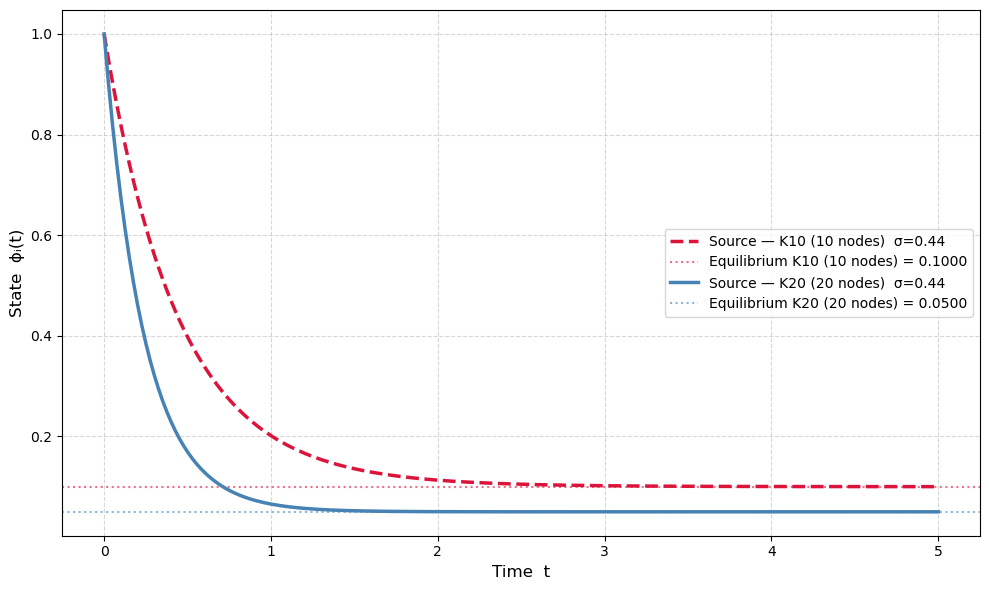

In [23]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

T_END, NUM_STEPS = 5, 200
time_steps = np.linspace(0, T_END, NUM_STEPS)

configs = [
    {"NUM_NODES": 10, "color": "crimson",   "linestyle": "--", "label": "K10 (10 nodes)"},
    {"NUM_NODES": 20, "color": "steelblue", "linestyle": "-",  "label": "K20 (20 nodes)"},
]

fig, ax = plt.subplots(figsize=(10, 6))

for cfg in configs:
    NUM_NODES = cfg["NUM_NODES"]

    # Build fuzzy complete graph
    G = nx.Graph()
    np.random.seed(42)
    for node in range(NUM_NODES):
        G.add_node(node, sigma=round(np.random.uniform(0.1, 1.0), 2))
    for u in range(NUM_NODES):
        for v in range(u + 1, NUM_NODES):
            max_mu = min(G.nodes[u]['sigma'], G.nodes[v]['sigma'])
            G.add_edge(u, v, mu=round(np.random.uniform(0.1, max_mu), 2))

    # Fuzzy Laplacian
    n   = G.number_of_nodes()
    idx = {node: i for i, node in enumerate(G.nodes())}
    Af  = np.zeros((n, n))
    for u, v, data in G.edges(data=True):
        Af[idx[u]][idx[v]] = Af[idx[v]][idx[u]] = data['mu']
    Lf = np.diag(Af.sum(axis=1)) - Af

    # Initial conditions
    phi0         = np.zeros(n)
    phi0[idx[0]] = 1.0
    equilibrium  = phi0.sum() / n

    # Simulate
    phi_t = np.array([expm(-t * Lf) @ phi0 for t in time_steps])

    # Plot
    ax.plot(time_steps, phi_t[:, idx[0]],
            color=cfg["color"], linestyle=cfg["linestyle"], linewidth=2.5,
            label=f"Source — {cfg['label']}  σ={G.nodes[0]['sigma']}")

    ax.axhline(y=equilibrium, color=cfg["color"], linestyle=":", linewidth=1.5, alpha=0.6,
               label=f"Equilibrium {cfg['label']} = {equilibrium:.4f}")

ax.set_xlabel("Time  t", fontsize=12)
ax.set_ylabel("State  ϕᵢ(t)", fontsize=12)
#ax.set_title("Comparison of the diffusion between the Hub node of a fuzzy K10 vs K20\n"
             #, fontsize=11)
ax.legend(fontsize=10, loc='right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("fuzzy_diffusion_K10_vs_K20.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

## Diffusion on crisps and fuzzy $K_{10}$ network in one plot

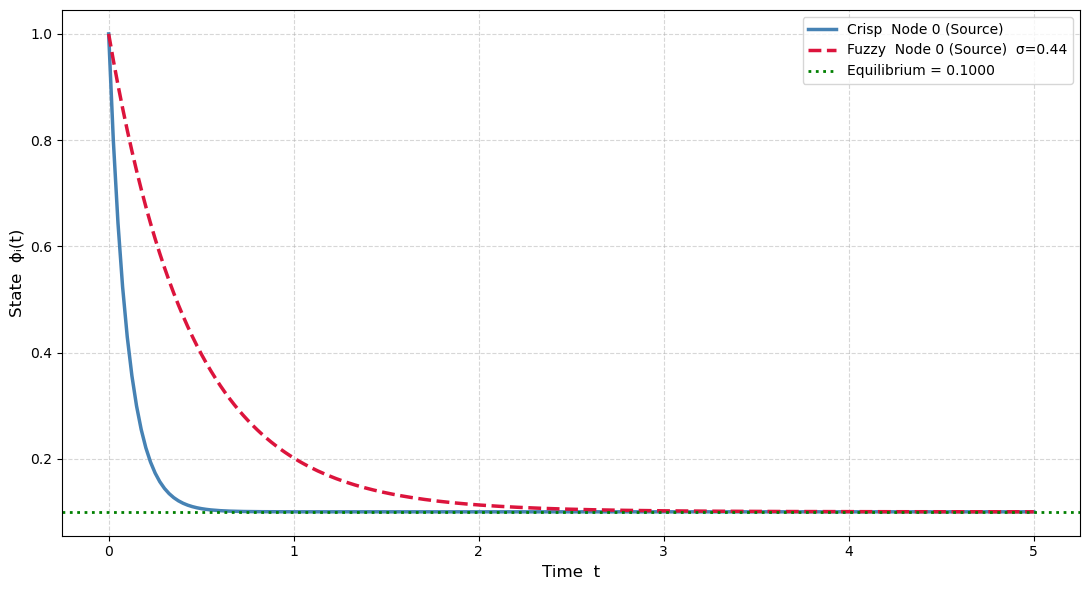

In [24]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

# ── Parameters ─────────────────────────────────────────────────────────────────
NUM_NODES  = 10
T_END      = 5
NUM_STEPS  = 200
C          = 1.0
time_steps = np.linspace(0, T_END, NUM_STEPS)

# ══════════════════════════════════════════════════════════════════════════════
# CRISP COMPLETE NETWORK
# ══════════════════════════════════════════════════════════════════════════════
G_crisp = nx.complete_graph(NUM_NODES)

n_c   = G_crisp.number_of_nodes()
idx_c = {node: i for i, node in enumerate(G_crisp.nodes())}

A = np.zeros((n_c, n_c))
for u, v in G_crisp.edges():
    A[idx_c[u]][idx_c[v]] = 1
    A[idx_c[v]][idx_c[u]] = 1

L = np.diag(A.sum(axis=1)) - A

phi0_c         = np.zeros(n_c)
phi0_c[idx_c[0]] = 1.0
equilibrium_c  = phi0_c.sum() / n_c

phi_t_c = np.zeros((NUM_STEPS, n_c))
for k, t in enumerate(time_steps):
    phi_t_c[k] = expm(-C * t * L) @ phi0_c

# ══════════════════════════════════════════════════════════════════════════════
# FUZZY COMPLETE NETWORK
# ══════════════════════════════════════════════════════════════════════════════
G = nx.Graph()

np.random.seed(42)
for node in range(NUM_NODES):
    sigma = round(np.random.uniform(0.1, 1.0), 2)
    G.add_node(node, sigma=sigma)

for u in range(NUM_NODES):
    for v in range(u + 1, NUM_NODES):
        sigma_u = G.nodes[u]['sigma']
        sigma_v = G.nodes[v]['sigma']
        mu      = round(np.random.uniform(0.1, min(sigma_u, sigma_v)), 2)
        G.add_edge(u, v, mu=mu)

n_f   = G.number_of_nodes()
idx_f = {node: i for i, node in enumerate(G.nodes())}

Af = np.zeros((n_f, n_f))
for u, v, data in G.edges(data=True):
    Af[idx_f[u]][idx_f[v]] = data['mu']
    Af[idx_f[v]][idx_f[u]] = data['mu']

Lf = np.diag(Af.sum(axis=1)) - Af

phi0_f           = np.zeros(n_f)
phi0_f[idx_f[0]] = 1.0
equilibrium_f    = phi0_f.sum() / n_f

phi_t_f = np.zeros((NUM_STEPS, n_f))
for k, t in enumerate(time_steps):
    phi_t_f[k] = expm(-t * Lf) @ phi0_f

# ══════════════════════════════════════════════════════════════════════════════
# COMBINED PLOT
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(time_steps, phi_t_c[:, idx_c[0]],
        label="Crisp  Node 0 (Source)",
        color='steelblue', linewidth=2.5, linestyle='-')

ax.plot(time_steps, phi_t_f[:, idx_f[0]],
        label=f"Fuzzy  Node 0 (Source)  σ={G.nodes[0]['sigma']}",
        color='crimson', linewidth=2.5, linestyle='--')

ax.axhline(y=equilibrium_c, color='green', linestyle=':', linewidth=2,
           label=f"Equilibrium = {equilibrium_c:.4f}")

ax.set_xlabel("Time  t", fontsize=12)
ax.set_ylabel("State  ϕᵢ(t)", fontsize=12)
#ax.set_title("Comparison of The Diffusion between the Hub node of a crisps and fuzzy K10\n"
            # , fontsize=11)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("fuzzy_vs_crisp_diffusion_K10.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

## Diffusion on crisps and fuzzy $K_{20}$ network in one plot

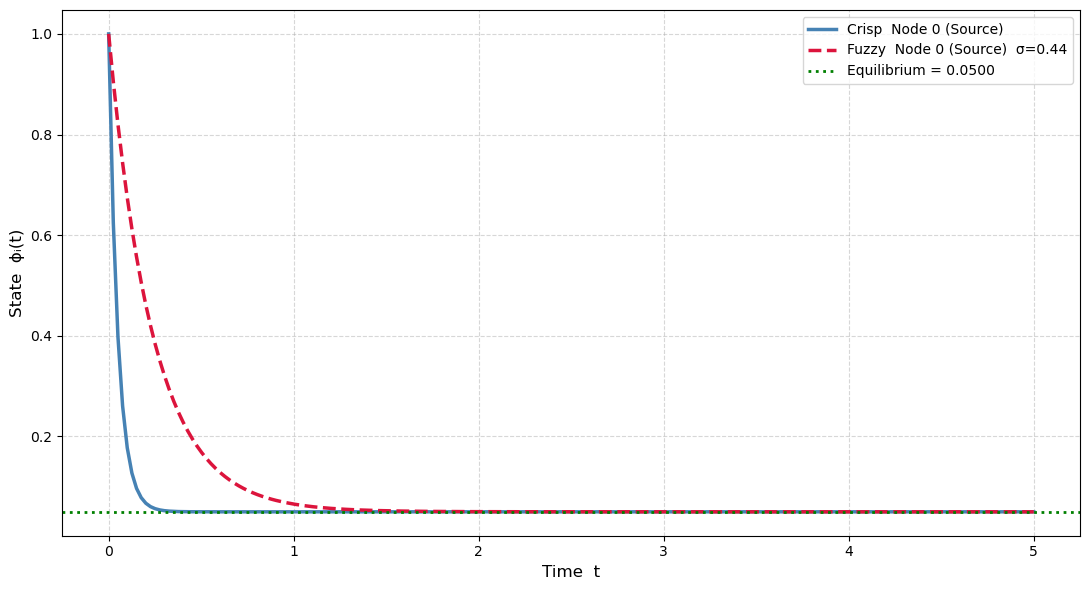

In [25]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

# ── Parameters ─────────────────────────────────────────────────────────────────
NUM_NODES  = 20
T_END      = 5
NUM_STEPS  = 200
C          = 1.0
time_steps = np.linspace(0, T_END, NUM_STEPS)

# ══════════════════════════════════════════════════════════════════════════════
# CRISP COMPLETE NETWORK
# ══════════════════════════════════════════════════════════════════════════════
G_crisp = nx.complete_graph(NUM_NODES)

n_c   = G_crisp.number_of_nodes()
idx_c = {node: i for i, node in enumerate(G_crisp.nodes())}

A = np.zeros((n_c, n_c))
for u, v in G_crisp.edges():
    A[idx_c[u]][idx_c[v]] = 1
    A[idx_c[v]][idx_c[u]] = 1

L = np.diag(A.sum(axis=1)) - A

phi0_c         = np.zeros(n_c)
phi0_c[idx_c[0]] = 1.0
equilibrium_c  = phi0_c.sum() / n_c

phi_t_c = np.zeros((NUM_STEPS, n_c))
for k, t in enumerate(time_steps):
    phi_t_c[k] = expm(-C * t * L) @ phi0_c

# ══════════════════════════════════════════════════════════════════════════════
# FUZZY COMPLETE NETWORK
# ══════════════════════════════════════════════════════════════════════════════
G = nx.Graph()

np.random.seed(42)
for node in range(NUM_NODES):
    sigma = round(np.random.uniform(0.1, 1.0), 2)
    G.add_node(node, sigma=sigma)

for u in range(NUM_NODES):
    for v in range(u + 1, NUM_NODES):
        sigma_u = G.nodes[u]['sigma']
        sigma_v = G.nodes[v]['sigma']
        mu      = round(np.random.uniform(0.1, min(sigma_u, sigma_v)), 2)
        G.add_edge(u, v, mu=mu)

n_f   = G.number_of_nodes()
idx_f = {node: i for i, node in enumerate(G.nodes())}

Af = np.zeros((n_f, n_f))
for u, v, data in G.edges(data=True):
    Af[idx_f[u]][idx_f[v]] = data['mu']
    Af[idx_f[v]][idx_f[u]] = data['mu']

Lf = np.diag(Af.sum(axis=1)) - Af

phi0_f           = np.zeros(n_f)
phi0_f[idx_f[0]] = 1.0
equilibrium_f    = phi0_f.sum() / n_f

phi_t_f = np.zeros((NUM_STEPS, n_f))
for k, t in enumerate(time_steps):
    phi_t_f[k] = expm(-t * Lf) @ phi0_f

# ══════════════════════════════════════════════════════════════════════════════
# COMBINED PLOT
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(time_steps, phi_t_c[:, idx_c[0]],
        label="Crisp  Node 0 (Source)",
        color='steelblue', linewidth=2.5, linestyle='-')

ax.plot(time_steps, phi_t_f[:, idx_f[0]],
        label=f"Fuzzy  Node 0 (Source)  σ={G.nodes[0]['sigma']}",
        color='crimson', linewidth=2.5, linestyle='--')

ax.axhline(y=equilibrium_c, color='green', linestyle=':', linewidth=2,
           label=f"Equilibrium = {equilibrium_c:.4f}")

ax.set_xlabel("Time  t", fontsize=12)
ax.set_ylabel("State  ϕᵢ(t)", fontsize=12)
#ax.set_title("Comparison of The Diffusion between the Hub node of a crisps and fuzzy K20\n"
            # , fontsize=13)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("fuzzy_vs_crisp_diffusion_K20.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# 3. CYCLE $C_{10}$ #
## Diffusion on a Fuzzy $C_{10}$

Fuzzy Adjacency Matrix Af:
[[0.   0.11 0.   0.   0.   0.   0.   0.   0.   0.2 ]
 [0.11 0.   0.74 0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.74 0.   0.55 0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.55 0.   0.13 0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.13 0.   0.13 0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.13 0.   0.11 0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.11 0.   0.12 0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.12 0.   0.38 0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.38 0.   0.33]
 [0.2  0.   0.   0.   0.   0.   0.   0.   0.33 0.  ]]

Fuzzy Degree Matrix Df:
[[0.31 0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.85 0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   1.29 0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.68 0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.26 0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.24 0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.23 0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.5  0.  

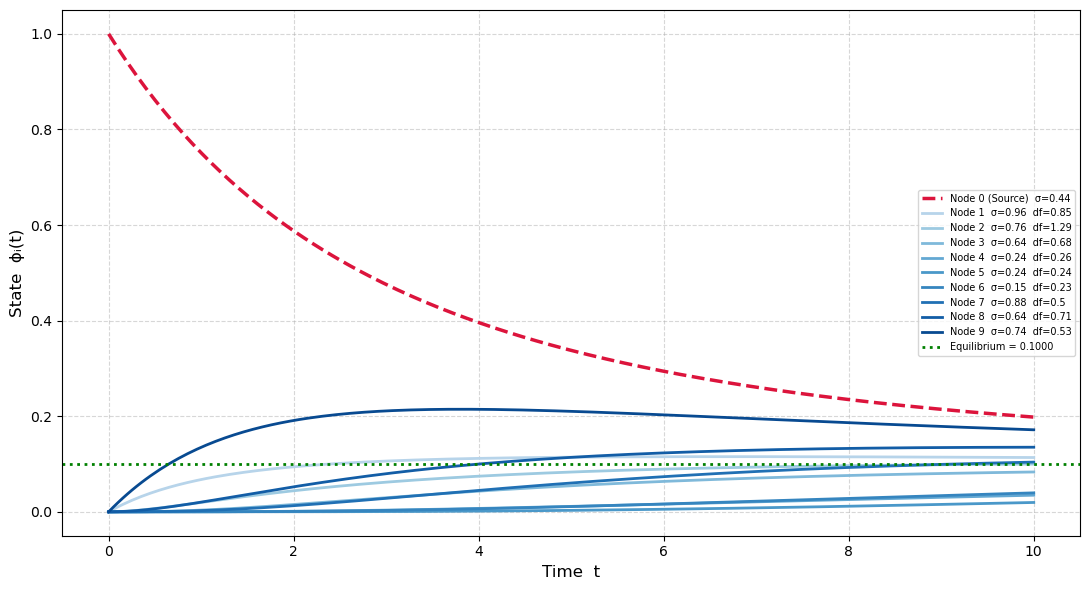

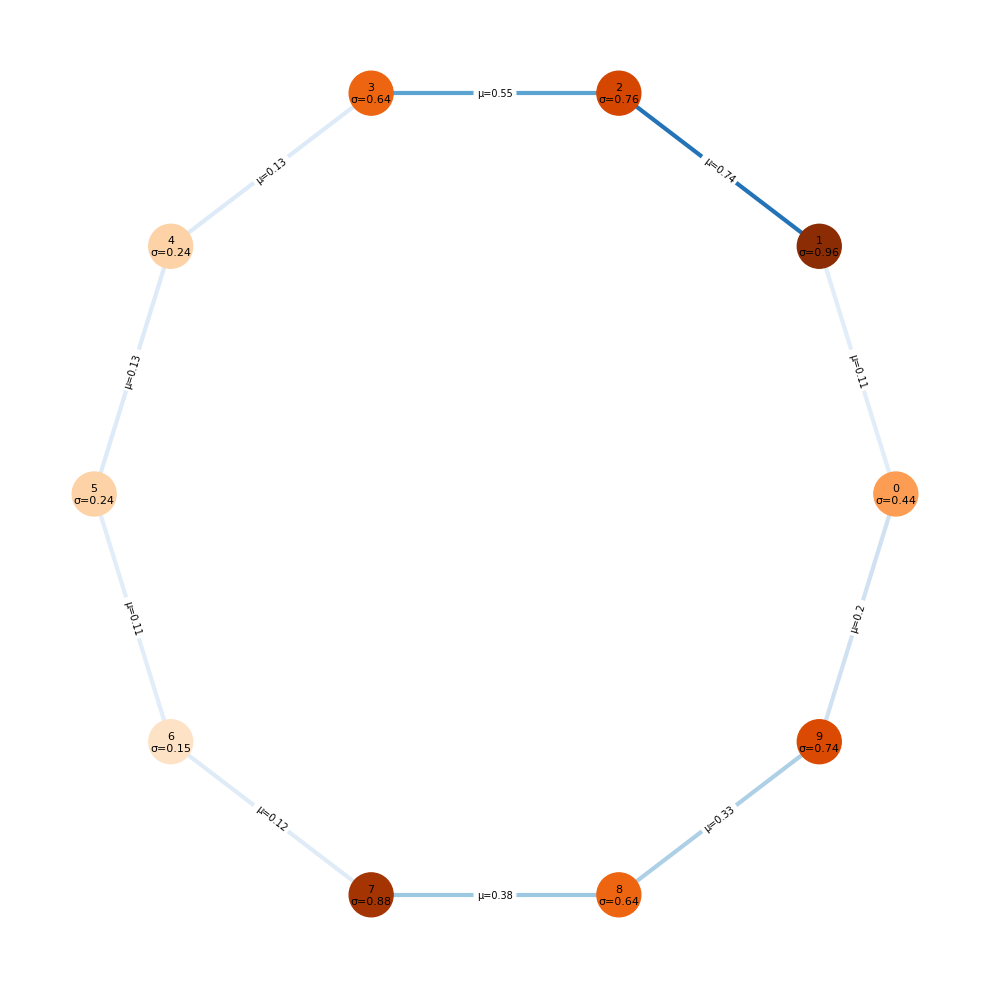


              DIFFUSION SUMMARY
Network         : Fuzzy Cycle C10  (10 nodes)
Source node     : Node 0,  ϕ(0) = 1.0
Equilibrium     : 0.1000  (= 1/n = 1/10)
Total edges     : 10  (= n for a cycle)

Final states at t = 10:
  Node 0: ϕ(10) = 0.1982
  Node 1: ϕ(10) = 0.1136
  Node 2: ϕ(10) = 0.0999
  Node 3: ϕ(10) = 0.0834
  Node 4: ϕ(10) = 0.0348
  Node 5: ϕ(10) = 0.0196
  Node 6: ϕ(10) = 0.0397
  Node 7: ϕ(10) = 0.1041
  Node 8: ϕ(10) = 0.1352
  Node 9: ϕ(10) = 0.1716

Fuzzy degree df(i) and edge memberships per node:
  Node 0: df = 0.31  (µ to Node 1 = 0.11,  µ to Node 9 = 0.2)
  Node 1: df = 0.85  (µ to Node 0 = 0.11,  µ to Node 2 = 0.74)
  Node 2: df = 1.29  (µ to Node 1 = 0.74,  µ to Node 3 = 0.55)
  Node 3: df = 0.68  (µ to Node 2 = 0.55,  µ to Node 4 = 0.13)
  Node 4: df = 0.26  (µ to Node 3 = 0.13,  µ to Node 5 = 0.13)
  Node 5: df = 0.24  (µ to Node 4 = 0.13,  µ to Node 6 = 0.11)
  Node 6: df = 0.23  (µ to Node 5 = 0.11,  µ to Node 7 = 0.12)
  Node 7: df = 0.5  (µ to Node 6 = 0

In [26]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.linalg import expm

# ── Parameters ────────────────────────────────────────────────────────────────
NUM_NODES  = 10
T_END      = 10
NUM_STEPS  = 200

# ── Step 1: Build the Fuzzy Cycle Graph C10 ───────────────────────────────────
G = nx.Graph()

np.random.seed(42)
for node in range(NUM_NODES):
    sigma = round(np.random.uniform(0.1, 1.0), 2)
    G.add_node(node, sigma=sigma)

cycle_edges = [(i, (i + 1) % NUM_NODES) for i in range(NUM_NODES)]
for u, v in cycle_edges:
    sigma_u  = G.nodes[u]['sigma']
    sigma_v  = G.nodes[v]['sigma']
    max_mu   = min(sigma_u, sigma_v)
    mu       = round(np.random.uniform(0.1, max_mu), 2)
    G.add_edge(u, v, mu=mu)

# ── Step 2: Build the Fuzzy Laplacian Matrix Lf = Df - Af ────────────────────
n     = G.number_of_nodes()
nodes = list(G.nodes())
idx   = {node: i for i, node in enumerate(nodes)}

Af = np.zeros((n, n))
for u, v, data in G.edges(data=True):
    i, j     = idx[u], idx[v]
    Af[i][j] = data['mu']
    Af[j][i] = data['mu']

Df = np.diag(Af.sum(axis=1))
Lf = Df - Af

print("Fuzzy Adjacency Matrix Af:")
print(np.round(Af, 2))
print("\nFuzzy Degree Matrix Df:")
print(np.round(Df, 2))
print("\nFuzzy Laplacian Matrix Lf:")
print(np.round(Lf, 2))

# ── Step 3: Set Initial Conditions ϕ(0) ──────────────────────────────────────
phi0         = np.zeros(n)
phi0[idx[0]] = 1.0
equilibrium  = phi0.sum() / n

print(f"\nInitial state ϕ(0)     : {phi0}")
print(f"Theoretical equilibrium : {equilibrium:.4f}  (= 1/n = 1/{n})")
print(f"\nNode memberships σ:")
for nd in G.nodes():
    print(f"  Node {nd}: σ = {G.nodes[nd]['sigma']}")

# ── Step 4: Simulate Fuzzy Diffusion ϕ(t) = e^{-t*Lf} ϕ(0) ──────────────────
time_steps = np.linspace(0, T_END, NUM_STEPS)
phi_t      = np.zeros((NUM_STEPS, n))

for k, t in enumerate(time_steps):
    phi_t[k] = expm(-t * Lf) @ phi0

# ── Step 5: Plot Diffusion Curves ─────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(11, 6))

ax1.plot(time_steps, phi_t[:, idx[0]],
         label=f"Node 0 (Source)  σ={G.nodes[0]['sigma']}",
         color='crimson', linewidth=2.5, linestyle='--')

colors = cm.Blues(np.linspace(0.3, 0.9, NUM_NODES - 1))
for i in range(1, NUM_NODES):
    nbrs = list(G.neighbors(i))
    df_i = round(sum(G[i][j]['mu'] for j in nbrs), 3)
    ax1.plot(time_steps, phi_t[:, idx[i]],
             label=f"Node {i}  σ={G.nodes[i]['sigma']}  df={df_i}",
             color=colors[i - 1], linewidth=2)

ax1.axhline(y=equilibrium, color='green', linestyle=':', linewidth=2,
            label=f"Equilibrium = {equilibrium:.4f}")

ax1.set_xlabel("Time  t", fontsize=12)
ax1.set_ylabel("State  ϕᵢ(t)", fontsize=12)
#ax1.set_title("Diffusion on a Fuzzy C10 Network\n"
             # "ϕ(t) = e^{−tLf} ϕ(0)  |  Source: Node 0", fontsize=11)
ax1.legend(fontsize=7, loc='right')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("Diffusion_on_Fuzzy_C10.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# ── Step 6: Visualise the Fuzzy Cycle Graph ───────────────────────────────────
pos          = nx.circular_layout(G)
active_edges = [(u, v) for u, v in G.edges()]
edge_mus     = [G[u][v]['mu'] for u, v in active_edges]
edge_colors  = [cm.Blues(mu) for mu in edge_mus]
node_sigmas  = [G.nodes[nd]['sigma'] for nd in G.nodes()]
node_labels  = {nd: f"{nd}\nσ={G.nodes[nd]['sigma']}" for nd in G.nodes()}
edge_labels  = {(u, v): f"µ={G[u][v]['mu']}" for u, v in active_edges}

fig2, ax2 = plt.subplots(figsize=(10, 10))

nx.draw_networkx_nodes(G, pos,
                       node_color=node_sigmas,
                       cmap=plt.cm.Oranges,
                       node_size=1000,
                       vmin=0, vmax=1,
                       ax=ax2)

nx.draw_networkx_edges(G, pos,
                       edgelist=active_edges,
                       edge_color=edge_colors,
                       width=3,
                       ax=ax2)

nx.draw_networkx_labels(G, pos,
                        labels=node_labels,
                        font_size=8,
                        ax=ax2)

nx.draw_networkx_edge_labels(G, pos,
                             edge_labels=edge_labels,
                             font_size=7,
                             ax=ax2)

#ax2.set_title(f"Fuzzy C{NUM_NODES} Network\n"
             # ,
             # fontsize=11)
ax2.axis("off")
plt.tight_layout()
plt.savefig("fuzzy_C10_network.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# ── Step 7: Print Final Summary ───────────────────────────────────────────────
print(f"\n{'=' * 55}")
print(f"              DIFFUSION SUMMARY")
print(f"{'=' * 55}")
print(f"Network         : Fuzzy Cycle C{NUM_NODES}  ({n} nodes)")
print(f"Source node     : Node 0,  ϕ(0) = 1.0")
print(f"Equilibrium     : {equilibrium:.4f}  (= 1/n = 1/{n})")
print(f"Total edges     : {G.number_of_edges()}  (= n for a cycle)")
print(f"\nFinal states at t = {T_END}:")
for node in nodes:
    print(f"  Node {node}: ϕ({T_END}) = {phi_t[-1, idx[node]]:.4f}")
print(f"\nFuzzy degree df(i) and edge memberships per node:")
for nd in nodes:
    nbrs     = list(G.neighbors(nd))
    mu_left  = G[nd][nbrs[0]]['mu']
    mu_right = G[nd][nbrs[1]]['mu']
    df       = round(mu_left + mu_right, 3)
    print(f"  Node {nd}: df = {df}  "
          f"(µ to Node {nbrs[0]} = {mu_left},  "
          f"µ to Node {nbrs[1]} = {mu_right})")
print(f"\nKey Observations:")
print(f"  1. All nodes have crisp degree 2 but unique fuzzy degrees df(i)")
print(f"  2. Substance travels clockwise AND anticlockwise from Node 0")
print(f"  3. Low µ edges act as bottlenecks — slowing diffusion along that path")
print(f"  4. Node 5 (antipodal) is last to receive substance from both directions")
print(f"  5. Unlike crisp C10, the two ring paths carry different µ values")
print(f"     producing asymmetric diffusion — invisible in the crisp model")

## Diffusion on a Fuzzy $C_{20}$

Fuzzy Adjacency Matrix Af:
[[0.   0.31 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.21]
 [0.31 0.   0.19 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.  ]
 [0.   0.19 0.   0.26 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.26 0.   0.15 0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.15 0.   0.16 0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.16 0.   0.14 0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.14 0.   0.11 0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.11 0.   0.38 0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.38 0.   0.42 0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.42

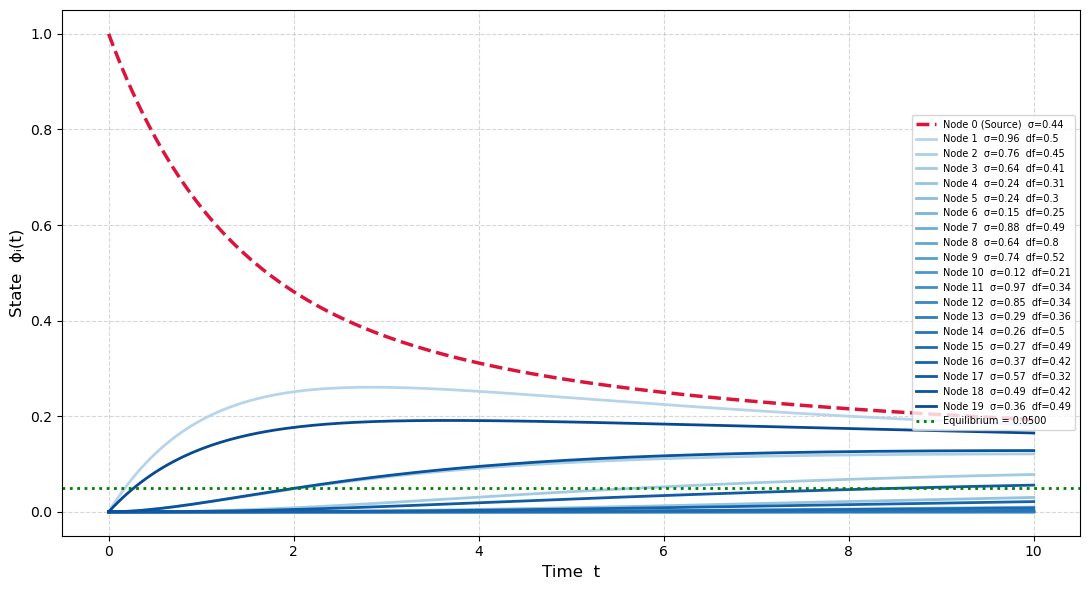

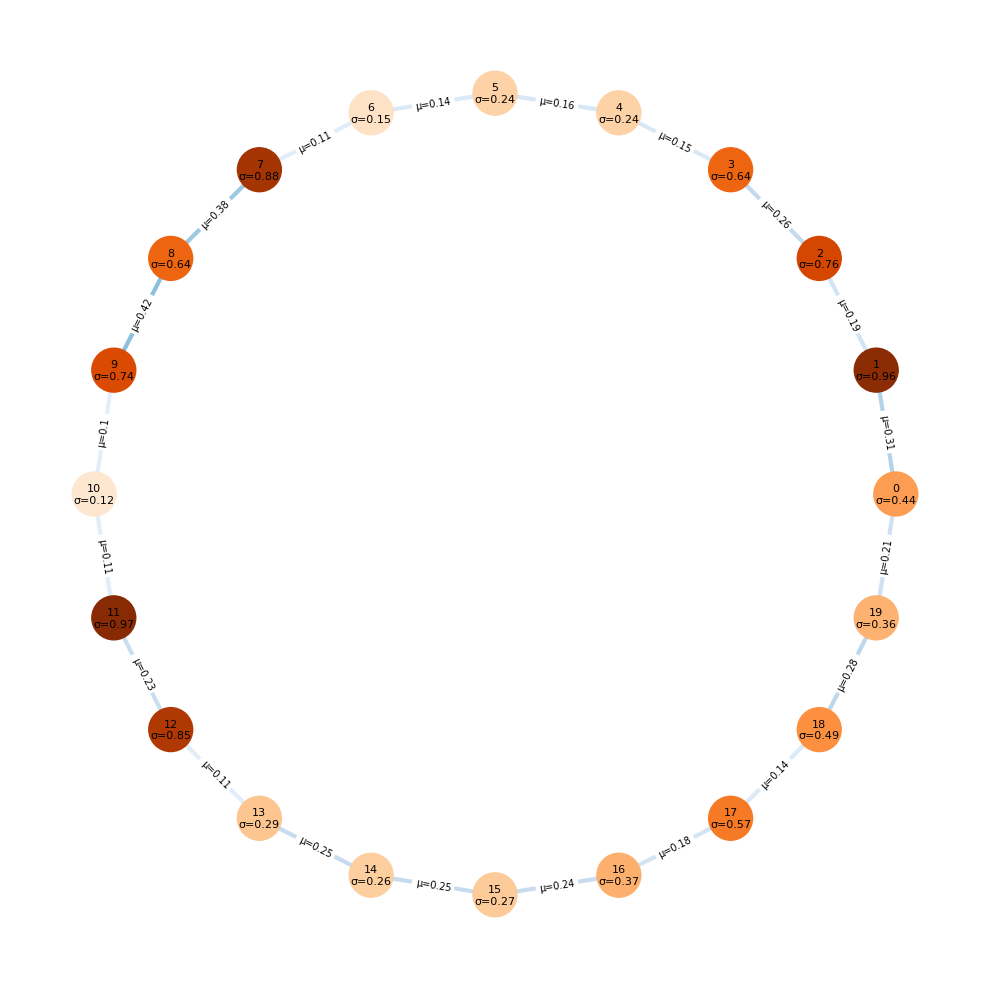


              DIFFUSION SUMMARY
Network         : Fuzzy Cycle C20  (20 nodes)
Source node     : Node 0,  ϕ(0) = 1.0
Equilibrium     : 0.0500  (= 1/n = 1/20)
Total edges     : 20  (= n for a cycle)

Final states at t = 10:
  Node 0: ϕ(10) = 0.1931
  Node 1: ϕ(10) = 0.1817
  Node 2: ϕ(10) = 0.1212
  Node 3: ϕ(10) = 0.0781
  Node 4: ϕ(10) = 0.0301
  Node 5: ϕ(10) = 0.0099
  Node 6: ϕ(10) = 0.0025
  Node 7: ϕ(10) = 0.0004
  Node 8: ϕ(10) = 0.0001
  Node 9: ϕ(10) = 0.0000
  Node 10: ϕ(10) = 0.0000
  Node 11: ϕ(10) = 0.0000
  Node 12: ϕ(10) = 0.0001
  Node 13: ϕ(10) = 0.0010
  Node 14: ϕ(10) = 0.0029
  Node 15: ϕ(10) = 0.0083
  Node 16: ϕ(10) = 0.0214
  Node 17: ϕ(10) = 0.0559
  Node 18: ϕ(10) = 0.1282
  Node 19: ϕ(10) = 0.1649

Fuzzy degree df(i) and edge memberships per node:
  Node 0: df = 0.52  (µ to Node 1 = 0.31,  µ to Node 19 = 0.21)
  Node 1: df = 0.5  (µ to Node 0 = 0.31,  µ to Node 2 = 0.19)
  Node 2: df = 0.45  (µ to Node 1 = 0.19,  µ to Node 3 = 0.26)
  Node 3: df = 0.41  (µ to 

In [27]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.linalg import expm

# ── Parameters ────────────────────────────────────────────────────────────────
NUM_NODES  = 20
T_END      = 10
NUM_STEPS  = 200

# ── Step 1: Build the Fuzzy Cycle Graph C10 ───────────────────────────────────
G = nx.Graph()

np.random.seed(42)
for node in range(NUM_NODES):
    sigma = round(np.random.uniform(0.1, 1.0), 2)
    G.add_node(node, sigma=sigma)

cycle_edges = [(i, (i + 1) % NUM_NODES) for i in range(NUM_NODES)]
for u, v in cycle_edges:
    sigma_u  = G.nodes[u]['sigma']
    sigma_v  = G.nodes[v]['sigma']
    max_mu   = min(sigma_u, sigma_v)
    mu       = round(np.random.uniform(0.1, max_mu), 2)
    G.add_edge(u, v, mu=mu)

# ── Step 2: Build the Fuzzy Laplacian Matrix Lf = Df - Af ────────────────────
n     = G.number_of_nodes()
nodes = list(G.nodes())
idx   = {node: i for i, node in enumerate(nodes)}

Af = np.zeros((n, n))
for u, v, data in G.edges(data=True):
    i, j     = idx[u], idx[v]
    Af[i][j] = data['mu']
    Af[j][i] = data['mu']

Df = np.diag(Af.sum(axis=1))
Lf = Df - Af

print("Fuzzy Adjacency Matrix Af:")
print(np.round(Af, 2))
print("\nFuzzy Degree Matrix Df:")
print(np.round(Df, 2))
print("\nFuzzy Laplacian Matrix Lf:")
print(np.round(Lf, 2))

# ── Step 3: Set Initial Conditions ϕ(0) ──────────────────────────────────────
phi0         = np.zeros(n)
phi0[idx[0]] = 1.0
equilibrium  = phi0.sum() / n

print(f"\nInitial state ϕ(0)     : {phi0}")
print(f"Theoretical equilibrium : {equilibrium:.4f}  (= 1/n = 1/{n})")
print(f"\nNode memberships σ:")
for nd in G.nodes():
    print(f"  Node {nd}: σ = {G.nodes[nd]['sigma']}")

# ── Step 4: Simulate Fuzzy Diffusion ϕ(t) = e^{-t*Lf} ϕ(0) ──────────────────
time_steps = np.linspace(0, T_END, NUM_STEPS)
phi_t      = np.zeros((NUM_STEPS, n))

for k, t in enumerate(time_steps):
    phi_t[k] = expm(-t * Lf) @ phi0

# ── Step 5: Plot Diffusion Curves ─────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(11, 6))

ax1.plot(time_steps, phi_t[:, idx[0]],
         label=f"Node 0 (Source)  σ={G.nodes[0]['sigma']}",
         color='crimson', linewidth=2.5, linestyle='--')

colors = cm.Blues(np.linspace(0.3, 0.9, NUM_NODES - 1))
for i in range(1, NUM_NODES):
    nbrs = list(G.neighbors(i))
    df_i = round(sum(G[i][j]['mu'] for j in nbrs), 3)
    ax1.plot(time_steps, phi_t[:, idx[i]],
             label=f"Node {i}  σ={G.nodes[i]['sigma']}  df={df_i}",
             color=colors[i - 1], linewidth=2)

ax1.axhline(y=equilibrium, color='green', linestyle=':', linewidth=2,
            label=f"Equilibrium = {equilibrium:.4f}")

ax1.set_xlabel("Time  t", fontsize=12)
ax1.set_ylabel("State  ϕᵢ(t)", fontsize=12)
#ax1.set_title("Diffusion on a Fuzzy C20 Network\n"
             # "ϕ(t) = e^{−tLf} ϕ(0)  |  Source: Node 0", fontsize=11)
ax1.legend(fontsize=7, loc='right')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("Diffusion_on_a_fuzzy_C20.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# ── Step 6: Visualise the Fuzzy Cycle Graph ───────────────────────────────────
pos          = nx.circular_layout(G)
active_edges = [(u, v) for u, v in G.edges()]
edge_mus     = [G[u][v]['mu'] for u, v in active_edges]
edge_colors  = [cm.Blues(mu) for mu in edge_mus]
node_sigmas  = [G.nodes[nd]['sigma'] for nd in G.nodes()]
node_labels  = {nd: f"{nd}\nσ={G.nodes[nd]['sigma']}" for nd in G.nodes()}
edge_labels  = {(u, v): f"µ={G[u][v]['mu']}" for u, v in active_edges}

fig2, ax2 = plt.subplots(figsize=(10, 10))

nx.draw_networkx_nodes(G, pos,
                       node_color=node_sigmas,
                       cmap=plt.cm.Oranges,
                       node_size=1000,
                       vmin=0, vmax=1,
                       ax=ax2)

nx.draw_networkx_edges(G, pos,
                       edgelist=active_edges,
                       edge_color=edge_colors,
                       width=3,
                       ax=ax2)

nx.draw_networkx_labels(G, pos,
                        labels=node_labels,
                        font_size=8,
                        ax=ax2)

nx.draw_networkx_edge_labels(G, pos,
                             edge_labels=edge_labels,
                             font_size=7,
                             ax=ax2)

#ax2.set_title(f"Fuzzy C{NUM_NODES} Network\n"
            #  ,
             # fontsize=11)
ax2.axis("off")
plt.tight_layout()
plt.savefig("fuzzy_C20_network.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# ── Step 7: Print Final Summary ───────────────────────────────────────────────
print(f"\n{'=' * 55}")
print(f"              DIFFUSION SUMMARY")
print(f"{'=' * 55}")
print(f"Network         : Fuzzy Cycle C{NUM_NODES}  ({n} nodes)")
print(f"Source node     : Node 0,  ϕ(0) = 1.0")
print(f"Equilibrium     : {equilibrium:.4f}  (= 1/n = 1/{n})")
print(f"Total edges     : {G.number_of_edges()}  (= n for a cycle)")
print(f"\nFinal states at t = {T_END}:")
for node in nodes:
    print(f"  Node {node}: ϕ({T_END}) = {phi_t[-1, idx[node]]:.4f}")
print(f"\nFuzzy degree df(i) and edge memberships per node:")
for nd in nodes:
    nbrs     = list(G.neighbors(nd))
    mu_left  = G[nd][nbrs[0]]['mu']
    mu_right = G[nd][nbrs[1]]['mu']
    df       = round(mu_left + mu_right, 3)
    print(f"  Node {nd}: df = {df}  "
          f"(µ to Node {nbrs[0]} = {mu_left},  "
          f"µ to Node {nbrs[1]} = {mu_right})")
print(f"\nKey Observations:")
print(f"  1. All nodes have crisp degree 2 but unique fuzzy degrees df(i)")
print(f"  2. Substance travels clockwise AND anticlockwise from Node 0")
print(f"  3. Low µ edges act as bottlenecks — slowing diffusion along that path")
print(f"  4. Node 5 (antipodal) is last to receive substance from both directions")
print(f"  5. Unlike crisp C10, the two ring paths carry different µ values")
print(f"     producing asymmetric diffusion — invisible in the crisp model")

## Fuzzy Diffusion (Hub Node) Comparison  $C_{10}$ vs $C_{20}$

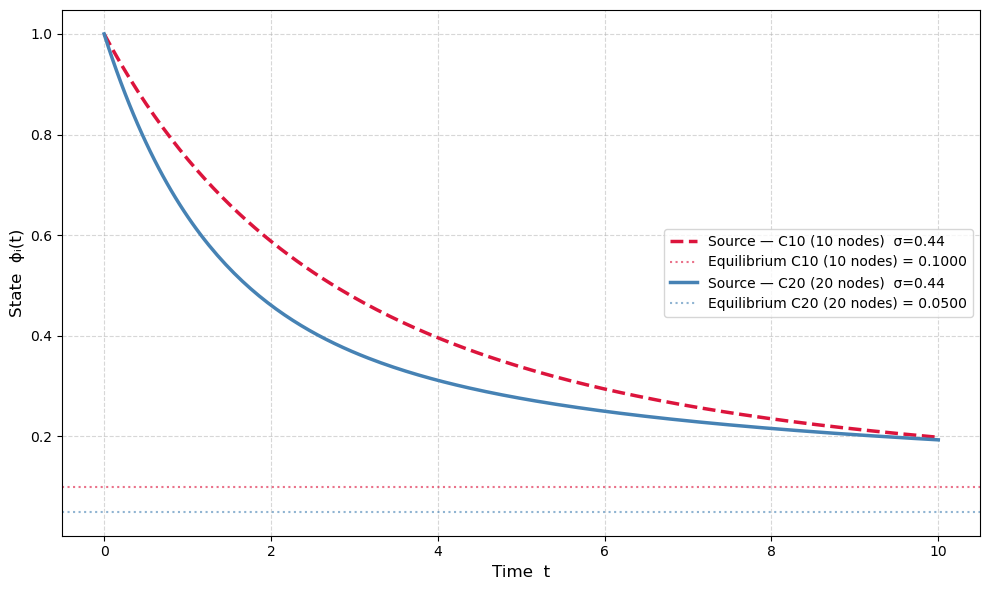

In [28]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

T_END, NUM_STEPS = 10, 200
time_steps = np.linspace(0, T_END, NUM_STEPS)

configs = [
    {"NUM_NODES": 10, "color": "crimson",   "linestyle": "--", "label": "C10 (10 nodes)"},
    {"NUM_NODES": 20, "color": "steelblue", "linestyle": "-",  "label": "C20 (20 nodes)"},
]

fig, ax = plt.subplots(figsize=(10, 6))

for cfg in configs:
    NUM_NODES = cfg["NUM_NODES"]

    # Build fuzzy cycle graph
    G = nx.Graph()
    np.random.seed(42)
    for node in range(NUM_NODES):
        G.add_node(node, sigma=round(np.random.uniform(0.1, 1.0), 2))
    for u, v in [(i, (i + 1) % NUM_NODES) for i in range(NUM_NODES)]:
        max_mu = min(G.nodes[u]['sigma'], G.nodes[v]['sigma'])
        G.add_edge(u, v, mu=round(np.random.uniform(0.1, max_mu), 2))

    # Fuzzy Laplacian
    n   = G.number_of_nodes()
    idx = {node: i for i, node in enumerate(G.nodes())}
    Af  = np.zeros((n, n))
    for u, v, data in G.edges(data=True):
        Af[idx[u]][idx[v]] = Af[idx[v]][idx[u]] = data['mu']
    Lf = np.diag(Af.sum(axis=1)) - Af

    # Initial conditions
    phi0         = np.zeros(n)
    phi0[idx[0]] = 1.0
    equilibrium  = phi0.sum() / n

    # Simulate
    phi_t = np.array([expm(-t * Lf) @ phi0 for t in time_steps])

    # Plot
    ax.plot(time_steps, phi_t[:, idx[0]],
            color=cfg["color"], linestyle=cfg["linestyle"], linewidth=2.5,
            label=f"Source — {cfg['label']}  σ={G.nodes[0]['sigma']}")

    ax.axhline(y=equilibrium, color=cfg["color"], linestyle=":", linewidth=1.5, alpha=0.6,
               label=f"Equilibrium {cfg['label']} = {equilibrium:.4f}")

ax.set_xlabel("Time  t", fontsize=12)
ax.set_ylabel("State  ϕᵢ(t)", fontsize=12)
#ax.set_title("Comparison of the diffusion between the hub nodes of the fuzzy C10 vs C20\n"
           # , fontsize=13)
ax.legend(fontsize=10, loc='right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("Diffusion_Comparison_Fuzzy_C10_vs_C20.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

## Diffusion on a Crisps $C_{10}$

      CLASSICAL CRISP CYCLE GRAPH C10

Adjacency Matrix A:
[[0. 1. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 1. 0.]]

Degree Matrix D:
[[2. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 2. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 2. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 2. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 2. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 2. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 2. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 2. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 2. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 2.]]

Laplacian Matrix L:
[[ 2. -1.  0.  0.  0.  0.  0.  0.  0. -1.]
 [-1.  2. -1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  2. -1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -1.  2. -1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -1.  2. -1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -1.  2.

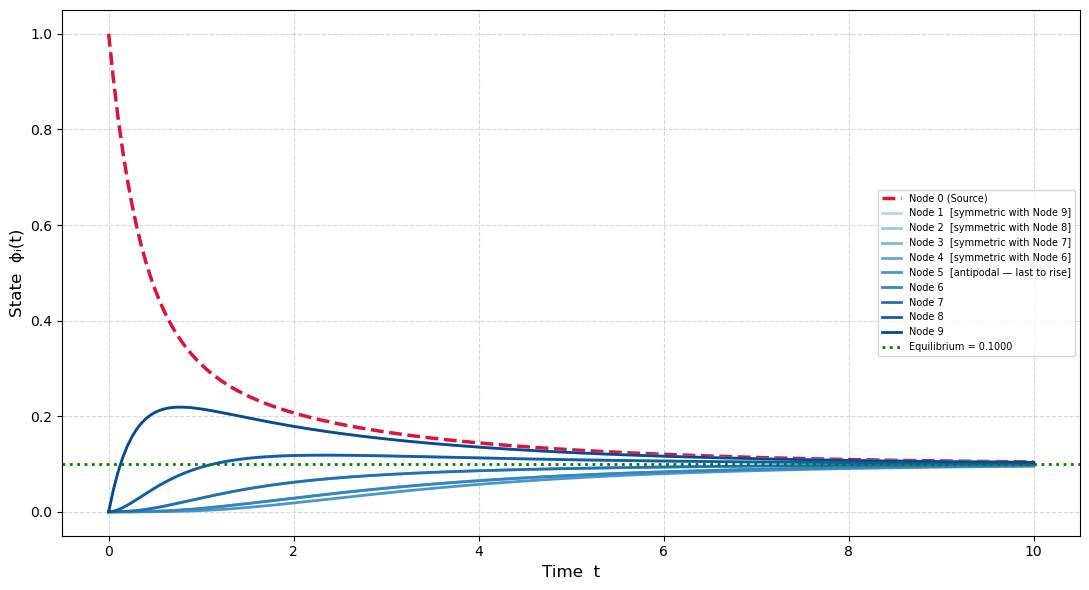

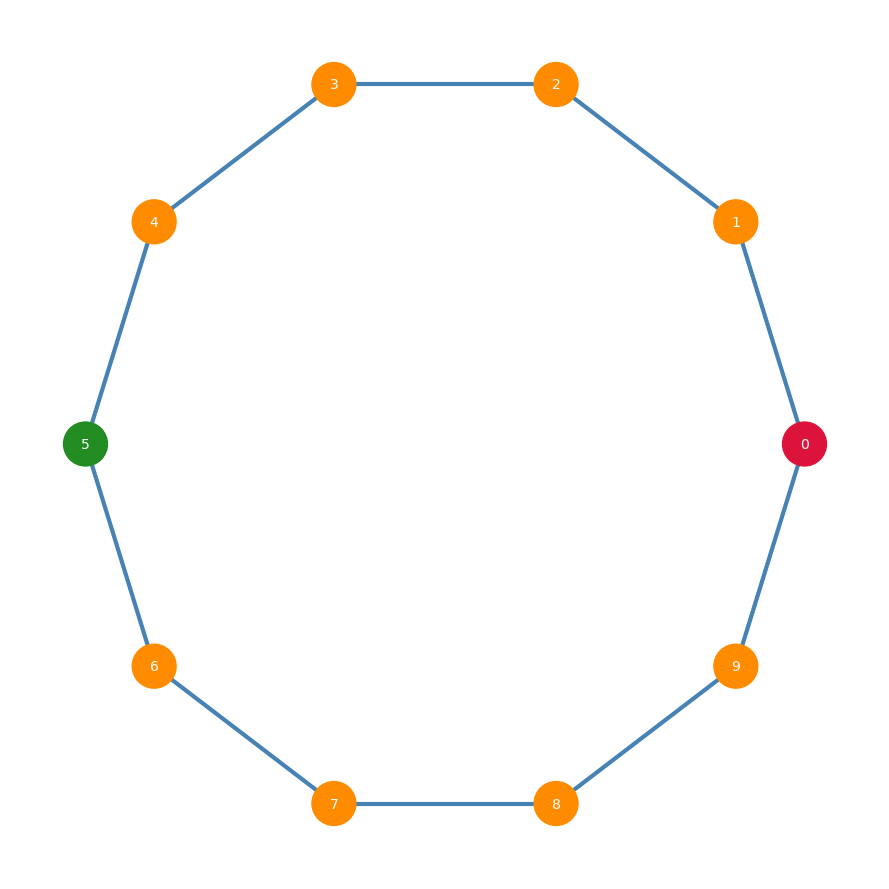


              DIFFUSION SUMMARY
Network         : Crisp Cycle C10  (10 nodes)
Source node     : Node 0,  ϕ(0) = 1.0
Diffusion const : C = 1.0
Equilibrium     : 0.1000  (= 1/n = 1/10)
Total edges     : 10  (= n for a cycle)
Regular         : Yes — every node has degree 2

Final states at t = 10:
  Node 0: ϕ(10) = 0.1044
  Node 1: ϕ(10) = 0.1035
  Node 2: ϕ(10) = 0.1014
  Node 3: ϕ(10) = 0.0986
  Node 4: ϕ(10) = 0.0965
  Node 5: ϕ(10) = 0.0956
  Node 6: ϕ(10) = 0.0965
  Node 7: ϕ(10) = 0.0986
  Node 8: ϕ(10) = 0.1014
  Node 9: ϕ(10) = 0.1035

Symmetric node pairs (same hop distance from source):
  Node 1 and Node 9  — both 1 hops from Node 0  (ϕ at t=10: 0.1035 vs 0.1035)
  Node 2 and Node 8  — both 2 hops from Node 0  (ϕ at t=10: 0.1014 vs 0.1014)
  Node 3 and Node 7  — both 3 hops from Node 0  (ϕ at t=10: 0.0986 vs 0.0986)
  Node 4 and Node 6  — both 4 hops from Node 0  (ϕ at t=10: 0.0965 vs 0.0965)
  Node 5  — antipodal  — 5 hops from Node 0  (ϕ at t=10: 0.0956)

Key Observations:
  

In [29]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.linalg import expm

# ── Parameters ─────────────────────────────────────────────────────────────────
# A cycle graph C10 connects nodes in a closed ring: 0-1-2-...-9-0
# Unlike the path P10, there IS a closing edge between node 9 and node 0.
# From Definition 2.2.8: a cycle is a path with the same start and end node.
# Every node has exactly degree 2 — making C10 a 2-regular graph.
# From Definition 2.2.6: a network is k-regular if all vertices have degree k.
NUM_NODES  = 10
T_END      = 10
NUM_STEPS  = 200
C          = 1.0       # diffusion constant

# ── Step 1: Build the Crisp Cycle Graph C10 ────────────────────────────────────
# nx.cycle_graph(n) builds C_n — every node connects to exactly two neighbours,
# forming one closed ring. All edges are binary (weight = 1).

G_crisp = nx.cycle_graph(NUM_NODES)

# ── Step 2: Build Classical Matrices A, D, L ───────────────────────────────────
# A — binary adjacency matrix: Aij = 1 if edge exists, 0 otherwise
# D — degree matrix: diagonal, every entry = 2 (all nodes have degree 2)
# L — classical Laplacian: L = D - A (Section 2.3.5)
# Used in classical diffusion equation (3.2.7): dϕ/dt = -CLϕ

n     = G_crisp.number_of_nodes()
nodes = list(G_crisp.nodes())
idx   = {node: i for i, node in enumerate(nodes)}

# Binary adjacency matrix
A = np.zeros((n, n))
for u, v in G_crisp.edges():
    i, j    = idx[u], idx[v]
    A[i][j] = 1
    A[j][i] = 1              # symmetric — undirected

# Degree matrix — all diagonal entries = 2 for a cycle
D = np.diag(A.sum(axis=1))

# Classical Laplacian
L = D - A

print("=" * 55)
print("      CLASSICAL CRISP CYCLE GRAPH C10")
print("=" * 55)
print("\nAdjacency Matrix A:")
print(np.round(A, 2))
print("\nDegree Matrix D:")
print(np.round(D, 2))
print("\nLaplacian Matrix L:")
print(np.round(L, 2))

# Verify every node has degree 2
print(f"\nNode degrees (should all be 2):")
for nd in G_crisp.nodes():
    print(f"  Node {nd}: degree = {G_crisp.degree(nd)}")

# ── Step 3: Set Initial Conditions ϕ(0) ───────────────────────────────────────
# Node 0 is the single source — starts with all the substance (value = 1.0).
# All other nodes start at 0.0.
# Substance travels BOTH clockwise (0→1→2→...→9) and
# anticlockwise (0→9→8→...→1) simultaneously — two symmetric paths.
# Node 5 (antipodal — exactly 5 hops away in both directions) is last.
# From equation (3.2.8): ϕ(t) = e^{-CtL} ϕ(0)

phi0         = np.zeros(n)
phi0[idx[0]] = 1.0

equilibrium  = phi0.sum() / n    # Theorem 3.3.2: all nodes converge to 1/n

print(f"\nInitial state ϕ(0)     : {phi0}")
print(f"Theoretical equilibrium : {equilibrium:.4f}  (= 1/n = 1/{n})")

# ── Step 4: Simulate Classical Diffusion ϕ(t) = e^{-CtL} ϕ(0) ────────────────
# In a crisp cycle all edges have weight 1, so the two ring paths
# (clockwise and anticlockwise) carry substance at exactly the same rate.
# This produces a SYMMETRIC diffusion pattern:
#   Node 1 and Node 9  rise together (both 1 hop from source)
#   Node 2 and Node 8  rise together (both 2 hops from source)
#   Node 3 and Node 7  rise together (both 3 hops from source)
#   Node 4 and Node 6  rise together (both 4 hops from source)
#   Node 5             rises last    (5 hops — antipodal node)
# This symmetry collapses in the fuzzy model where µ values differ per edge.

time_steps = np.linspace(0, T_END, NUM_STEPS)
phi_t      = np.zeros((NUM_STEPS, n))

for k, t in enumerate(time_steps):
    phi_t[k] = expm(-C * t * L) @ phi0

# ── Step 5: Plot Diffusion Curves ──────────────────────────────────────────────
# Key visual: symmetric node pairs overlap perfectly in the crisp model
# because both ring paths carry identical weight.
# Node 1 = Node 9, Node 2 = Node 8, Node 3 = Node 7, Node 4 = Node 6.
# This symmetry is a fundamental limitation of the crisp cycle —
# the fuzzy cycle breaks it by assigning unique µ to each edge.

fig1, ax1 = plt.subplots(figsize=(11, 6))

# Source node
ax1.plot(time_steps, phi_t[:, idx[0]],
         label="Node 0 (Source)",
         color='crimson', linewidth=2.5, linestyle='--')

# All other nodes — symmetric pairs will visually overlap
colors = cm.Blues(np.linspace(0.3, 0.9, NUM_NODES - 1))
for i in range(1, NUM_NODES):
    # annotate symmetric pairs in the label
    if i < NUM_NODES // 2:
        pair = f"  [symmetric with Node {NUM_NODES - i}]"
    elif i == NUM_NODES // 2:
        pair = "  [antipodal — last to rise]"
    else:
        pair = ""
    ax1.plot(time_steps, phi_t[:, idx[i]],
             label=f"Node {i}{pair}",
             color=colors[i - 1], linewidth=2)

# Equilibrium line
ax1.axhline(y=equilibrium, color='green', linestyle=':', linewidth=2,
            label=f"Equilibrium = {equilibrium:.4f}")

ax1.set_xlabel("Time  t", fontsize=12)
ax1.set_ylabel("State  ϕᵢ(t)", fontsize=12)
#ax1.set_title("Diffusion on a Crisps C10 Network\n"
             # "ϕ(t) = e^{−tCL} ϕ(0)  |  Source: Node 0  |  C = 1.0",
              #fontsize=13)
ax1.legend(fontsize=7, loc='right')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("Diffusion_on_a_Crisps_C10.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# ── Step 6: Visualise the Crisp Cycle Graph ────────────────────────────────────
# nx.circular_layout is the natural layout for a cycle —
# all nodes placed evenly around a circle, making the ring structure clear.
# Node 0 (source) = red, Node 5 (antipodal) = green, others = orange.
# All edges are steelblue with uniform width — reflecting equal weight (1).

pos = nx.circular_layout(G_crisp)

# Colour nodes: source = red, antipodal = green, others = orange
node_colors = []
for nd in G_crisp.nodes():
    if nd == 0:
        node_colors.append('crimson')         # source
    elif nd == NUM_NODES // 2:
        node_colors.append('forestgreen')     # antipodal node
    else:
        node_colors.append('darkorange')      # interior nodes

node_labels = {nd: f"{nd}" for nd in G_crisp.nodes()}

fig2, ax2 = plt.subplots(figsize=(9, 9))

nx.draw_networkx_nodes(G_crisp, pos,
                       node_color=node_colors,
                       node_size=1000,
                       ax=ax2)

nx.draw_networkx_edges(G_crisp, pos,
                       edge_color='steelblue',
                       width=3,
                       ax=ax2)

nx.draw_networkx_labels(G_crisp, pos,
                        labels=node_labels,
                        font_size=10,
                        font_color='white',
                        ax=ax2)


#ax2.set_title(f"Classical Crisp Cycle Graph C{NUM_NODES}\n"
            # ,
            #  fontsize=11)
ax2.axis("off")
plt.tight_layout()
plt.savefig("crisp_C10_network.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# ── Step 7: Print Final Summary ────────────────────────────────────────────────
print(f"\n{'=' * 55}")
print(f"              DIFFUSION SUMMARY")
print(f"{'=' * 55}")
print(f"Network         : Crisp Cycle C{NUM_NODES}  ({n} nodes)")
print(f"Source node     : Node 0,  ϕ(0) = 1.0")
print(f"Diffusion const : C = {C}")
print(f"Equilibrium     : {equilibrium:.4f}  (= 1/n = 1/{n})")
print(f"Total edges     : {G_crisp.number_of_edges()}  (= n for a cycle)")
print(f"Regular         : Yes — every node has degree 2")
print(f"\nFinal states at t = {T_END}:")
for node in nodes:
    print(f"  Node {node}: ϕ({T_END}) = {phi_t[-1, idx[node]]:.4f}")
print(f"\nSymmetric node pairs (same hop distance from source):")
for i in range(1, NUM_NODES // 2):
    j = NUM_NODES - i
    print(f"  Node {i} and Node {j}  — both {i} hops from Node 0  "
          f"(ϕ at t={T_END}: {phi_t[-1, idx[i]]:.4f} vs {phi_t[-1, idx[j]]:.4f})")
print(f"  Node 5  — antipodal  — 5 hops from Node 0  "
      f"(ϕ at t={T_END}: {phi_t[-1, idx[5]]:.4f})")
print(f"\nKey Observations:")
print(f"  1. C10 HAS a closing edge (9→0) — unlike path P10")
print(f"  2. Every node has degree 2 — C10 IS 2-regular")
print(f"  3. TWO symmetric paths exist between any two nodes")
print(f"  4. Symmetric node pairs overlap perfectly in the crisp model")
print(f"     because both ring paths carry identical weight (= 1)")
print(f"  5. Node 5 (antipodal) is last — receives substance from both sides")
print(f"  6. This perfect symmetry BREAKS in the fuzzy cycle")
print(f"     where unique µ values make each path carry different substance")

## Diffusion on a Crisps $C_{20}$

      CLASSICAL CRISP CYCLE GRAPH C20

Adjacency Matrix A:
[[0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 

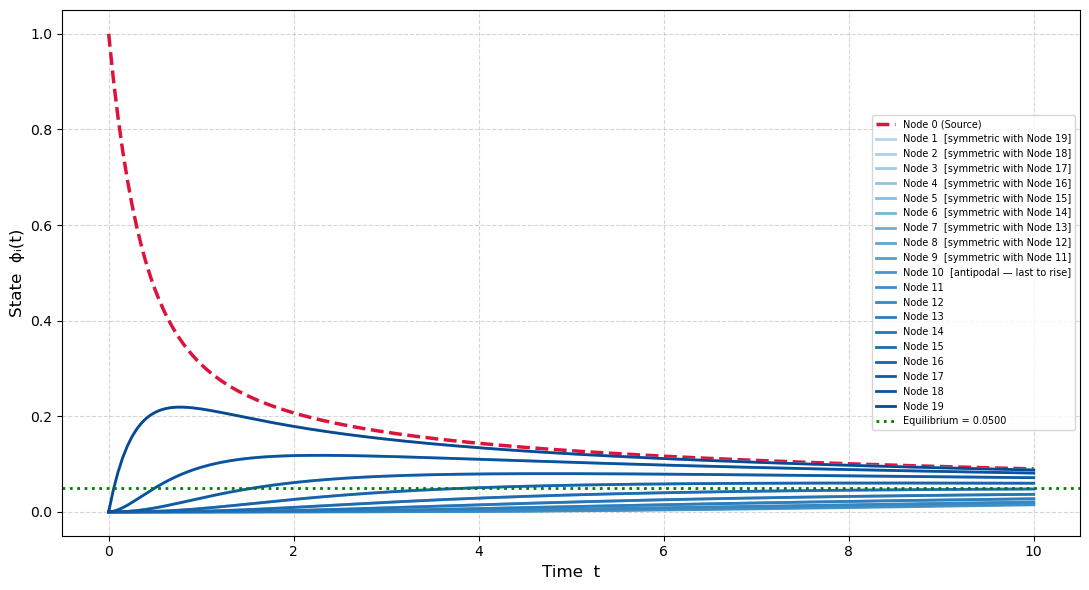

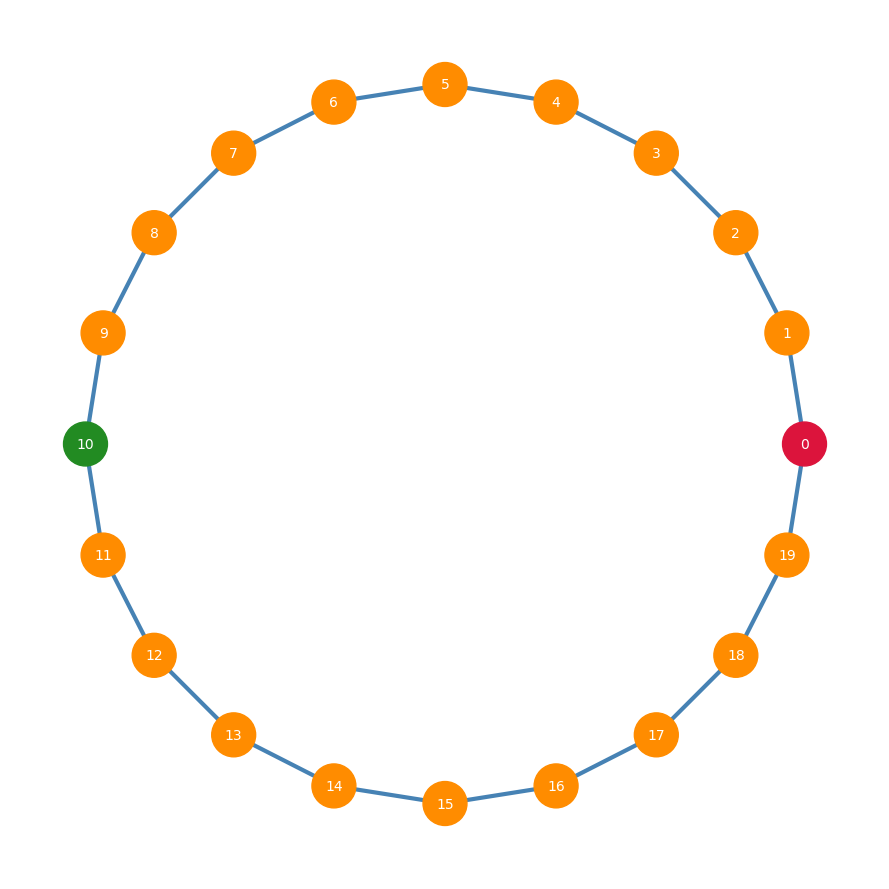


              DIFFUSION SUMMARY
Network         : Crisp Cycle C20  (20 nodes)
Source node     : Node 0,  ϕ(0) = 1.0
Diffusion const : C = 1.0
Equilibrium     : 0.0500  (= 1/n = 1/20)
Total edges     : 20  (= n for a cycle)
Regular         : Yes — every node has degree 2

Final states at t = 10:
  Node 0: ϕ(10) = 0.0898
  Node 1: ϕ(10) = 0.0875
  Node 2: ϕ(10) = 0.0811
  Node 3: ϕ(10) = 0.0714
  Node 4: ϕ(10) = 0.0598
  Node 5: ϕ(10) = 0.0478
  Node 6: ϕ(10) = 0.0366
  Node 7: ϕ(10) = 0.0273
  Node 8: ϕ(10) = 0.0203
  Node 9: ϕ(10) = 0.0160
  Node 10: ϕ(10) = 0.0146
  Node 11: ϕ(10) = 0.0160
  Node 12: ϕ(10) = 0.0203
  Node 13: ϕ(10) = 0.0273
  Node 14: ϕ(10) = 0.0366
  Node 15: ϕ(10) = 0.0478
  Node 16: ϕ(10) = 0.0598
  Node 17: ϕ(10) = 0.0714
  Node 18: ϕ(10) = 0.0811
  Node 19: ϕ(10) = 0.0875

Symmetric node pairs (same hop distance from source):
  Node 1 and Node 19  — both 1 hops from Node 0  (ϕ at t=10: 0.0875 vs 0.0875)
  Node 2 and Node 18  — both 2 hops from Node 0  (ϕ at t=10

In [30]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.linalg import expm

# ── Parameters ─────────────────────────────────────────────────────────────────
# A cycle graph C10 connects nodes in a closed ring: 0-1-2-...-9-0
# Unlike the path P10, there IS a closing edge between node 9 and node 0.
# From Definition 2.2.8: a cycle is a path with the same start and end node.
# Every node has exactly degree 2 — making C10 a 2-regular graph.
# From Definition 2.2.6: a network is k-regular if all vertices have degree k.
NUM_NODES  = 20
T_END      = 10
NUM_STEPS  = 200
C          = 1.0       # diffusion constant

# ── Step 1: Build the Crisp Cycle Graph C10 ────────────────────────────────────
# nx.cycle_graph(n) builds C_n — every node connects to exactly two neighbours,
# forming one closed ring. All edges are binary (weight = 1).

G_crisp = nx.cycle_graph(NUM_NODES)

# ── Step 2: Build Classical Matrices A, D, L ───────────────────────────────────
# A — binary adjacency matrix: Aij = 1 if edge exists, 0 otherwise
# D — degree matrix: diagonal, every entry = 2 (all nodes have degree 2)
# L — classical Laplacian: L = D - A (Section 2.3.5)
# Used in classical diffusion equation (3.2.7): dϕ/dt = -CLϕ

n     = G_crisp.number_of_nodes()
nodes = list(G_crisp.nodes())
idx   = {node: i for i, node in enumerate(nodes)}

# Binary adjacency matrix
A = np.zeros((n, n))
for u, v in G_crisp.edges():
    i, j    = idx[u], idx[v]
    A[i][j] = 1
    A[j][i] = 1              # symmetric — undirected

# Degree matrix — all diagonal entries = 2 for a cycle
D = np.diag(A.sum(axis=1))

# Classical Laplacian
L = D - A

print("=" * 55)
print("      CLASSICAL CRISP CYCLE GRAPH C20")
print("=" * 55)
print("\nAdjacency Matrix A:")
print(np.round(A, 2))
print("\nDegree Matrix D:")
print(np.round(D, 2))
print("\nLaplacian Matrix L:")
print(np.round(L, 2))

# Verify every node has degree 2
print(f"\nNode degrees (should all be 2):")
for nd in G_crisp.nodes():
    print(f"  Node {nd}: degree = {G_crisp.degree(nd)}")

# ── Step 3: Set Initial Conditions ϕ(0) ───────────────────────────────────────
# Node 0 is the single source — starts with all the substance (value = 1.0).
# All other nodes start at 0.0.
# Substance travels BOTH clockwise (0→1→2→...→9) and
# anticlockwise (0→9→8→...→1) simultaneously — two symmetric paths.
# Node 5 (antipodal — exactly 5 hops away in both directions) is last.
# From equation (3.2.8): ϕ(t) = e^{-CtL} ϕ(0)

phi0         = np.zeros(n)
phi0[idx[0]] = 1.0

equilibrium  = phi0.sum() / n    # Theorem 3.3.2: all nodes converge to 1/n

print(f"\nInitial state ϕ(0)     : {phi0}")
print(f"Theoretical equilibrium : {equilibrium:.4f}  (= 1/n = 1/{n})")

# ── Step 4: Simulate Classical Diffusion ϕ(t) = e^{-CtL} ϕ(0) ────────────────
# In a crisp cycle all edges have weight 1, so the two ring paths
# (clockwise and anticlockwise) carry substance at exactly the same rate.
# This produces a SYMMETRIC diffusion pattern:
#   Node 1 and Node 9  rise together (both 1 hop from source)
#   Node 2 and Node 8  rise together (both 2 hops from source)
#   Node 3 and Node 7  rise together (both 3 hops from source)
#   Node 4 and Node 6  rise together (both 4 hops from source)
#   Node 5             rises last    (5 hops — antipodal node)
# This symmetry collapses in the fuzzy model where µ values differ per edge.

time_steps = np.linspace(0, T_END, NUM_STEPS)
phi_t      = np.zeros((NUM_STEPS, n))

for k, t in enumerate(time_steps):
    phi_t[k] = expm(-C * t * L) @ phi0

# ── Step 5: Plot Diffusion Curves ──────────────────────────────────────────────
# Key visual: symmetric node pairs overlap perfectly in the crisp model
# because both ring paths carry identical weight.
# Node 1 = Node 9, Node 2 = Node 8, Node 3 = Node 7, Node 4 = Node 6.
# This symmetry is a fundamental limitation of the crisp cycle —
# the fuzzy cycle breaks it by assigning unique µ to each edge.

fig1, ax1 = plt.subplots(figsize=(11, 6))

# Source node
ax1.plot(time_steps, phi_t[:, idx[0]],
         label="Node 0 (Source)",
         color='crimson', linewidth=2.5, linestyle='--')

# All other nodes — symmetric pairs will visually overlap
colors = cm.Blues(np.linspace(0.3, 0.9, NUM_NODES - 1))
for i in range(1, NUM_NODES):
    # annotate symmetric pairs in the label
    if i < NUM_NODES // 2:
        pair = f"  [symmetric with Node {NUM_NODES - i}]"
    elif i == NUM_NODES // 2:
        pair = "  [antipodal — last to rise]"
    else:
        pair = ""
    ax1.plot(time_steps, phi_t[:, idx[i]],
             label=f"Node {i}{pair}",
             color=colors[i - 1], linewidth=2)

# Equilibrium line
ax1.axhline(y=equilibrium, color='green', linestyle=':', linewidth=2,
            label=f"Equilibrium = {equilibrium:.4f}")

ax1.set_xlabel("Time  t", fontsize=12)
ax1.set_ylabel("State  ϕᵢ(t)", fontsize=12)
#ax1.set_title("Diffusion on a Crisps C20 Network\n"
             # "ϕ(t) = e^{−tCL} ϕ(0)  |  Source: Node 0  |  C = 1.0",
              #fontsize=11)
ax1.legend(fontsize=7, loc='right')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("Diffusion_on_a_crisp_C20.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# ── Step 6: Visualise the Crisp Cycle Graph ────────────────────────────────────
# nx.circular_layout is the natural layout for a cycle —
# all nodes placed evenly around a circle, making the ring structure clear.
# Node 0 (source) = red, Node 5 (antipodal) = green, others = orange.
# All edges are steelblue with uniform width — reflecting equal weight (1).

pos = nx.circular_layout(G_crisp)

# Colour nodes: source = red, antipodal = green, others = orange
node_colors = []
for nd in G_crisp.nodes():
    if nd == 0:
        node_colors.append('crimson')         # source
    elif nd == NUM_NODES // 2:
        node_colors.append('forestgreen')     # antipodal node
    else:
        node_colors.append('darkorange')      # interior nodes

node_labels = {nd: f"{nd}" for nd in G_crisp.nodes()}

fig2, ax2 = plt.subplots(figsize=(9, 9))

nx.draw_networkx_nodes(G_crisp, pos,
                       node_color=node_colors,
                       node_size=1000,
                       ax=ax2)

nx.draw_networkx_edges(G_crisp, pos,
                       edge_color='steelblue',
                       width=3,
                       ax=ax2)

nx.draw_networkx_labels(G_crisp, pos,
                        labels=node_labels,
                        font_size=10,
                        font_color='white',
                        ax=ax2)


#ax2.set_title(f"Crisp  C{NUM_NODES} Network\n"
             # ,
             # fontsize=11)
ax2.axis("off")
plt.tight_layout()
plt.savefig("Crisp_C20_network.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# ── Step 7: Print Final Summary ────────────────────────────────────────────────
print(f"\n{'=' * 55}")
print(f"              DIFFUSION SUMMARY")
print(f"{'=' * 55}")
print(f"Network         : Crisp Cycle C{NUM_NODES}  ({n} nodes)")
print(f"Source node     : Node 0,  ϕ(0) = 1.0")
print(f"Diffusion const : C = {C}")
print(f"Equilibrium     : {equilibrium:.4f}  (= 1/n = 1/{n})")
print(f"Total edges     : {G_crisp.number_of_edges()}  (= n for a cycle)")
print(f"Regular         : Yes — every node has degree 2")
print(f"\nFinal states at t = {T_END}:")
for node in nodes:
    print(f"  Node {node}: ϕ({T_END}) = {phi_t[-1, idx[node]]:.4f}")
print(f"\nSymmetric node pairs (same hop distance from source):")
for i in range(1, NUM_NODES // 2):
    j = NUM_NODES - i
    print(f"  Node {i} and Node {j}  — both {i} hops from Node 0  "
          f"(ϕ at t={T_END}: {phi_t[-1, idx[i]]:.4f} vs {phi_t[-1, idx[j]]:.4f})")
print(f"  Node 5  — antipodal  — 5 hops from Node 0  "
      f"(ϕ at t={T_END}: {phi_t[-1, idx[5]]:.4f})")
print(f"\nKey Observations:")
print(f"  1. C10 HAS a closing edge (9→0) — unlike path P10")
print(f"  2. Every node has degree 2 — C10 IS 2-regular")
print(f"  3. TWO symmetric paths exist between any two nodes")
print(f"  4. Symmetric node pairs overlap perfectly in the crisp model")
print(f"     because both ring paths carry identical weight (= 1)")
print(f"  5. Node 5 (antipodal) is last — receives substance from both sides")
print(f"  6. This perfect symmetry BREAKS in the fuzzy cycle")
print(f"     where unique µ values make each path carry different substance")

## Crisps Diffusion (Hub Node) Comparison  $C_{10}$ vs $C_{20}$

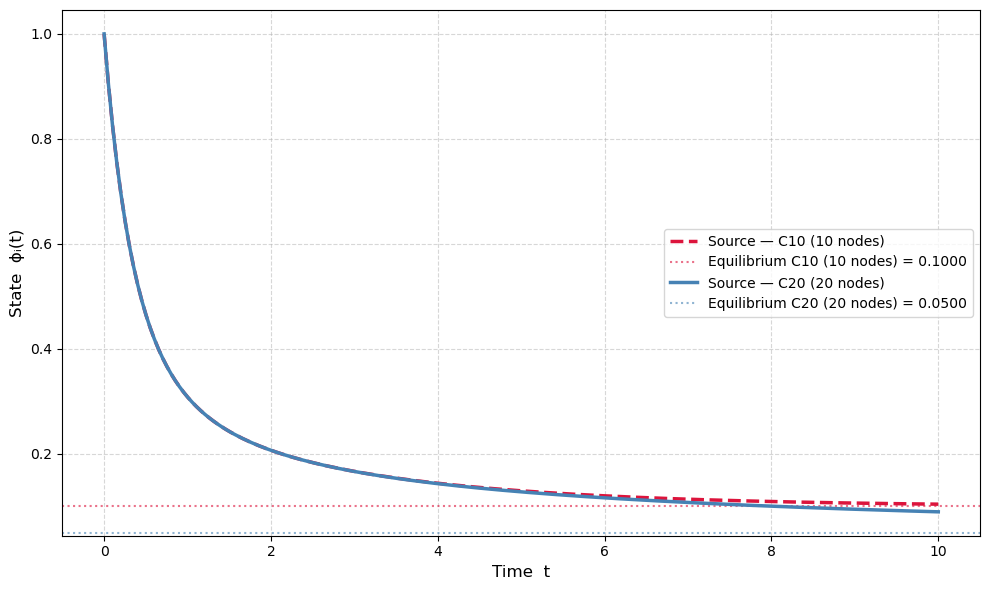

In [31]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

T_END, NUM_STEPS = 10, 200
time_steps = np.linspace(0, T_END, NUM_STEPS)
C = 1.0

configs = [
    {"NUM_NODES": 10, "color": "crimson",   "linestyle": "--", "label": "C10 (10 nodes)"},
    {"NUM_NODES": 20, "color": "steelblue", "linestyle": "-",  "label": "C20 (20 nodes)"},
]

fig, ax = plt.subplots(figsize=(10, 6))

for cfg in configs:
    NUM_NODES = cfg["NUM_NODES"]

    # Build cycle graph
    G_crisp = nx.cycle_graph(NUM_NODES)
    n       = G_crisp.number_of_nodes()
    idx     = {node: i for i, node in enumerate(G_crisp.nodes())}

    # Classical Laplacian
    A = np.zeros((n, n))
    for u, v in G_crisp.edges():
        A[idx[u]][idx[v]] = A[idx[v]][idx[u]] = 1
    L = np.diag(A.sum(axis=1)) - A

    # Initial conditions
    phi0         = np.zeros(n)
    phi0[idx[0]] = 1.0
    equilibrium  = phi0.sum() / n

    # Simulate
    phi_t = np.array([expm(-C * t * L) @ phi0 for t in time_steps])

    # Plot
    ax.plot(time_steps, phi_t[:, idx[0]],
            color=cfg["color"], linestyle=cfg["linestyle"], linewidth=2.5,
            label=f"Source — {cfg['label']}")

    ax.axhline(y=equilibrium, color=cfg["color"], linestyle=":", linewidth=1.5, alpha=0.6,
               label=f"Equilibrium {cfg['label']} = {equilibrium:.4f}")

ax.set_xlabel("Time  t", fontsize=12)
ax.set_ylabel("State  ϕᵢ(t)", fontsize=12)
#ax.set_title("Comparison of the diffusion between the hub node of a Crisps C10 vs C20\n"
            # , fontsize=11)
ax.legend(fontsize=10, loc='right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("Diffusion_Comparison_Crisps_C10_vs_C20.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

## Diffusion on crisps and fuzzy $C_{10}$ network in one plot

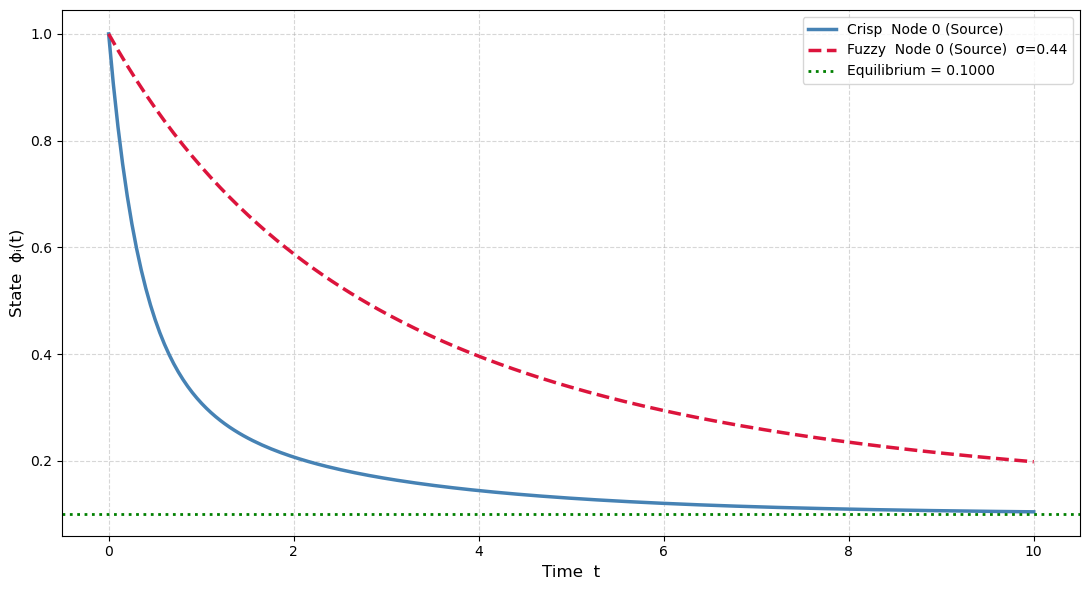

In [32]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

NUM_NODES  = 10
T_END      = 10
NUM_STEPS  = 200
C          = 1.0
time_steps = np.linspace(0, T_END, NUM_STEPS)

# ── Fuzzy Cycle ────────────────────────────────────────────────────────────────
G = nx.Graph()
np.random.seed(42)
for node in range(NUM_NODES):
    sigma = round(np.random.uniform(0.1, 1.0), 2)
    G.add_node(node, sigma=sigma)

for u, v in [(i, (i + 1) % NUM_NODES) for i in range(NUM_NODES)]:
    mu = round(np.random.uniform(0.1, min(G.nodes[u]['sigma'], G.nodes[v]['sigma'])), 2)
    G.add_edge(u, v, mu=mu)

n_f   = G.number_of_nodes()
idx_f = {node: i for i, node in enumerate(G.nodes())}

Af = np.zeros((n_f, n_f))
for u, v, data in G.edges(data=True):
    Af[idx_f[u]][idx_f[v]] = data['mu']
    Af[idx_f[v]][idx_f[u]] = data['mu']

Lf = np.diag(Af.sum(axis=1)) - Af

phi0_f           = np.zeros(n_f)
phi0_f[idx_f[0]] = 1.0
equilibrium_f    = phi0_f.sum() / n_f

phi_t_f = np.zeros((NUM_STEPS, n_f))
for k, t in enumerate(time_steps):
    phi_t_f[k] = expm(-t * Lf) @ phi0_f

# ── Crisp Cycle ────────────────────────────────────────────────────────────────
G_crisp = nx.cycle_graph(NUM_NODES)
n_c     = G_crisp.number_of_nodes()
idx_c   = {node: i for i, node in enumerate(G_crisp.nodes())}

A = np.zeros((n_c, n_c))
for u, v in G_crisp.edges():
    A[idx_c[u]][idx_c[v]] = 1
    A[idx_c[v]][idx_c[u]] = 1

L = np.diag(A.sum(axis=1)) - A

phi0_c           = np.zeros(n_c)
phi0_c[idx_c[0]] = 1.0
equilibrium_c    = phi0_c.sum() / n_c

phi_t_c = np.zeros((NUM_STEPS, n_c))
for k, t in enumerate(time_steps):
    phi_t_c[k] = expm(-C * t * L) @ phi0_c

# ── Combined Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(time_steps, phi_t_c[:, idx_c[0]],
        label="Crisp  Node 0 (Source)",
        color='steelblue', linewidth=2.5, linestyle='-')

ax.plot(time_steps, phi_t_f[:, idx_f[0]],
        label=f"Fuzzy  Node 0 (Source)  σ={G.nodes[0]['sigma']}",
        color='crimson', linewidth=2.5, linestyle='--')

ax.axhline(y=equilibrium_c, color='green', linestyle=':', linewidth=2,
           label=f"Equilibrium = {equilibrium_c:.4f}")

ax.set_xlabel("Time  t", fontsize=12)
ax.set_ylabel("State  ϕᵢ(t)", fontsize=12)
#ax.set_title("Comparison of the diffusion between the hub node of the fuzzy and Crisp C10\n"
            # , fontsize=11)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("fuzzy_vs_crisp_Diffusion_C10.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

## Diffusion on crisps and fuzzy $C_{20}$ network in one plot

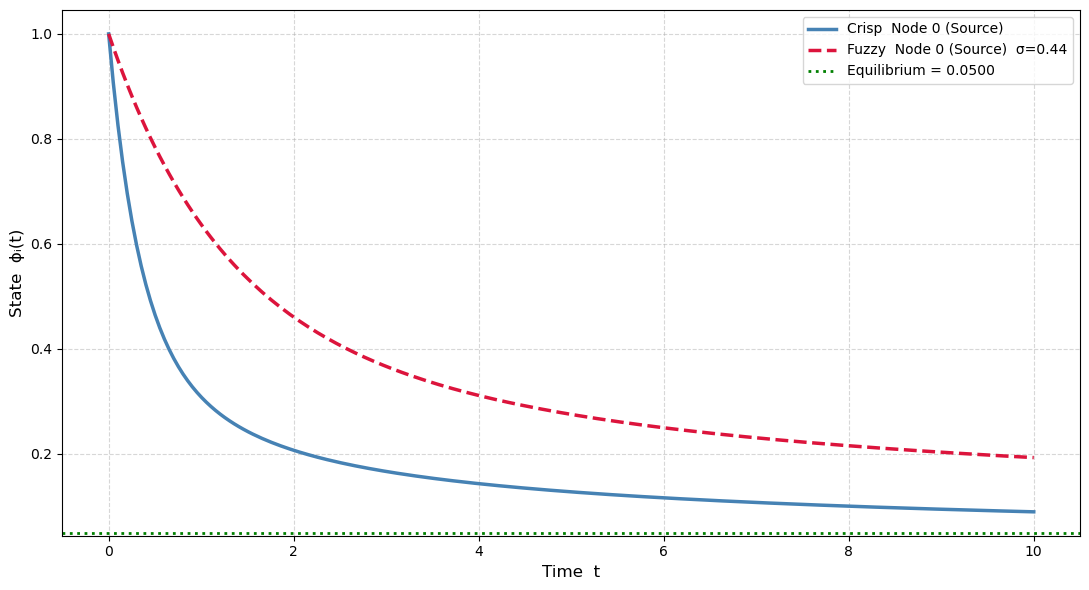

In [33]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

NUM_NODES  = 20
T_END      = 10
NUM_STEPS  = 200
C          = 1.0
time_steps = np.linspace(0, T_END, NUM_STEPS)

# ── Fuzzy Cycle ────────────────────────────────────────────────────────────────
G = nx.Graph()
np.random.seed(42)
for node in range(NUM_NODES):
    sigma = round(np.random.uniform(0.1, 1.0), 2)
    G.add_node(node, sigma=sigma)

for u, v in [(i, (i + 1) % NUM_NODES) for i in range(NUM_NODES)]:
    mu = round(np.random.uniform(0.1, min(G.nodes[u]['sigma'], G.nodes[v]['sigma'])), 2)
    G.add_edge(u, v, mu=mu)

n_f   = G.number_of_nodes()
idx_f = {node: i for i, node in enumerate(G.nodes())}

Af = np.zeros((n_f, n_f))
for u, v, data in G.edges(data=True):
    Af[idx_f[u]][idx_f[v]] = data['mu']
    Af[idx_f[v]][idx_f[u]] = data['mu']

Lf = np.diag(Af.sum(axis=1)) - Af

phi0_f           = np.zeros(n_f)
phi0_f[idx_f[0]] = 1.0
equilibrium_f    = phi0_f.sum() / n_f

phi_t_f = np.zeros((NUM_STEPS, n_f))
for k, t in enumerate(time_steps):
    phi_t_f[k] = expm(-t * Lf) @ phi0_f

# ── Crisp Cycle ────────────────────────────────────────────────────────────────
G_crisp = nx.cycle_graph(NUM_NODES)
n_c     = G_crisp.number_of_nodes()
idx_c   = {node: i for i, node in enumerate(G_crisp.nodes())}

A = np.zeros((n_c, n_c))
for u, v in G_crisp.edges():
    A[idx_c[u]][idx_c[v]] = 1
    A[idx_c[v]][idx_c[u]] = 1

L = np.diag(A.sum(axis=1)) - A

phi0_c           = np.zeros(n_c)
phi0_c[idx_c[0]] = 1.0
equilibrium_c    = phi0_c.sum() / n_c

phi_t_c = np.zeros((NUM_STEPS, n_c))
for k, t in enumerate(time_steps):
    phi_t_c[k] = expm(-C * t * L) @ phi0_c

# ── Combined Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(time_steps, phi_t_c[:, idx_c[0]],
        label="Crisp  Node 0 (Source)",
        color='steelblue', linewidth=2.5, linestyle='-')

ax.plot(time_steps, phi_t_f[:, idx_f[0]],
        label=f"Fuzzy  Node 0 (Source)  σ={G.nodes[0]['sigma']}",
        color='crimson', linewidth=2.5, linestyle='--')

ax.axhline(y=equilibrium_c, color='green', linestyle=':', linewidth=2,
           label=f"Equilibrium = {equilibrium_c:.4f}")

ax.set_xlabel("Time  t", fontsize=12)
ax.set_ylabel("State  ϕᵢ(t)", fontsize=12)
#ax.set_title("Comparison of the diffusion between the hub node of the fuzzy and Crisp C20\n"
            # , fontsize=11)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("fuzzy_vs_crisp_diffusion_C20.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# 4. PATH $P_{10}$ #
## Diffusion on a Crisps $P_{10}$

      CLASSICAL CRISP PATH GRAPH P10

Adjacency Matrix A:
[[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]]

Degree Matrix D:
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 2. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 2. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 2. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 2. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 2. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 2. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 2. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 2. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]

Laplacian Matrix L:
[[ 1. -1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [-1.  2. -1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  2. -1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -1.  2. -1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -1.  2. -1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -1.  2. 

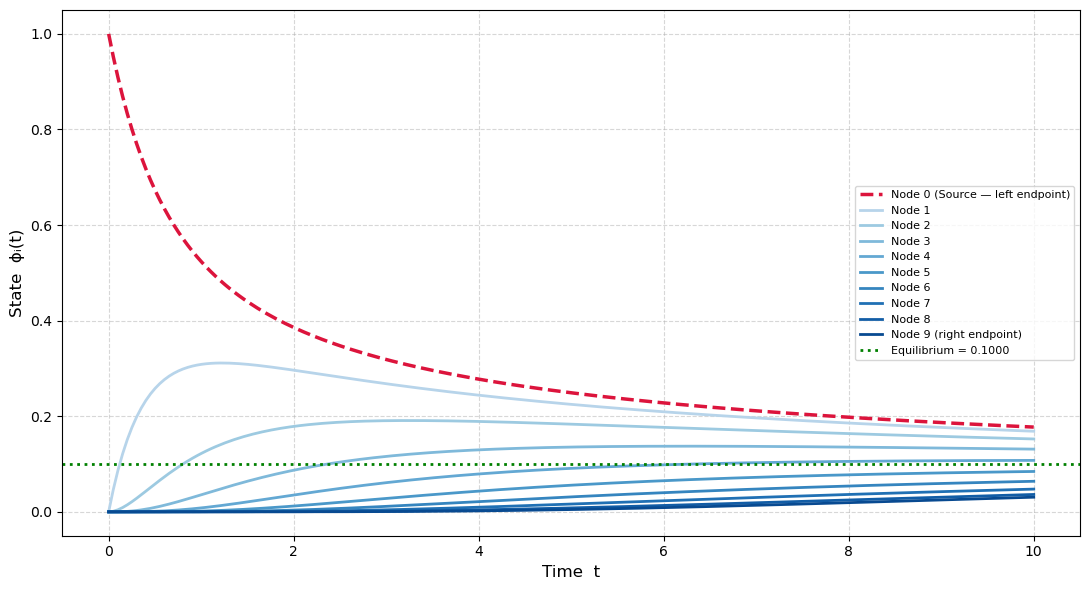

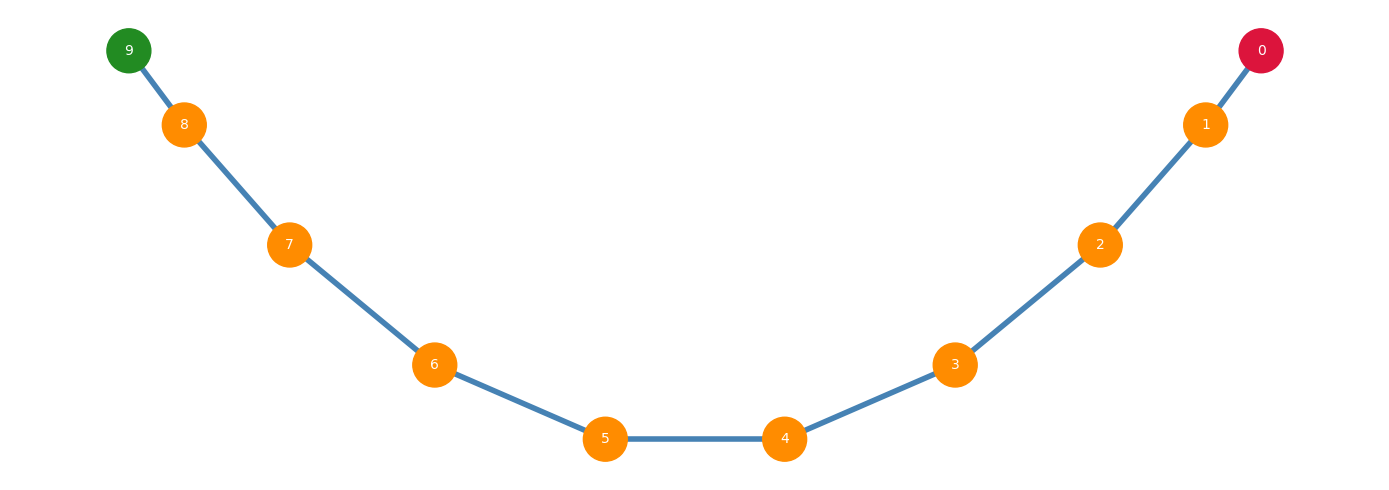


              DIFFUSION SUMMARY
Network         : Crisp Path P10  (10 nodes)
Source node     : Node 0  (left endpoint),  ϕ(0) = 1.0
Diffusion const : C = 1.0
Equilibrium     : 0.1000  (= 1/n = 1/10)
Total edges     : 9  (= n-1 for a path)

Final states at t = 10:
  Node 0: ϕ(10) = 0.1773
  Node 1: ϕ(10) = 0.1686
  Node 2: ϕ(10) = 0.1524
  Node 3: ϕ(10) = 0.1312
  Node 4: ϕ(10) = 0.1076
  Node 5: ϕ(10) = 0.0844
  Node 6: ϕ(10) = 0.0639
  Node 7: ϕ(10) = 0.0476
  Node 8: ϕ(10) = 0.0363
  Node 9: ϕ(10) = 0.0306

Key Observations:
  1. P10 has NO closing edge — unlike cycle C10
  2. Endpoint nodes (0 and 9) have degree 1 — P10 is NOT regular
  3. Only ONE path exists between any two nodes — no alternative routes
  4. Diffusion is strictly sequential: 0 → 1 → 2 → ... → 9
  5. Node 9 is always last to reach equilibrium
  6. All non-source node curves are uniformly spaced in the crisp model
     because all edge weights = 1 — no bottlenecks, no variation
  7. This is the slowest topology stu

In [34]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.linalg import expm

# ── Parameters ─────────────────────────────────────────────────────────────────
# A path graph P10 connects nodes in a straight line: 0-1-2-3-4-5-6-7-8-9
# Unlike a star, there is no central hub — nodes are connected sequentially.
# Unlike a cycle, there is no closing edge between node 9 and node 0.
# From Definition 2.2.8: a path is a trail where all vertices are distinct.
# Node degrees: endpoints (0 and 9) have degree 1, interior nodes have degree 2.
# This makes P10 non-regular — unlike the cycle C10.
NUM_NODES  = 10
T_END      = 10
NUM_STEPS  = 200
C          = 1.0       # diffusion constant

# ── Step 1: Build the Crisp Path Graph P10 ─────────────────────────────────────
# nx.path_graph(n) builds a path P_n — nodes connected in a straight line.
# All edges are binary (weight = 1) as per classical network definition.
# Node 0 is the source (left endpoint); node 9 is the far endpoint.

G_crisp = nx.path_graph(NUM_NODES)

# ── Step 2: Build Classical Matrices A, D, L ───────────────────────────────────
# A — binary adjacency matrix: Aij = 1 if edge exists, 0 otherwise
# D — degree matrix: diagonal matrix of node degrees
#     endpoints have degree 1; interior nodes have degree 2
# L — classical Laplacian: L = D - A (Section 2.3.5)
# Used in classical diffusion equation (3.2.7): dϕ/dt = -CLϕ

n     = G_crisp.number_of_nodes()
nodes = list(G_crisp.nodes())
idx   = {node: i for i, node in enumerate(nodes)}

# Binary adjacency matrix
A = np.zeros((n, n))
for u, v in G_crisp.edges():
    i, j    = idx[u], idx[v]
    A[i][j] = 1
    A[j][i] = 1              # symmetric — undirected

# Degree matrix
D = np.diag(A.sum(axis=1))

# Classical Laplacian
L = D - A

print("=" * 55)
print("      CLASSICAL CRISP PATH GRAPH P10")
print("=" * 55)
print("\nAdjacency Matrix A:")
print(np.round(A, 2))
print("\nDegree Matrix D:")
print(np.round(D, 2))
print("\nLaplacian Matrix L:")
print(np.round(L, 2))

# Verify node degrees
print(f"\nNode degrees:")
for nd in G_crisp.nodes():
    deg  = G_crisp.degree(nd)
    role = "endpoint (pendant)" if deg == 1 else "interior"
    print(f"  Node {nd}: degree = {deg}  ({role})")

# ── Step 3: Set Initial Conditions ϕ(0) ───────────────────────────────────────
# Node 0 is the source — the left endpoint of the path.
# Substance must travel strictly left to right along the line.
# There is ONLY ONE path from node 0 to any other node —
# no alternative routes, no shortcuts.
# Node 9 (right endpoint) is always the last to receive substance.
# From equation (3.2.8): ϕ(t) = e^{-CtL} ϕ(0)

phi0         = np.zeros(n)
phi0[idx[0]] = 1.0

equilibrium  = phi0.sum() / n    # Theorem 3.3.2: all nodes converge to 1/n

print(f"\nInitial state ϕ(0)     : {phi0}")
print(f"Theoretical equilibrium : {equilibrium:.4f}  (= 1/n = 1/{n})")

# ── Step 4: Simulate Classical Diffusion ϕ(t) = e^{-CtL} ϕ(0) ────────────────
# In a crisp path, all edges have weight 1 so substance travels uniformly
# from left to right. The sequential nature of the path means diffusion
# is the slowest of all topologies — each node must wait for its predecessor.
# In the crisp model all nodes at the same hop-distance from the source
# behave identically — unlike the fuzzy path where µ values create variation.

time_steps = np.linspace(0, T_END, NUM_STEPS)
phi_t      = np.zeros((NUM_STEPS, n))

for k, t in enumerate(time_steps):
    phi_t[k] = expm(-C * t * L) @ phi0

# ── Step 5: Plot Diffusion Curves ──────────────────────────────────────────────
# Expected behaviour:
#   - Node 0 (source) decays from 1.0
#   - Nodes rise in order: node 1 first, node 9 last
#   - Each node's rise is delayed relative to the previous node
#   - In the crisp model the delay between consecutive nodes is uniform
#     because all edge weights are identical (= 1)
#   - All nodes converge to equilibrium = 1/n = 0.1

fig1, ax1 = plt.subplots(figsize=(11, 6))

# Source node — left endpoint
ax1.plot(time_steps, phi_t[:, idx[0]],
         label="Node 0 (Source — left endpoint)",
         color='crimson', linewidth=2.5, linestyle='--')

# Interior and far endpoint nodes
colors = cm.Blues(np.linspace(0.3, 0.9, NUM_NODES - 1))
for i in range(1, NUM_NODES):
    role = "(right endpoint)" if i == NUM_NODES - 1 else ""
    ax1.plot(time_steps, phi_t[:, idx[i]],
             label=f"Node {i} {role}",
             color=colors[i - 1], linewidth=2)

# Equilibrium line
ax1.axhline(y=equilibrium, color='green', linestyle=':', linewidth=2,
            label=f"Equilibrium = {equilibrium:.4f}")

ax1.set_xlabel("Time  t", fontsize=12)
ax1.set_ylabel("State  ϕᵢ(t)", fontsize=12)
#ax1.set_title("Diffusion on a  Crisps P10 Network\n"
             # "ϕ(t) = e^{−tCL} ϕ(0)  |  Source: Node 0  |  C = 1.0",
             # fontsize=11)
ax1.legend(fontsize=8, loc='right')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("Diffusion_on_Crisps_p10.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# ── Step 6: Visualise the Crisp Path Graph ─────────────────────────────────────
# nx.spectral_layout naturally arranges path nodes in a straight line —
# the best layout to clearly show the sequential structure of P10.
# Node 0 (source) is highlighted in red.
# Node 9 (far endpoint) is highlighted in green.
# All interior nodes are orange.
# All edges have the same weight (1) — shown uniformly in steelblue.

pos = nx.spectral_layout(G_crisp)

# Colour nodes: source = red, far endpoint = green, interior = orange
node_colors = []
for nd in G_crisp.nodes():
    if nd == 0:
        node_colors.append('crimson')        # source
    elif nd == NUM_NODES - 1:
        node_colors.append('forestgreen')    # far endpoint
    else:
        node_colors.append('darkorange')     # interior

node_labels = {nd: f"{nd}" for nd in G_crisp.nodes()}

fig2, ax2 = plt.subplots(figsize=(14, 5))

nx.draw_networkx_nodes(G_crisp, pos,
                       node_color=node_colors,
                       node_size=1000,
                       ax=ax2)

nx.draw_networkx_edges(G_crisp, pos,
                       edge_color='steelblue',
                       width=4,
                       ax=ax2)

nx.draw_networkx_labels(G_crisp, pos,
                        labels=node_labels,
                        font_size=10,
                        font_color='white',
                        ax=ax2)


#ax2.set_title(f"Crisp P{NUM_NODES} Network\n"
             # ,
             # fontsize=11)
ax2.axis("off")
plt.tight_layout()
plt.savefig("crisp_P10_network.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# ── Step 7: Print Final Summary ────────────────────────────────────────────────
print(f"\n{'=' * 55}")
print(f"              DIFFUSION SUMMARY")
print(f"{'=' * 55}")
print(f"Network         : Crisp Path P{NUM_NODES}  ({n} nodes)")
print(f"Source node     : Node 0  (left endpoint),  ϕ(0) = 1.0")
print(f"Diffusion const : C = {C}")
print(f"Equilibrium     : {equilibrium:.4f}  (= 1/n = 1/{n})")
print(f"Total edges     : {G_crisp.number_of_edges()}  (= n-1 for a path)")
print(f"\nFinal states at t = {T_END}:")
for node in nodes:
    print(f"  Node {node}: ϕ({T_END}) = {phi_t[-1, idx[node]]:.4f}")
print(f"\nKey Observations:")
print(f"  1. P10 has NO closing edge — unlike cycle C10")
print(f"  2. Endpoint nodes (0 and 9) have degree 1 — P10 is NOT regular")
print(f"  3. Only ONE path exists between any two nodes — no alternative routes")
print(f"  4. Diffusion is strictly sequential: 0 → 1 → 2 → ... → 9")
print(f"  5. Node 9 is always last to reach equilibrium")
print(f"  6. All non-source node curves are uniformly spaced in the crisp model")
print(f"     because all edge weights = 1 — no bottlenecks, no variation")
print(f"  7. This is the slowest topology studied — compare with K10 (fastest)")

## Diffusion on a Crisps $P_{20}$

      CLASSICAL CRISP PATH GRAPH P20

Adjacency Matrix A:
[[0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0

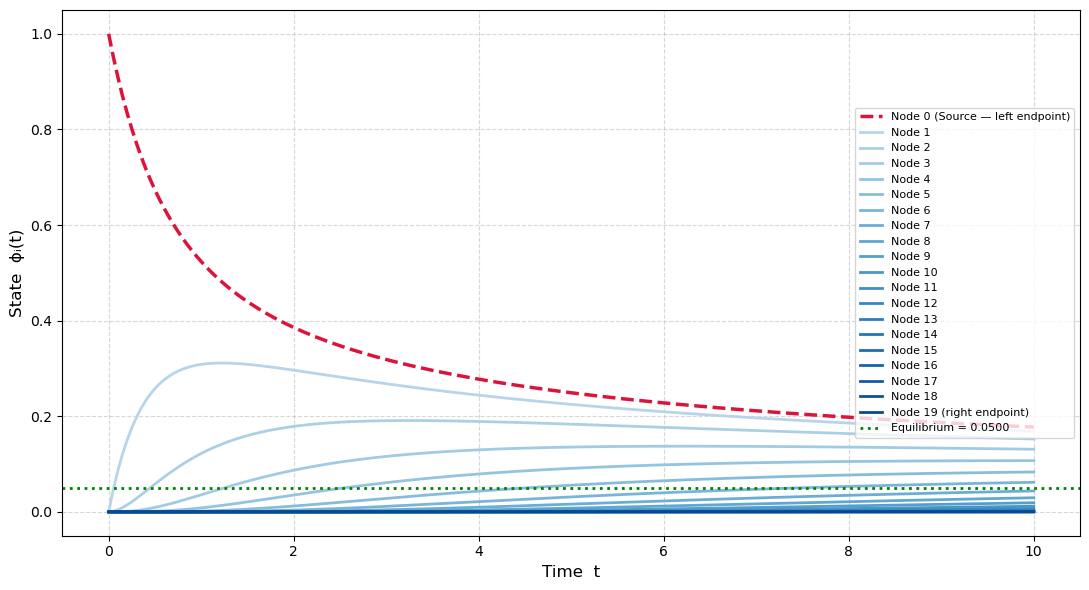

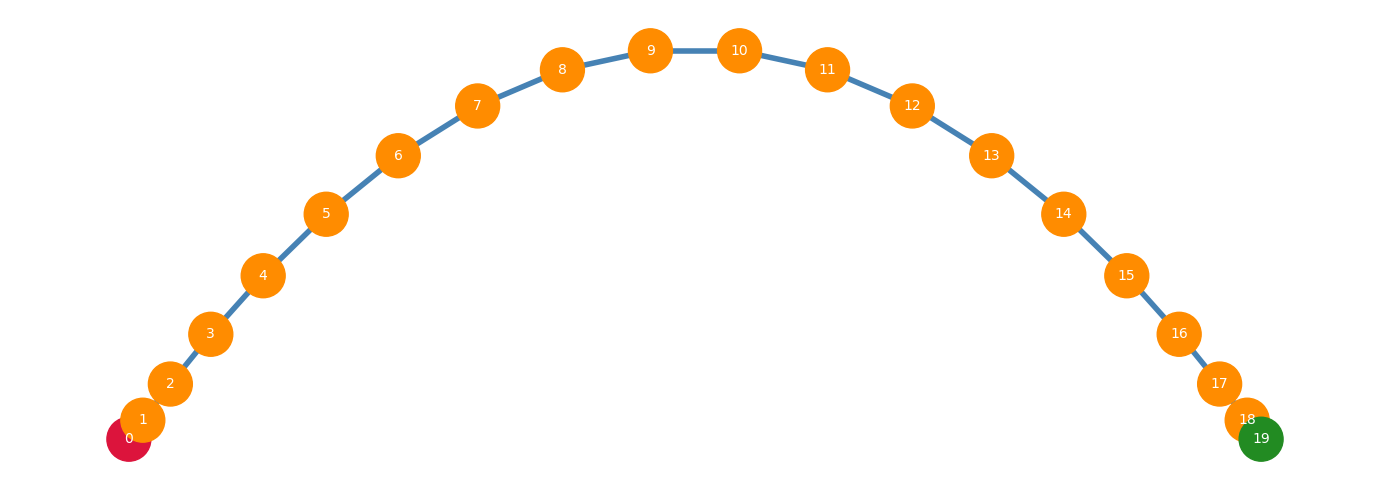


              DIFFUSION SUMMARY
Network         : Crisp Path P20  (20 nodes)
Source node     : Node 0  (left endpoint),  ϕ(0) = 1.0
Diffusion const : C = 1.0
Equilibrium     : 0.0500  (= 1/n = 1/20)
Total edges     : 19  (= n-1 for a path)

Final states at t = 10:
  Node 0: ϕ(10) = 0.1773
  Node 1: ϕ(10) = 0.1685
  Node 2: ϕ(10) = 0.1523
  Node 3: ϕ(10) = 0.1309
  Node 4: ϕ(10) = 0.1071
  Node 5: ϕ(10) = 0.0834
  Node 6: ϕ(10) = 0.0618
  Node 7: ϕ(10) = 0.0437
  Node 8: ϕ(10) = 0.0295
  Node 9: ϕ(10) = 0.0190
  Node 10: ϕ(10) = 0.0117
  Node 11: ϕ(10) = 0.0069
  Node 12: ϕ(10) = 0.0039
  Node 13: ϕ(10) = 0.0021
  Node 14: ϕ(10) = 0.0011
  Node 15: ϕ(10) = 0.0005
  Node 16: ϕ(10) = 0.0003
  Node 17: ϕ(10) = 0.0001
  Node 18: ϕ(10) = 0.0001
  Node 19: ϕ(10) = 0.0000

Key Observations:
  1. P10 has NO closing edge — unlike cycle C10
  2. Endpoint nodes (0 and 9) have degree 1 — P10 is NOT regular
  3. Only ONE path exists between any two nodes — no alternative routes
  4. Diffusion is st

In [35]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.linalg import expm

# ── Parameters ─────────────────────────────────────────────────────────────────
# A path graph P10 connects nodes in a straight line: 0-1-2-3-4-5-6-7-8-9
# Unlike a star, there is no central hub — nodes are connected sequentially.
# Unlike a cycle, there is no closing edge between node 9 and node 0.
# From Definition 2.2.8: a path is a trail where all vertices are distinct.
# Node degrees: endpoints (0 and 9) have degree 1, interior nodes have degree 2.
# This makes P10 non-regular — unlike the cycle C10.
NUM_NODES  = 20
T_END      = 10
NUM_STEPS  = 200
C          = 1.0       # diffusion constant

# ── Step 1: Build the Crisp Path Graph P10 ─────────────────────────────────────
# nx.path_graph(n) builds a path P_n — nodes connected in a straight line.
# All edges are binary (weight = 1) as per classical network definition.
# Node 0 is the source (left endpoint); node 9 is the far endpoint.

G_crisp = nx.path_graph(NUM_NODES)

# ── Step 2: Build Classical Matrices A, D, L ───────────────────────────────────
# A — binary adjacency matrix: Aij = 1 if edge exists, 0 otherwise
# D — degree matrix: diagonal matrix of node degrees
#     endpoints have degree 1; interior nodes have degree 2
# L — classical Laplacian: L = D - A (Section 2.3.5)
# Used in classical diffusion equation (3.2.7): dϕ/dt = -CLϕ

n     = G_crisp.number_of_nodes()
nodes = list(G_crisp.nodes())
idx   = {node: i for i, node in enumerate(nodes)}

# Binary adjacency matrix
A = np.zeros((n, n))
for u, v in G_crisp.edges():
    i, j    = idx[u], idx[v]
    A[i][j] = 1
    A[j][i] = 1              # symmetric — undirected

# Degree matrix
D = np.diag(A.sum(axis=1))

# Classical Laplacian
L = D - A

print("=" * 55)
print("      CLASSICAL CRISP PATH GRAPH P20")
print("=" * 55)
print("\nAdjacency Matrix A:")
print(np.round(A, 2))
print("\nDegree Matrix D:")
print(np.round(D, 2))
print("\nLaplacian Matrix L:")
print(np.round(L, 2))

# Verify node degrees
print(f"\nNode degrees:")
for nd in G_crisp.nodes():
    deg  = G_crisp.degree(nd)
    role = "endpoint (pendant)" if deg == 1 else "interior"
    print(f"  Node {nd}: degree = {deg}  ({role})")

# ── Step 3: Set Initial Conditions ϕ(0) ───────────────────────────────────────
# Node 0 is the source — the left endpoint of the path.
# Substance must travel strictly left to right along the line.
# There is ONLY ONE path from node 0 to any other node —
# no alternative routes, no shortcuts.
# Node 9 (right endpoint) is always the last to receive substance.
# From equation (3.2.8): ϕ(t) = e^{-CtL} ϕ(0)

phi0         = np.zeros(n)
phi0[idx[0]] = 1.0

equilibrium  = phi0.sum() / n    # Theorem 3.3.2: all nodes converge to 1/n

print(f"\nInitial state ϕ(0)     : {phi0}")
print(f"Theoretical equilibrium : {equilibrium:.4f}  (= 1/n = 1/{n})")

# ── Step 4: Simulate Classical Diffusion ϕ(t) = e^{-CtL} ϕ(0) ────────────────
# In a crisp path, all edges have weight 1 so substance travels uniformly
# from left to right. The sequential nature of the path means diffusion
# is the slowest of all topologies — each node must wait for its predecessor.
# In the crisp model all nodes at the same hop-distance from the source
# behave identically — unlike the fuzzy path where µ values create variation.

time_steps = np.linspace(0, T_END, NUM_STEPS)
phi_t      = np.zeros((NUM_STEPS, n))

for k, t in enumerate(time_steps):
    phi_t[k] = expm(-C * t * L) @ phi0

# ── Step 5: Plot Diffusion Curves ──────────────────────────────────────────────
# Expected behaviour:
#   - Node 0 (source) decays from 1.0
#   - Nodes rise in order: node 1 first, node 9 last
#   - Each node's rise is delayed relative to the previous node
#   - In the crisp model the delay between consecutive nodes is uniform
#     because all edge weights are identical (= 1)
#   - All nodes converge to equilibrium = 1/n = 0.1

fig1, ax1 = plt.subplots(figsize=(11, 6))

# Source node — left endpoint
ax1.plot(time_steps, phi_t[:, idx[0]],
         label="Node 0 (Source — left endpoint)",
         color='crimson', linewidth=2.5, linestyle='--')

# Interior and far endpoint nodes
colors = cm.Blues(np.linspace(0.3, 0.9, NUM_NODES - 1))
for i in range(1, NUM_NODES):
    role = "(right endpoint)" if i == NUM_NODES - 1 else ""
    ax1.plot(time_steps, phi_t[:, idx[i]],
             label=f"Node {i} {role}",
             color=colors[i - 1], linewidth=2)

# Equilibrium line
ax1.axhline(y=equilibrium, color='green', linestyle=':', linewidth=2,
            label=f"Equilibrium = {equilibrium:.4f}")

ax1.set_xlabel("Time  t", fontsize=12)
ax1.set_ylabel("State  ϕᵢ(t)", fontsize=12)
#ax1.set_title("Diffusion on a Crisps P20 Network\n"
              #"ϕ(t) = e^{−tCL} ϕ(0)  |  Source: Node 0  |  C = 1.0",
              #fontsize=11)
ax1.legend(fontsize=8, loc='right')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("Diffusion_on_Crisps_P20.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# ── Step 6: Visualise the Crisp Path Graph ─────────────────────────────────────
# nx.spectral_layout naturally arranges path nodes in a straight line —
# the best layout to clearly show the sequential structure of P10.
# Node 0 (source) is highlighted in red.
# Node 9 (far endpoint) is highlighted in green.
# All interior nodes are orange.
# All edges have the same weight (1) — shown uniformly in steelblue.

pos = nx.spectral_layout(G_crisp)

# Colour nodes: source = red, far endpoint = green, interior = orange
node_colors = []
for nd in G_crisp.nodes():
    if nd == 0:
        node_colors.append('crimson')        # source
    elif nd == NUM_NODES - 1:
        node_colors.append('forestgreen')    # far endpoint
    else:
        node_colors.append('darkorange')     # interior

node_labels = {nd: f"{nd}" for nd in G_crisp.nodes()}

fig2, ax2 = plt.subplots(figsize=(14, 5))

nx.draw_networkx_nodes(G_crisp, pos,
                       node_color=node_colors,
                       node_size=1000,
                       ax=ax2)

nx.draw_networkx_edges(G_crisp, pos,
                       edge_color='steelblue',
                       width=4,
                       ax=ax2)

nx.draw_networkx_labels(G_crisp, pos,
                        labels=node_labels,
                        font_size=10,
                        font_color='white',
                        ax=ax2)


#ax2.set_title(f"Crisp P{NUM_NODES} Network\n"
             # ,
             # fontsize=11)
ax2.axis("off")
plt.tight_layout()
plt.savefig("crisp_P20_network.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# ── Step 7: Print Final Summary ────────────────────────────────────────────────
print(f"\n{'=' * 55}")
print(f"              DIFFUSION SUMMARY")
print(f"{'=' * 55}")
print(f"Network         : Crisp Path P{NUM_NODES}  ({n} nodes)")
print(f"Source node     : Node 0  (left endpoint),  ϕ(0) = 1.0")
print(f"Diffusion const : C = {C}")
print(f"Equilibrium     : {equilibrium:.4f}  (= 1/n = 1/{n})")
print(f"Total edges     : {G_crisp.number_of_edges()}  (= n-1 for a path)")
print(f"\nFinal states at t = {T_END}:")
for node in nodes:
    print(f"  Node {node}: ϕ({T_END}) = {phi_t[-1, idx[node]]:.4f}")
print(f"\nKey Observations:")
print(f"  1. P10 has NO closing edge — unlike cycle C10")
print(f"  2. Endpoint nodes (0 and 9) have degree 1 — P10 is NOT regular")
print(f"  3. Only ONE path exists between any two nodes — no alternative routes")
print(f"  4. Diffusion is strictly sequential: 0 → 1 → 2 → ... → 9")
print(f"  5. Node 9 is always last to reach equilibrium")
print(f"  6. All non-source node curves are uniformly spaced in the crisp model")
print(f"     because all edge weights = 1 — no bottlenecks, no variation")
print(f"  7. This is the slowest topology studied — compare with K10 (fastest)")

## Crisps Diffusion (Hub Node) Comparison  $P_{10}$ vs $P_{20}$

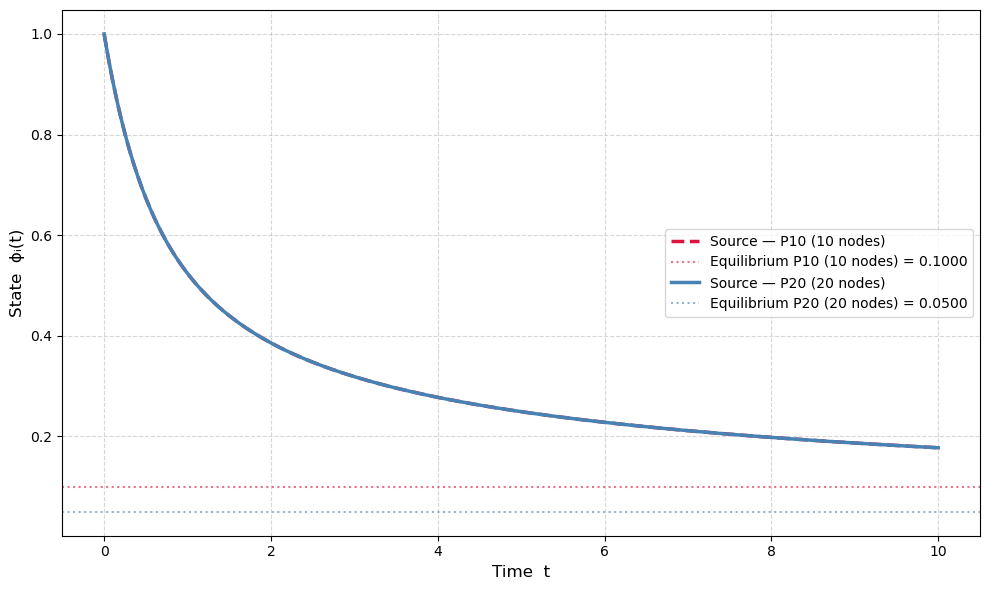

In [36]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

T_END, NUM_STEPS = 10, 200
time_steps = np.linspace(0, T_END, NUM_STEPS)
C = 1.0

configs = [
    {"NUM_NODES": 10, "color": "crimson",   "linestyle": "--", "label": "P10 (10 nodes)"},
    {"NUM_NODES": 20, "color": "steelblue", "linestyle": "-",  "label": "P20 (20 nodes)"},
]

fig, ax = plt.subplots(figsize=(10, 6))

for cfg in configs:
    NUM_NODES = cfg["NUM_NODES"]

    # Build path graph
    G_crisp = nx.path_graph(NUM_NODES)
    n       = G_crisp.number_of_nodes()
    idx     = {node: i for i, node in enumerate(G_crisp.nodes())}

    # Classical Laplacian
    A = np.zeros((n, n))
    for u, v in G_crisp.edges():
        A[idx[u]][idx[v]] = A[idx[v]][idx[u]] = 1
    L = np.diag(A.sum(axis=1)) - A

    # Initial conditions
    phi0         = np.zeros(n)
    phi0[idx[0]] = 1.0
    equilibrium  = phi0.sum() / n

    # Simulate
    phi_t = np.array([expm(-C * t * L) @ phi0 for t in time_steps])

    # Plot
    ax.plot(time_steps, phi_t[:, idx[0]],
            color=cfg["color"], linestyle=cfg["linestyle"], linewidth=2.5,
            label=f"Source — {cfg['label']}")

    ax.axhline(y=equilibrium, color=cfg["color"], linestyle=":", linewidth=1.5, alpha=0.6,
               label=f"Equilibrium {cfg['label']} = {equilibrium:.4f}")

ax.set_xlabel("Time  t", fontsize=12)
ax.set_ylabel("State  ϕᵢ(t)", fontsize=12)
#ax.set_title("Comparison of the diffusion between the hub node of a Crisps P10 vs P20\n"
           # , fontsize=11)
ax.legend(fontsize=10, loc='right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("Diffusion_Comparison_crisps_P10_vs_P20.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

## Diffusion on a Fuzzy $P_{10}$


Fuzzy Adjacency Matrix Af:
[[0.   0.11 0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.11 0.   0.74 0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.74 0.   0.55 0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.55 0.   0.13 0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.13 0.   0.13 0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.13 0.   0.11 0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.11 0.   0.12 0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.12 0.   0.38 0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.38 0.   0.33]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.33 0.  ]]

Fuzzy Degree Matrix Df:
[[0.11 0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.85 0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   1.29 0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.68 0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.26 0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.24 0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.23 0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.5  0. 

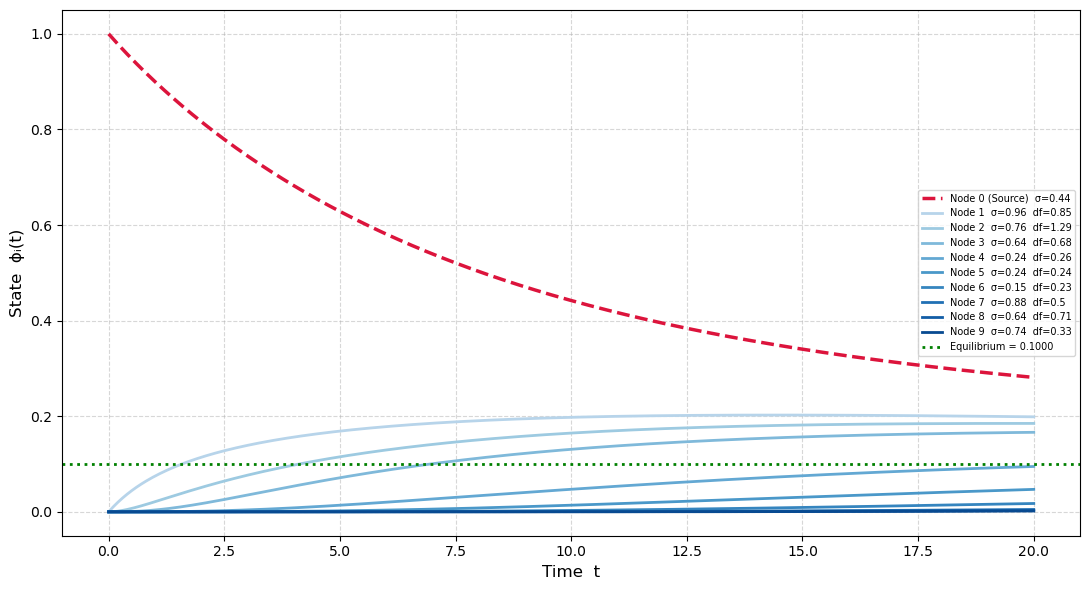

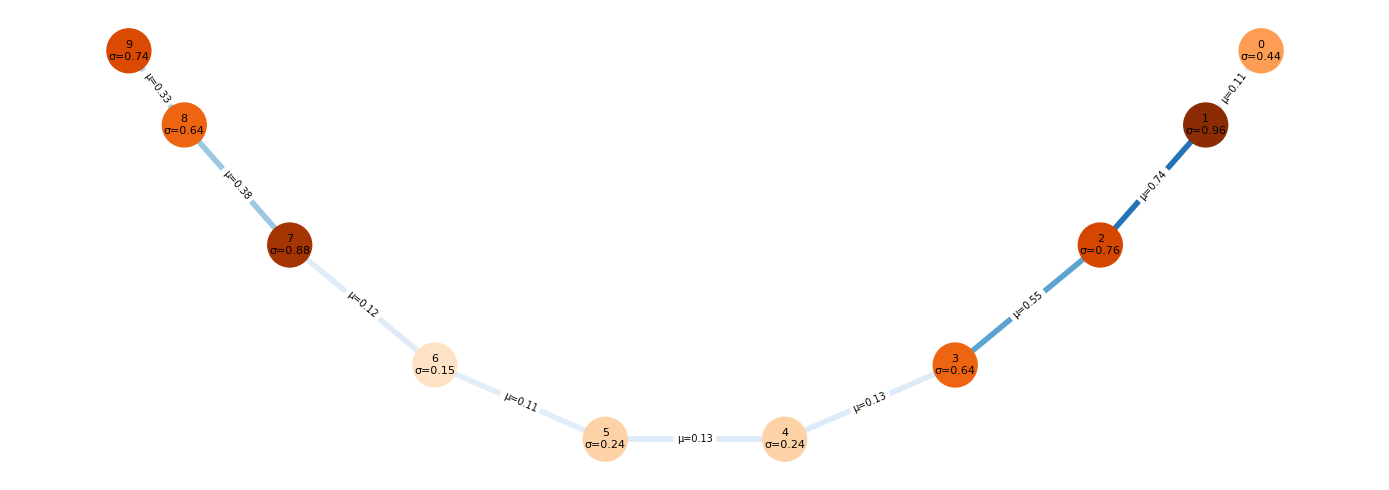


              DIFFUSION SUMMARY
Network         : Fuzzy Path P10  (10 nodes)
Source node     : Node 0  (left endpoint),  ϕ(0) = 1.0
Equilibrium     : 0.1000  (= 1/n = 1/10)
Total edges     : 9  (= n-1 for a path)

Final states at t = 20:
  Node 0: ϕ(20) = 0.2813
  Node 1: ϕ(20) = 0.1988
  Node 2: ϕ(20) = 0.1850
  Node 3: ϕ(20) = 0.1663
  Node 4: ϕ(20) = 0.0949
  Node 5: ϕ(20) = 0.0470
  Node 6: ϕ(20) = 0.0174
  Node 7: ϕ(20) = 0.0049
  Node 8: ϕ(20) = 0.0027
  Node 9: ϕ(20) = 0.0017

Edge memberships µ along the path (left → right):
  (0 → 1): µ = 0.11  ← BOTTLENECK
  (1 → 2): µ = 0.74
  (2 → 3): µ = 0.55
  (3 → 4): µ = 0.13
  (4 → 5): µ = 0.13
  (5 → 6): µ = 0.11  ← BOTTLENECK
  (6 → 7): µ = 0.12
  (7 → 8): µ = 0.38
  (8 → 9): µ = 0.33

Fuzzy degree df(i) per node:
  Node 0 (endpoint): df = 0.11
  Node 1 (interior): df = 0.85
  Node 2 (interior): df = 1.29
  Node 3 (interior): df = 0.68
  Node 4 (interior): df = 0.26
  Node 5 (interior): df = 0.24
  Node 6 (interior): df = 0.23
  Nod

In [37]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.linalg import expm

# ── Parameters ────────────────────────────────────────────────────────────────
# A path graph P10 is a graph where nodes are connected in a single line:
# 0 - 1 - 2 - 3 - 4 - 5 - 6 - 7 - 8 - 9
# Unlike a cycle, the path has NO closing edge between node 9 and node 0.
# From Definition 2.2.8: a path is a trail where all vertices are distinct.
# Node degrees: end nodes (0 and 9) have degree 1, all others have degree 2.
# This makes P10 non-regular — a key difference from the cycle C10.
NUM_NODES  = 10
T_END      = 20
NUM_STEPS  = 400

# ── Step 1: Build the Fuzzy Path Graph P10 ────────────────────────────────────
# A path connects nodes in a straight line: 0-1-2-...-9
# No closing edge — node 0 and node 9 are the two endpoints (degree 1).
# From Definition 2.5.1 (Rosenfeld, 1975): G = (V, σ, µ) where
# µ(u,v) ≤ min(σ(u), σ(v)) must hold for every edge.

G = nx.Graph()

# Add all nodes with random fuzzy membership values σ(v) ∈ (0.1, 1]
np.random.seed(42)
for node in range(NUM_NODES):
    sigma = round(np.random.uniform(0.1, 1.0), 2)
    G.add_node(node, sigma=sigma)

# Add path edges: node i connects only to node i+1
# No wrap-around — this is what distinguishes a path from a cycle
path_edges = [(i, i + 1) for i in range(NUM_NODES - 1)]
for u, v in path_edges:
    sigma_u  = G.nodes[u]['sigma']
    sigma_v  = G.nodes[v]['sigma']
    max_mu   = min(sigma_u, sigma_v)       # fuzzy constraint from Definition 2.5.1
    mu       = round(np.random.uniform(0.1, max_mu), 2)
    G.add_edge(u, v, mu=mu)


# ── Step 2: Build the Fuzzy Laplacian Matrix Lf = Df - Af ────────────────────
# From Section 2.6.3: Lf = Df - Af
# Af — fuzzy adjacency matrix: Af[i][j] = µ(i,j) if edge exists, else 0
# Df — fuzzy degree matrix: diagonal, Df[i][i] = sum of µ over all edges of i
# Key insight: endpoint nodes (0 and 9) have only ONE edge, so their fuzzy
# degree df equals just that one µ value — making them the weakest receivers.
# Interior nodes have TWO edges, so their df is the sum of two µ values.

n     = G.number_of_nodes()
nodes = list(G.nodes())
idx   = {node: i for i, node in enumerate(nodes)}

# Fuzzy adjacency matrix Af
Af = np.zeros((n, n))
for u, v, data in G.edges(data=True):
    i, j     = idx[u], idx[v]
    Af[i][j] = data['mu']
    Af[j][i] = data['mu']        # symmetric — undirected

# Fuzzy degree matrix Df
Df = np.diag(Af.sum(axis=1))

# Fuzzy Laplacian
Lf = Df - Af

print("\nFuzzy Adjacency Matrix Af:")
print(np.round(Af, 2))
print("\nFuzzy Degree Matrix Df:")
print(np.round(Df, 2))
print("\nFuzzy Laplacian Matrix Lf:")
print(np.round(Lf, 2))

# ── Step 3: Set Initial Conditions ϕ(0) ──────────────────────────────────────
# Node 0 is the source — the leftmost endpoint of the path.
# Substance must travel strictly left to right along the line.
# Node 9 (the other endpoint) is the last to receive substance —
# it has only one incoming edge and no alternative path.
# From equation (3.3.6): ϕ(t) = e^{-tLf} ϕ(0)

phi0         = np.zeros(n)
phi0[idx[0]] = 1.0

equilibrium  = phi0.sum() / n    # Theorem 3.3.2: all nodes converge to 1/n

print(f"\nInitial state ϕ(0)     : {phi0}")
print(f"Theoretical equilibrium : {equilibrium:.4f}  (= 1/n = 1/{n})")
print(f"\nNode memberships σ:")
for nd in G.nodes():
    print(f"  Node {nd}: σ = {G.nodes[nd]['sigma']}")

# ── Step 4: Simulate Fuzzy Diffusion ϕ(t) = e^{-t*Lf} ϕ(0) ──────────────────
# In a path graph there is ONLY ONE path between any two nodes —
# unlike the cycle which has two paths (clockwise and anticlockwise).
# This means:
#   - Diffusion is strictly sequential: 0 → 1 → 2 → ... → 9
#   - A single low-µ edge anywhere in the chain acts as a full bottleneck
#     blocking substance from reaching all downstream nodes quickly
#   - This is the slowest topology for diffusion among all we have studied
#   - The fuzzy model reveals exactly WHICH edge is the bottleneck

time_steps = np.linspace(0, T_END, NUM_STEPS)
phi_t      = np.zeros((NUM_STEPS, n))

for k, t in enumerate(time_steps):
    phi_t[k] = expm(-t * Lf) @ phi0

# ── Step 5: Plot Diffusion Curves ─────────────────────────────────────────────
# Expected behaviour:
#   - Node 0 (source) decays from 1.0
#   - Nodes rise in order: node 1 first, then 2, then 3 ... then 9 last
#   - The rise of each node is delayed relative to its predecessor
#   - A node downstream of a low-µ edge will show a noticeably slower rise
#   - All nodes eventually converge to equilibrium = 1/n = 0.1

fig1, ax1 = plt.subplots(figsize=(11, 6))

# Source node curve
ax1.plot(time_steps, phi_t[:, idx[0]],
         label=f"Node 0 (Source)  σ={G.nodes[0]['sigma']}",
         color='crimson', linewidth=2.5, linestyle='--')

# All other node curves — ordered left to right along the path
colors = cm.Blues(np.linspace(0.3, 0.9, NUM_NODES - 1))
for i in range(1, NUM_NODES):
    nbrs = list(G.neighbors(i))
    df_i = round(sum(G[i][j]['mu'] for j in nbrs), 3)
    ax1.plot(time_steps, phi_t[:, idx[i]],
             label=f"Node {i}  σ={G.nodes[i]['sigma']}  df={df_i}",
             color=colors[i - 1], linewidth=2)

# Equilibrium line
ax1.axhline(y=equilibrium, color='green', linestyle=':', linewidth=2,
            label=f"Equilibrium = {equilibrium:.4f}")

ax1.set_xlabel("Time  t", fontsize=12)
ax1.set_ylabel("State  ϕᵢ(t)", fontsize=12)
#ax1.set_title("Diffusion on a Fuzzy P10 Network\n"
              #"ϕ(t) = e^{−tLf} ϕ(0)  |  Source: Node 0  (left endpoint)",
              #fontsize=11)
ax1.legend(fontsize=7, loc='right')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("Diffusion_on_a_Fuzzy_P10.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# ── Step 6: Visualise the Fuzzy Path Graph ────────────────────────────────────
# nx.spectral_layout naturally arranges path nodes in a straight line —
# the best layout to show the sequential structure of P10.
# Node colours reflect σ (Oranges: darker = higher membership)
# Edge colours reflect µ (Blues: darker = stronger fuzzy tie)
# A pale edge in the middle of the path is a clear visual bottleneck.

pos          = nx.spectral_layout(G)
active_edges = [(u, v) for u, v in G.edges()]
edge_mus     = [G[u][v]['mu'] for u, v in active_edges]
edge_colors  = [cm.Blues(mu) for mu in edge_mus]
node_sigmas  = [G.nodes[nd]['sigma'] for nd in G.nodes()]
node_labels  = {nd: f"{nd}\nσ={G.nodes[nd]['sigma']}" for nd in G.nodes()}
edge_labels  = {(u, v): f"µ={G[u][v]['mu']}" for u, v in active_edges}

fig2, ax2 = plt.subplots(figsize=(14, 5))

nx.draw_networkx_nodes(G, pos,
                       node_color=node_sigmas,
                       cmap=plt.cm.Oranges,
                       node_size=1000,
                       vmin=0, vmax=1,
                       ax=ax2)

nx.draw_networkx_edges(G, pos,
                       edgelist=active_edges,
                       edge_color=edge_colors,
                       width=4,
                       ax=ax2)

nx.draw_networkx_labels(G, pos,
                        labels=node_labels,
                        font_size=8,
                        ax=ax2)

nx.draw_networkx_edge_labels(G, pos,
                             edge_labels=edge_labels,
                             font_size=7,
                             ax=ax2)

#ax2.set_title(f"Fuzzy Path Graph P{NUM_NODES}\n"
             # ,
             # fontsize=11)
ax2.axis("off")
plt.tight_layout()
plt.savefig("fuzzy_path_network.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# ── Step 7: Print Final Summary ───────────────────────────────────────────────
print(f"\n{'=' * 55}")
print(f"              DIFFUSION SUMMARY")
print(f"{'=' * 55}")
print(f"Network         : Fuzzy Path P{NUM_NODES}  ({n} nodes)")
print(f"Source node     : Node 0  (left endpoint),  ϕ(0) = 1.0")
print(f"Equilibrium     : {equilibrium:.4f}  (= 1/n = 1/{n})")
print(f"Total edges     : {G.number_of_edges()}  (= n-1 for a path)")
print(f"\nFinal states at t = {T_END}:")
for node in nodes:
    print(f"  Node {node}: ϕ({T_END}) = {phi_t[-1, idx[node]]:.4f}")
print(f"\nEdge memberships µ along the path (left → right):")
for u, v in path_edges:
    mu  = G[u][v]['mu']
    tag = "  ← BOTTLENECK" if mu == min(G[a][b]['mu'] for a, b in path_edges) else ""
    print(f"  ({u} → {v}): µ = {mu}{tag}")
print(f"\nFuzzy degree df(i) per node:")
for nd in nodes:
    nbrs = list(G.neighbors(nd))
    df   = round(sum(G[nd][nb]['mu'] for nb in nbrs), 3)
    role = "endpoint" if G.degree(nd) == 1 else "interior"
    print(f"  Node {nd} ({role}): df = {df}")
print(f"\nKey Observations:")
print(f"  1. P10 has NO closing edge — unlike cycle C10")
print(f"  2. Endpoint nodes (0 and 9) have degree 1 — P10 is NOT regular")
print(f"  3. Only ONE path exists between any two nodes — no alternative routes")
print(f"  4. A single low-µ edge blocks ALL downstream diffusion")
print(f"  5. Node 9 (far endpoint) is always the last to reach equilibrium")
print(f"  6. Convergence is the slowest of all topologies studied")

## Diffusion on a Fuzzy $P_{20}$


Fuzzy Adjacency Matrix Af:
[[0.   0.31 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.  ]
 [0.31 0.   0.19 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.  ]
 [0.   0.19 0.   0.26 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.26 0.   0.15 0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.15 0.   0.16 0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.16 0.   0.14 0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.14 0.   0.11 0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.11 0.   0.38 0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.38 0.   0.42 0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.4

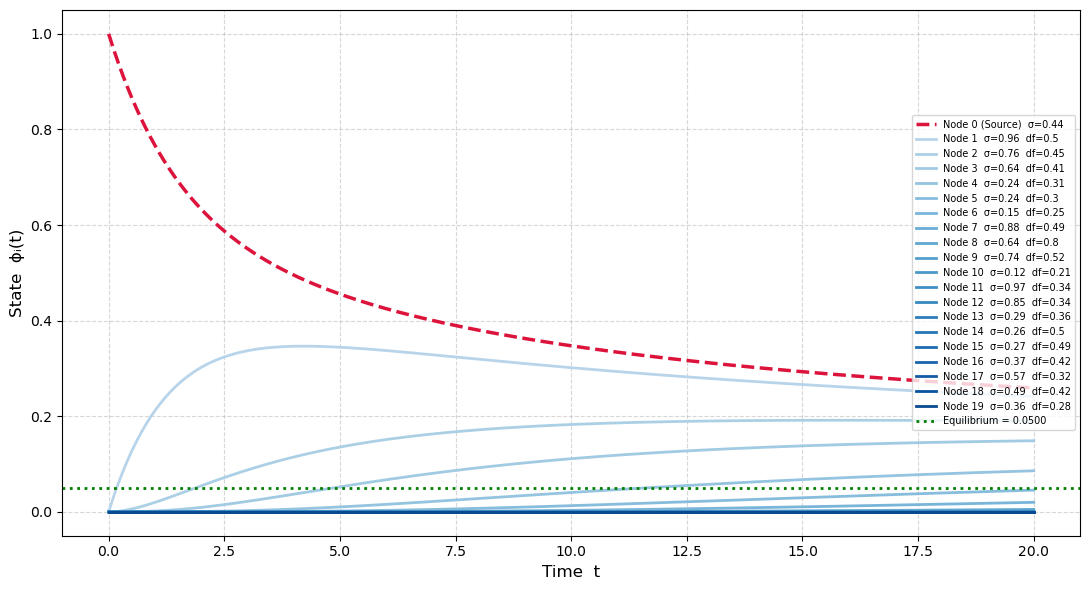

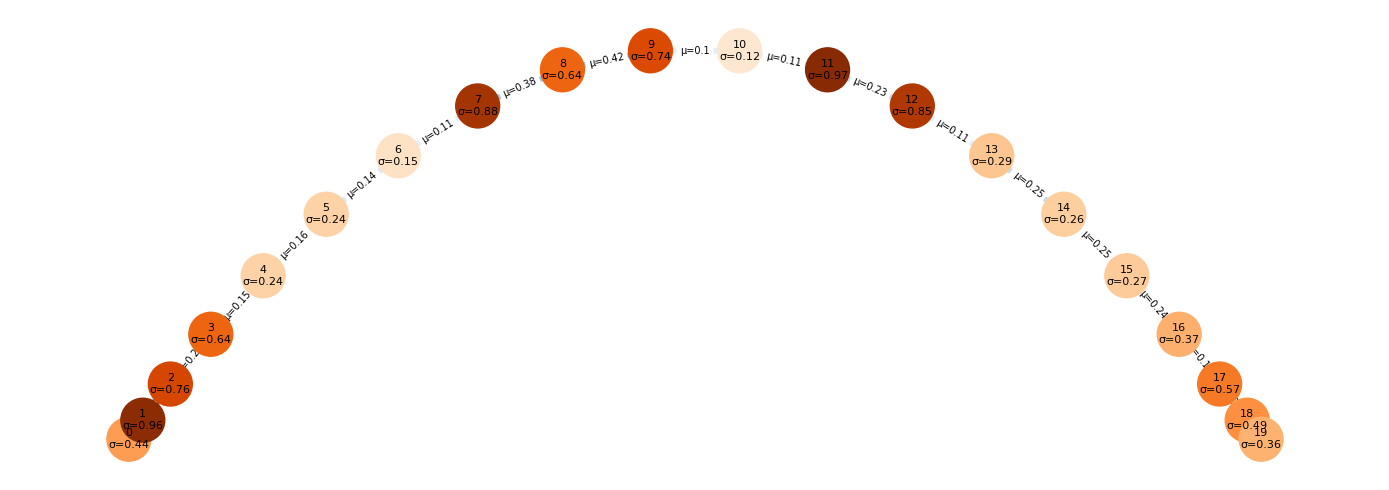


              DIFFUSION SUMMARY
Network         : Fuzzy Path P20  (20 nodes)
Source node     : Node 0  (left endpoint),  ϕ(0) = 1.0
Equilibrium     : 0.0500  (= 1/n = 1/20)
Total edges     : 19  (= n-1 for a path)

Final states at t = 20:
  Node 0: ϕ(20) = 0.2592
  Node 1: ϕ(20) = 0.2413
  Node 2: ϕ(20) = 0.1896
  Node 3: ϕ(20) = 0.1487
  Node 4: ϕ(20) = 0.0859
  Node 5: ϕ(20) = 0.0454
  Node 6: ϕ(20) = 0.0199
  Node 7: ϕ(20) = 0.0051
  Node 8: ϕ(20) = 0.0027
  Node 9: ϕ(20) = 0.0016
  Node 10: ϕ(20) = 0.0004
  Node 11: ϕ(20) = 0.0001
  Node 12: ϕ(20) = 0.0000
  Node 13: ϕ(20) = 0.0000
  Node 14: ϕ(20) = 0.0000
  Node 15: ϕ(20) = 0.0000
  Node 16: ϕ(20) = 0.0000
  Node 17: ϕ(20) = 0.0000
  Node 18: ϕ(20) = 0.0000
  Node 19: ϕ(20) = 0.0000

Edge memberships µ along the path (left → right):
  (0 → 1): µ = 0.31
  (1 → 2): µ = 0.19
  (2 → 3): µ = 0.26
  (3 → 4): µ = 0.15
  (4 → 5): µ = 0.16
  (5 → 6): µ = 0.14
  (6 → 7): µ = 0.11
  (7 → 8): µ = 0.38
  (8 → 9): µ = 0.42
  (9 → 10): µ = 0.1

In [38]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.linalg import expm

# ── Parameters ────────────────────────────────────────────────────────────────
# A path graph P10 is a graph where nodes are connected in a single line:
# 0 - 1 - 2 - 3 - 4 - 5 - 6 - 7 - 8 - 9
# Unlike a cycle, the path has NO closing edge between node 9 and node 0.
# From Definition 2.2.8: a path is a trail where all vertices are distinct.
# Node degrees: end nodes (0 and 9) have degree 1, all others have degree 2.
# This makes P10 non-regular — a key difference from the cycle C10.
NUM_NODES  = 20
T_END      = 20
NUM_STEPS  = 400

# ── Step 1: Build the Fuzzy Path Graph P10 ────────────────────────────────────
# A path connects nodes in a straight line: 0-1-2-...-9
# No closing edge — node 0 and node 9 are the two endpoints (degree 1).
# From Definition 2.5.1 (Rosenfeld, 1975): G = (V, σ, µ) where
# µ(u,v) ≤ min(σ(u), σ(v)) must hold for every edge.

G = nx.Graph()

# Add all nodes with random fuzzy membership values σ(v) ∈ (0.1, 1]
np.random.seed(42)
for node in range(NUM_NODES):
    sigma = round(np.random.uniform(0.1, 1.0), 2)
    G.add_node(node, sigma=sigma)

# Add path edges: node i connects only to node i+1
# No wrap-around — this is what distinguishes a path from a cycle
path_edges = [(i, i + 1) for i in range(NUM_NODES - 1)]
for u, v in path_edges:
    sigma_u  = G.nodes[u]['sigma']
    sigma_v  = G.nodes[v]['sigma']
    max_mu   = min(sigma_u, sigma_v)       # fuzzy constraint from Definition 2.5.1
    mu       = round(np.random.uniform(0.1, max_mu), 2)
    G.add_edge(u, v, mu=mu)


# ── Step 2: Build the Fuzzy Laplacian Matrix Lf = Df - Af ────────────────────
# From Section 2.6.3: Lf = Df - Af
# Af — fuzzy adjacency matrix: Af[i][j] = µ(i,j) if edge exists, else 0
# Df — fuzzy degree matrix: diagonal, Df[i][i] = sum of µ over all edges of i
# Key insight: endpoint nodes (0 and 9) have only ONE edge, so their fuzzy
# degree df equals just that one µ value — making them the weakest receivers.
# Interior nodes have TWO edges, so their df is the sum of two µ values.

n     = G.number_of_nodes()
nodes = list(G.nodes())
idx   = {node: i for i, node in enumerate(nodes)}

# Fuzzy adjacency matrix Af
Af = np.zeros((n, n))
for u, v, data in G.edges(data=True):
    i, j     = idx[u], idx[v]
    Af[i][j] = data['mu']
    Af[j][i] = data['mu']        # symmetric — undirected

# Fuzzy degree matrix Df
Df = np.diag(Af.sum(axis=1))

# Fuzzy Laplacian
Lf = Df - Af

print("\nFuzzy Adjacency Matrix Af:")
print(np.round(Af, 2))
print("\nFuzzy Degree Matrix Df:")
print(np.round(Df, 2))
print("\nFuzzy Laplacian Matrix Lf:")
print(np.round(Lf, 2))

# ── Step 3: Set Initial Conditions ϕ(0) ──────────────────────────────────────
# Node 0 is the source — the leftmost endpoint of the path.
# Substance must travel strictly left to right along the line.
# Node 9 (the other endpoint) is the last to receive substance —
# it has only one incoming edge and no alternative path.
# From equation (3.3.6): ϕ(t) = e^{-tLf} ϕ(0)

phi0         = np.zeros(n)
phi0[idx[0]] = 1.0

equilibrium  = phi0.sum() / n    # Theorem 3.3.2: all nodes converge to 1/n

print(f"\nInitial state ϕ(0)     : {phi0}")
print(f"Theoretical equilibrium : {equilibrium:.4f}  (= 1/n = 1/{n})")
print(f"\nNode memberships σ:")
for nd in G.nodes():
    print(f"  Node {nd}: σ = {G.nodes[nd]['sigma']}")

# ── Step 4: Simulate Fuzzy Diffusion ϕ(t) = e^{-t*Lf} ϕ(0) ──────────────────
# In a path graph there is ONLY ONE path between any two nodes —
# unlike the cycle which has two paths (clockwise and anticlockwise).
# This means:
#   - Diffusion is strictly sequential: 0 → 1 → 2 → ... → 9
#   - A single low-µ edge anywhere in the chain acts as a full bottleneck
#     blocking substance from reaching all downstream nodes quickly
#   - This is the slowest topology for diffusion among all we have studied
#   - The fuzzy model reveals exactly WHICH edge is the bottleneck

time_steps = np.linspace(0, T_END, NUM_STEPS)
phi_t      = np.zeros((NUM_STEPS, n))

for k, t in enumerate(time_steps):
    phi_t[k] = expm(-t * Lf) @ phi0

# ── Step 5: Plot Diffusion Curves ─────────────────────────────────────────────
# Expected behaviour:
#   - Node 0 (source) decays from 1.0
#   - Nodes rise in order: node 1 first, then 2, then 3 ... then 9 last
#   - The rise of each node is delayed relative to its predecessor
#   - A node downstream of a low-µ edge will show a noticeably slower rise
#   - All nodes eventually converge to equilibrium = 1/n = 0.1

fig1, ax1 = plt.subplots(figsize=(11, 6))

# Source node curve
ax1.plot(time_steps, phi_t[:, idx[0]],
         label=f"Node 0 (Source)  σ={G.nodes[0]['sigma']}",
         color='crimson', linewidth=2.5, linestyle='--')

# All other node curves — ordered left to right along the path
colors = cm.Blues(np.linspace(0.3, 0.9, NUM_NODES - 1))
for i in range(1, NUM_NODES):
    nbrs = list(G.neighbors(i))
    df_i = round(sum(G[i][j]['mu'] for j in nbrs), 3)
    ax1.plot(time_steps, phi_t[:, idx[i]],
             label=f"Node {i}  σ={G.nodes[i]['sigma']}  df={df_i}",
             color=colors[i - 1], linewidth=2)

# Equilibrium line
ax1.axhline(y=equilibrium, color='green', linestyle=':', linewidth=2,
            label=f"Equilibrium = {equilibrium:.4f}")

ax1.set_xlabel("Time  t", fontsize=12)
ax1.set_ylabel("State  ϕᵢ(t)", fontsize=12)
#ax1.set_title("Diffusion on a Fuzzy P20 Network\n"
              #"ϕ(t) = e^{−tLf} ϕ(0)  |  Source: Node 0  (left endpoint)",
              #fontsize=11)
ax1.legend(fontsize=7, loc='right')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("Diffusion_on_a_fuzzy_P20.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# ── Step 6: Visualise the Fuzzy Path Graph ────────────────────────────────────
# nx.spectral_layout naturally arranges path nodes in a straight line —
# the best layout to show the sequential structure of P10.
# Node colours reflect σ (Oranges: darker = higher membership)
# Edge colours reflect µ (Blues: darker = stronger fuzzy tie)
# A pale edge in the middle of the path is a clear visual bottleneck.

pos          = nx.spectral_layout(G)
active_edges = [(u, v) for u, v in G.edges()]
edge_mus     = [G[u][v]['mu'] for u, v in active_edges]
edge_colors  = [cm.Blues(mu) for mu in edge_mus]
node_sigmas  = [G.nodes[nd]['sigma'] for nd in G.nodes()]
node_labels  = {nd: f"{nd}\nσ={G.nodes[nd]['sigma']}" for nd in G.nodes()}
edge_labels  = {(u, v): f"µ={G[u][v]['mu']}" for u, v in active_edges}

fig2, ax2 = plt.subplots(figsize=(14, 5))

nx.draw_networkx_nodes(G, pos,
                       node_color=node_sigmas,
                       cmap=plt.cm.Oranges,
                       node_size=1000,
                       vmin=0, vmax=1,
                       ax=ax2)

nx.draw_networkx_edges(G, pos,
                       edgelist=active_edges,
                       edge_color=edge_colors,
                       width=4,
                       ax=ax2)

nx.draw_networkx_labels(G, pos,
                        labels=node_labels,
                        font_size=8,
                        ax=ax2)

nx.draw_networkx_edge_labels(G, pos,
                             edge_labels=edge_labels,
                             font_size=7,
                             ax=ax2)

#ax2.set_title(f"Fuzzy Path Graph P{NUM_NODES}\n"
            # ,
             # fontsize=11)
ax2.axis("off")
plt.tight_layout()
plt.savefig("fuzzy_path_network20.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# ── Step 7: Print Final Summary ───────────────────────────────────────────────
print(f"\n{'=' * 55}")
print(f"              DIFFUSION SUMMARY")
print(f"{'=' * 55}")
print(f"Network         : Fuzzy Path P{NUM_NODES}  ({n} nodes)")
print(f"Source node     : Node 0  (left endpoint),  ϕ(0) = 1.0")
print(f"Equilibrium     : {equilibrium:.4f}  (= 1/n = 1/{n})")
print(f"Total edges     : {G.number_of_edges()}  (= n-1 for a path)")
print(f"\nFinal states at t = {T_END}:")
for node in nodes:
    print(f"  Node {node}: ϕ({T_END}) = {phi_t[-1, idx[node]]:.4f}")
print(f"\nEdge memberships µ along the path (left → right):")
for u, v in path_edges:
    mu  = G[u][v]['mu']
    tag = "  ← BOTTLENECK" if mu == min(G[a][b]['mu'] for a, b in path_edges) else ""
    print(f"  ({u} → {v}): µ = {mu}{tag}")
print(f"\nFuzzy degree df(i) per node:")
for nd in nodes:
    nbrs = list(G.neighbors(nd))
    df   = round(sum(G[nd][nb]['mu'] for nb in nbrs), 3)
    role = "endpoint" if G.degree(nd) == 1 else "interior"
    print(f"  Node {nd} ({role}): df = {df}")
print(f"\nKey Observations:")
print(f"  1. P10 has NO closing edge — unlike cycle C10")
print(f"  2. Endpoint nodes (0 and 9) have degree 1 — P10 is NOT regular")
print(f"  3. Only ONE path exists between any two nodes — no alternative routes")
print(f"  4. A single low-µ edge blocks ALL downstream diffusion")
print(f"  5. Node 9 (far endpoint) is always the last to reach equilibrium")
print(f"  6. Convergence is the slowest of all topologies studied")

## Fuzzy Diffusion (Hub Node) Comparison  $P_{10}$ vs $P_{20}$

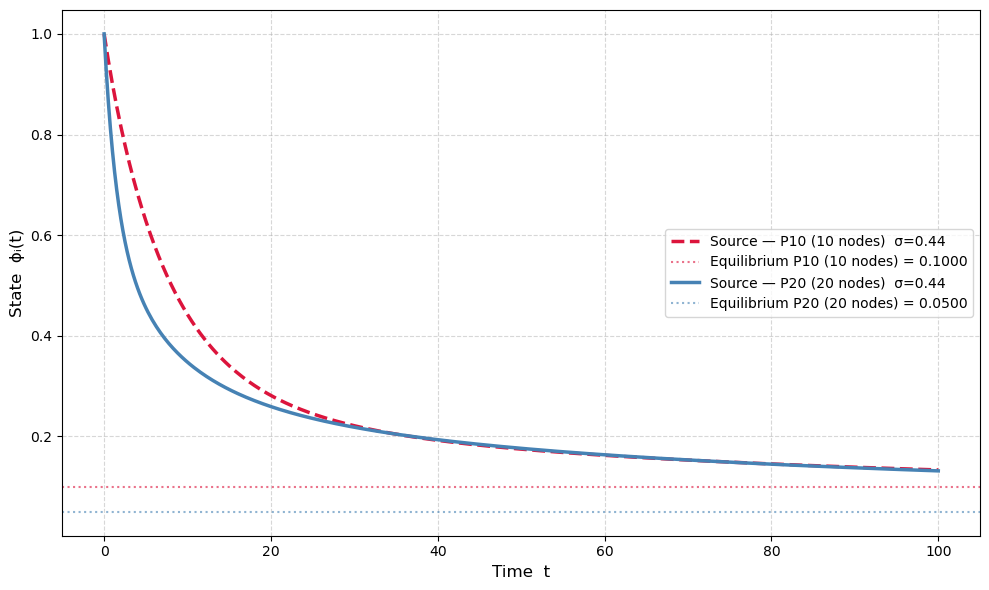

In [39]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

T_END, NUM_STEPS = 100, 400
time_steps = np.linspace(0, T_END, NUM_STEPS)

configs = [
    {"NUM_NODES": 10, "color": "crimson",   "linestyle": "--", "label": "P10 (10 nodes)"},
    {"NUM_NODES": 20, "color": "steelblue", "linestyle": "-",  "label": "P20 (20 nodes)"},
]

fig, ax = plt.subplots(figsize=(10, 6))

for cfg in configs:
    NUM_NODES = cfg["NUM_NODES"]

    # Build fuzzy path graph
    G = nx.Graph()
    np.random.seed(42)
    for node in range(NUM_NODES):
        G.add_node(node, sigma=round(np.random.uniform(0.1, 1.0), 2))
    for u, v in [(i, i + 1) for i in range(NUM_NODES - 1)]:
        max_mu = min(G.nodes[u]['sigma'], G.nodes[v]['sigma'])
        G.add_edge(u, v, mu=round(np.random.uniform(0.1, max_mu), 2))

    # Fuzzy Laplacian
    n   = G.number_of_nodes()
    idx = {node: i for i, node in enumerate(G.nodes())}
    Af  = np.zeros((n, n))
    for u, v, data in G.edges(data=True):
        Af[idx[u]][idx[v]] = Af[idx[v]][idx[u]] = data['mu']
    Lf = np.diag(Af.sum(axis=1)) - Af

    # Initial conditions
    phi0         = np.zeros(n)
    phi0[idx[0]] = 1.0
    equilibrium  = phi0.sum() / n

    # Simulate
    phi_t = np.array([expm(-t * Lf) @ phi0 for t in time_steps])

    # Plot
    ax.plot(time_steps, phi_t[:, idx[0]],
            color=cfg["color"], linestyle=cfg["linestyle"], linewidth=2.5,
            label=f"Source — {cfg['label']}  σ={G.nodes[0]['sigma']}")

    ax.axhline(y=equilibrium, color=cfg["color"], linestyle=":", linewidth=1.5, alpha=0.6,
               label=f"Equilibrium {cfg['label']} = {equilibrium:.4f}")

ax.set_xlabel("Time  t", fontsize=12)
ax.set_ylabel("State  ϕᵢ(t)", fontsize=12)
#ax.set_title("Comparison of the diffusion between the hub node of the fuzzy P10 vs P20\n"
           # , fontsize=11)
ax.legend(fontsize=10, loc='right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("Diffusion_comparison_on_fuzzy_P10_vs_P20.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

## Diffusion on crisps and fuzzy $P_{10}$ network in one plot

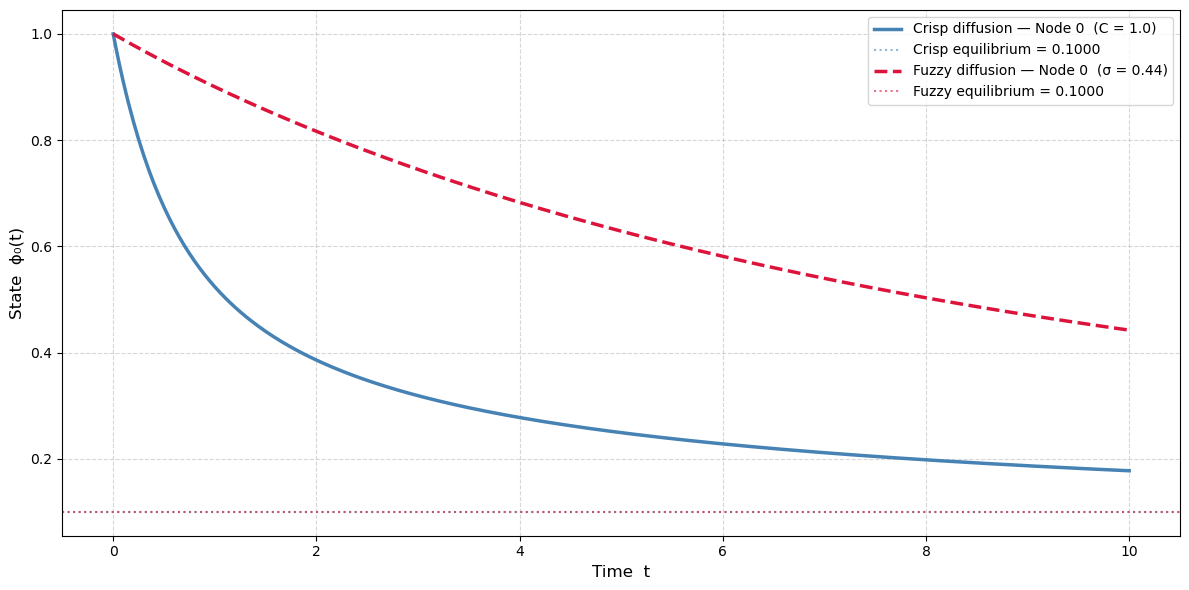

In [40]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

NUM_NODES = 10
T_END     = 10
NUM_STEPS = 400
C         = 1.0
np.random.seed(42)

# ── Crisp ──────────────────────────────────────────────────────────
G_crisp = nx.path_graph(NUM_NODES)
n       = G_crisp.number_of_nodes()
idx_c   = {node: i for i, node in enumerate(G_crisp.nodes())}
A = np.zeros((n, n))
for u, v in G_crisp.edges():
    A[idx_c[u]][idx_c[v]] = A[idx_c[v]][idx_c[u]] = 1
L  = np.diag(A.sum(axis=1)) - A
phi0_c        = np.zeros(n); phi0_c[idx_c[0]] = 1.0
eq_c          = phi0_c.sum() / n
time_steps    = np.linspace(0, T_END, NUM_STEPS)
phi_c         = np.array([expm(-C * t * L) @ phi0_c for t in time_steps])

# ── Fuzzy ──────────────────────────────────────────────────────────
G = nx.Graph()
for node in range(NUM_NODES):
    G.add_node(node, sigma=round(np.random.uniform(0.1, 1.0), 2))
for u, v in [(i, i+1) for i in range(NUM_NODES - 1)]:
    mu = round(np.random.uniform(0.1, min(G.nodes[u]['sigma'], G.nodes[v]['sigma'])), 2)
    G.add_edge(u, v, mu=mu)
n2    = G.number_of_nodes()
idx_f = {node: i for i, node in enumerate(G.nodes())}
Af    = np.zeros((n2, n2))
for u, v, data in G.edges(data=True):
    Af[idx_f[u]][idx_f[v]] = Af[idx_f[v]][idx_f[u]] = data['mu']
Lf = np.diag(Af.sum(axis=1)) - Af
phi0_f        = np.zeros(n2); phi0_f[idx_f[0]] = 1.0
eq_f          = phi0_f.sum() / n2
phi_f         = np.array([expm(-t * Lf) @ phi0_f for t in time_steps])

# ── Single plot ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(time_steps, phi_c[:, idx_c[0]],
        color='steelblue', linewidth=2.5, linestyle='-',
        label="Crisp diffusion — Node 0  (C = 1.0)")
ax.axhline(y=eq_c, color='steelblue', linestyle=':', linewidth=1.5, alpha=0.6,
           label=f"Crisp equilibrium = {eq_c:.4f}")

ax.plot(time_steps, phi_f[:, idx_f[0]],
        color='crimson', linewidth=2.5, linestyle='--',
        label=f"Fuzzy diffusion — Node 0  (σ = {G.nodes[0]['sigma']})")
ax.axhline(y=eq_f, color='crimson', linestyle=':', linewidth=1.5, alpha=0.6,
           label=f"Fuzzy equilibrium = {eq_f:.4f}")

ax.set_xlabel("Time  t", fontsize=12)
ax.set_ylabel("State  ϕ₀(t)", fontsize=12)
#ax.set_title("Comparison of the diffusion between the hub nodes of the fuzzy and crisps P10\n"
           # , fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("Fuzzy vs crisps diffusion_P10.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# Diffusion on crisps and fuzzy $P_{20}$ network in one plot

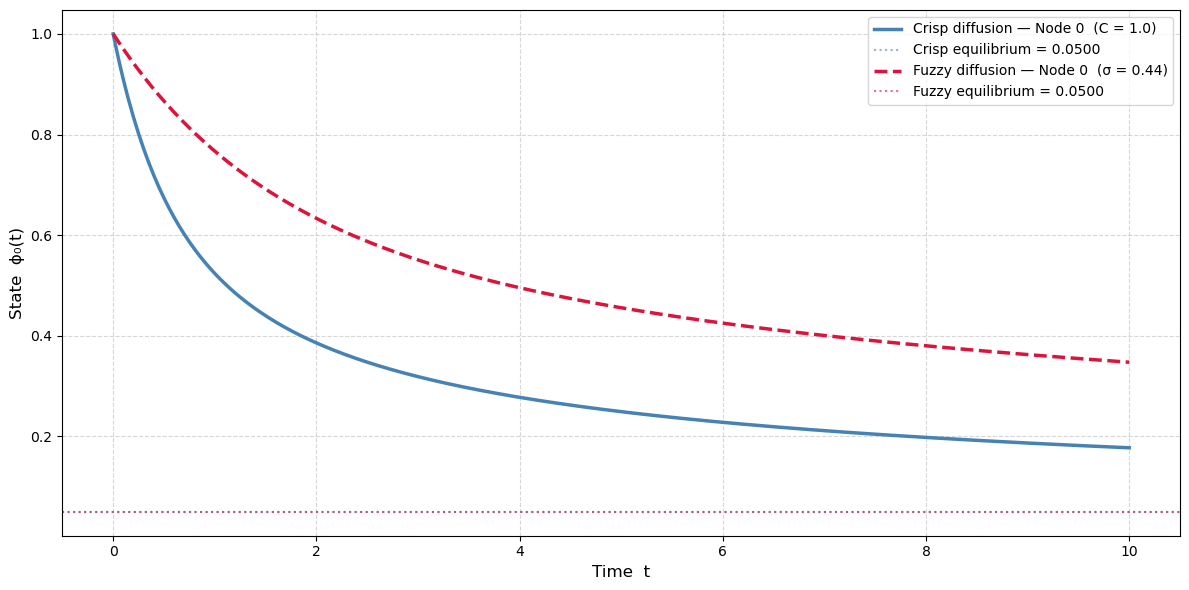

In [41]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

NUM_NODES = 20
T_END     = 10
NUM_STEPS = 400
C         = 1.0
np.random.seed(42)

# ── Crisp ──────────────────────────────────────────────────────────
G_crisp = nx.path_graph(NUM_NODES)
n       = G_crisp.number_of_nodes()
idx_c   = {node: i for i, node in enumerate(G_crisp.nodes())}
A = np.zeros((n, n))
for u, v in G_crisp.edges():
    A[idx_c[u]][idx_c[v]] = A[idx_c[v]][idx_c[u]] = 1
L  = np.diag(A.sum(axis=1)) - A
phi0_c        = np.zeros(n); phi0_c[idx_c[0]] = 1.0
eq_c          = phi0_c.sum() / n
time_steps    = np.linspace(0, T_END, NUM_STEPS)
phi_c         = np.array([expm(-C * t * L) @ phi0_c for t in time_steps])

# ── Fuzzy ──────────────────────────────────────────────────────────
G = nx.Graph()
for node in range(NUM_NODES):
    G.add_node(node, sigma=round(np.random.uniform(0.1, 1.0), 2))
for u, v in [(i, i+1) for i in range(NUM_NODES - 1)]:
    mu = round(np.random.uniform(0.1, min(G.nodes[u]['sigma'], G.nodes[v]['sigma'])), 2)
    G.add_edge(u, v, mu=mu)
n2    = G.number_of_nodes()
idx_f = {node: i for i, node in enumerate(G.nodes())}
Af    = np.zeros((n2, n2))
for u, v, data in G.edges(data=True):
    Af[idx_f[u]][idx_f[v]] = Af[idx_f[v]][idx_f[u]] = data['mu']
Lf = np.diag(Af.sum(axis=1)) - Af
phi0_f        = np.zeros(n2); phi0_f[idx_f[0]] = 1.0
eq_f          = phi0_f.sum() / n2
phi_f         = np.array([expm(-t * Lf) @ phi0_f for t in time_steps])

# ── Single plot ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(time_steps, phi_c[:, idx_c[0]],
        color='steelblue', linewidth=2.5, linestyle='-',
        label="Crisp diffusion — Node 0  (C = 1.0)")
ax.axhline(y=eq_c, color='steelblue', linestyle=':', linewidth=1.5, alpha=0.6,
           label=f"Crisp equilibrium = {eq_c:.4f}")

ax.plot(time_steps, phi_f[:, idx_f[0]],
        color='crimson', linewidth=2.5, linestyle='--',
        label=f"Fuzzy diffusion — Node 0  (σ = {G.nodes[0]['sigma']})")
ax.axhline(y=eq_f, color='crimson', linestyle=':', linewidth=1.5, alpha=0.6,
           label=f"Fuzzy equilibrium = {eq_f:.4f}")

ax.set_xlabel("Time  t", fontsize=12)
ax.set_ylabel("State  ϕ₀(t)", fontsize=12)
#ax.set_title("Comparison of the diffusion between the hub nodes of the fuzzy and crisps P20\n"
            # , fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("Fuzzy vs crisps diffusion_P20.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# 5. A randomly generated fuzzy network of Order 1000


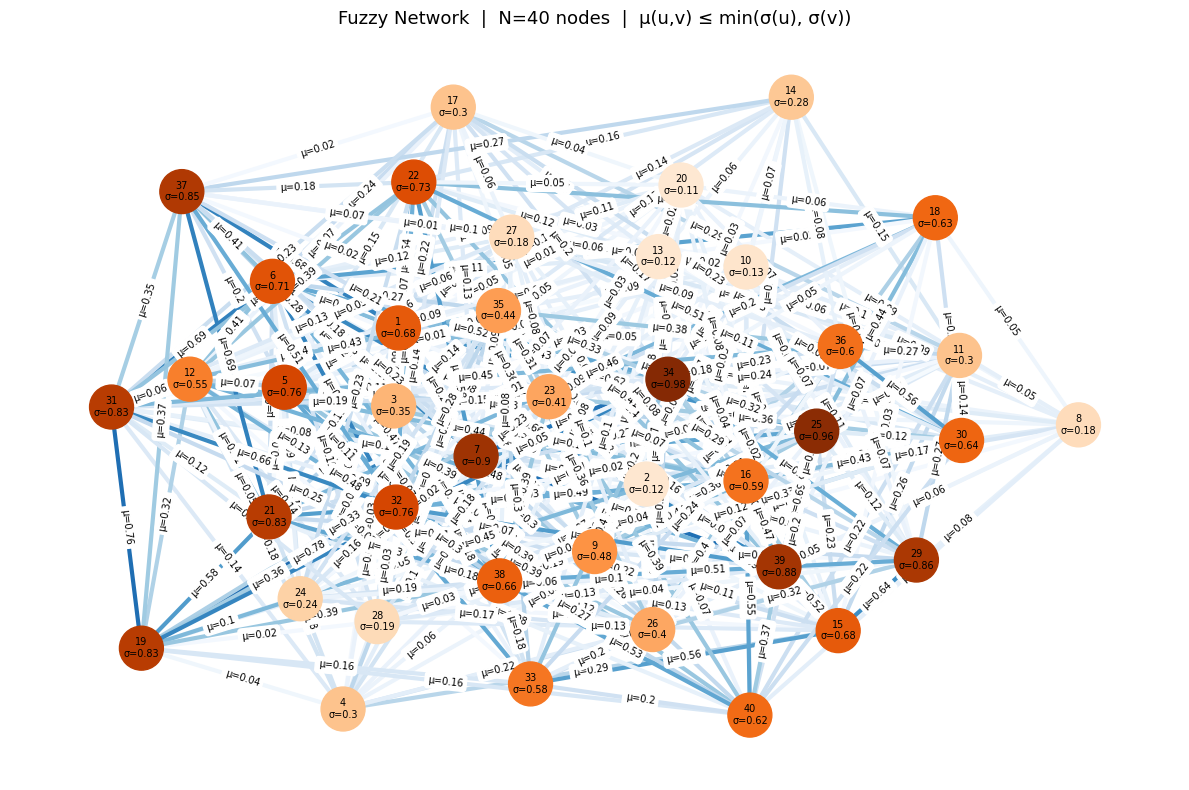


Network Summary
───────────────────────────────────
Nodes         : 40
Active edges  : 383

Node memberships (σ):
  v1: σ = 0.68
  v2: σ = 0.12
  v3: σ = 0.35
  v4: σ = 0.3
  v5: σ = 0.76
  v6: σ = 0.71
  v7: σ = 0.9
  v8: σ = 0.18
  v9: σ = 0.48
  v10: σ = 0.13
  v11: σ = 0.3
  v12: σ = 0.55
  v13: σ = 0.12
  v14: σ = 0.28
  v15: σ = 0.68
  v16: σ = 0.59
  v17: σ = 0.3
  v18: σ = 0.63
  v19: σ = 0.83
  v20: σ = 0.11
  v21: σ = 0.83
  v22: σ = 0.73
  v23: σ = 0.41
  v24: σ = 0.24
  v25: σ = 0.96
  v26: σ = 0.4
  v27: σ = 0.18
  v28: σ = 0.19
  v29: σ = 0.86
  v30: σ = 0.64
  v31: σ = 0.83
  v32: σ = 0.76
  v33: σ = 0.58
  v34: σ = 0.98
  v35: σ = 0.44
  v36: σ = 0.6
  v37: σ = 0.85
  v38: σ = 0.66
  v39: σ = 0.88
  v40: σ = 0.62

Edge memberships (µ):
  (1,3): µ = 0.09
  (1,4): µ = 0.03
  (1,5): µ = 0.08
  (1,6): µ = 0.44
  (1,7): µ = 0.26
  (1,8): µ = 0.06
  (1,12): µ = 0.4
  (1,13): µ = 0.05
  (1,20): µ = 0.01
  (1,21): µ = 0.19
  (1,22): µ = 0.64
  (1,24): µ = 0.16
  (1,25): µ = 0.

In [23]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import random

random.seed(42)

# ── Parameters ────────────────────────────────────────────────────────────────
NUM_NODES = 40
EDGE_PROBABILITY = 0.5

# ── Step 1: Create an empty graph ─────────────────────────────────────────────
G = nx.Graph()

# ── Step 2: Add nodes with fuzzy membership values σ(v) ∈ (0, 1] ─────────────
for node in range(1, NUM_NODES + 1):
    sigma = round(random.uniform(0.1, 1), 2)
    G.add_node(node, sigma=sigma)

# ── Step 3: Randomly add edges with fuzzy membership µ(u,v) ≤ min(σ(u), σ(v))
for u in range(1, NUM_NODES + 1):
    for v in range(u + 1, NUM_NODES + 1):
        if random.random() < EDGE_PROBABILITY:
            sigma_u = G.nodes[u]['sigma']
            sigma_v = G.nodes[v]['sigma']
            max_allowed = min(sigma_u, sigma_v)
            mu = round(random.uniform(0.01, max_allowed), 2)
            G.add_edge(u, v, mu=mu)

# ── Step 4: Keep only edges where µ > 0 ──────────────────────────────────────
active_edges = [(u, v) for u, v in G.edges() if G[u][v]['mu'] > 0]

# ── Step 5: Plot ──────────────────────────────────────────────────────────────
pos = nx.spring_layout(G, seed=42)

node_sigmas = [G.nodes[n]['sigma'] for n in G.nodes()]
edge_mus    = [G[u][v]['mu'] for u, v in active_edges]
edge_colors = [cm.Blues(mu) for mu in edge_mus]

node_labels = {n: f"{n}\nσ={G.nodes[n]['sigma']}" for n in G.nodes()}
edge_labels = {(u, v): f"µ={G[u][v]['mu']}" for u, v in active_edges}

fig, ax = plt.subplots(figsize=(12, 8))

nx.draw_networkx_nodes(G, pos,
                       node_color=node_sigmas,
                       cmap=plt.cm.Oranges,
                       node_size=1000,
                       vmin=0, vmax=1,
                       ax=ax)

nx.draw_networkx_edges(G, pos,
                       edgelist=active_edges,
                       edge_color=edge_colors,
                       width=3,
                       ax=ax)

nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=7, ax=ax)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, ax=ax)

ax.set_title(f"Fuzzy Network  |  N={NUM_NODES} nodes  |  µ(u,v) ≤ min(σ(u), σ(v))", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.savefig("fuzzy_network.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# ── Step 6: Print network summary ─────────────────────────────────────────────
print(f"\nNetwork Summary")
print(f"{'─'*35}")
print(f"Nodes         : {G.number_of_nodes()}")
print(f"Active edges  : {len(active_edges)}")
print(f"\nNode memberships (σ):")
for n in G.nodes():
    print(f"  v{n}: σ = {G.nodes[n]['sigma']}")
print(f"\nEdge memberships (µ):")
for u, v in active_edges:
    print(f"  ({u},{v}): µ = {G[u][v]['mu']}")

# 6. Spreading
## Spreading on a Fuzzy K10

   FUZZY SPREADING ON K10  -  Equation (3.4.1)
Model : phi_i(t+1) = max_{j~i} ( mu(j,i) * phi_j(t) )
        [Section 3.4, Spreading in Fuzzy Networks]

Initial state phi(0) : [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


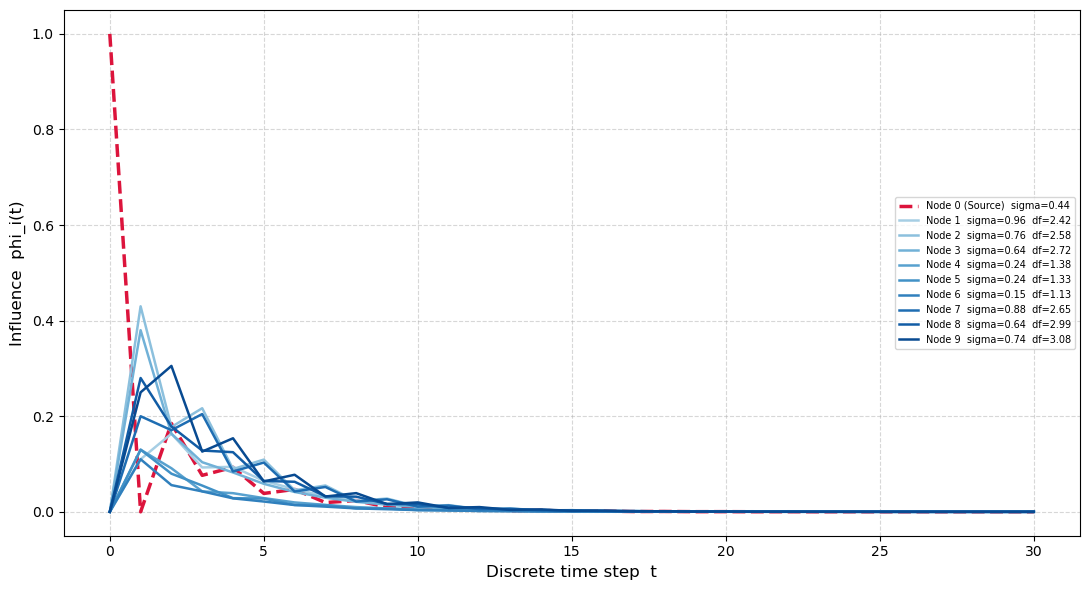


              SPREADING SUMMARY
Network      : Fuzzy Complete K10  (10 nodes)
Model        : Discrete fuzzy spreading - eq. (3.4.1)
T-norm       : Product  mu(j,i) * phi_j(t)
T-conorm     : Max  (strongest available signal wins)
Source node  : Node 0,  phi(0) = 1.0
Steps run    : 30

Peak influence per node:
  Node 0: peak phi = 1.0000 at t=0  (df = 2.02)
  Node 1: peak phi = 0.1634 at t=2  (df = 2.42)
  Node 2: peak phi = 0.4300 at t=1  (df = 2.58)
  Node 3: peak phi = 0.3800 at t=1  (df = 2.72)
  Node 4: peak phi = 0.1300 at t=1  (df = 1.38)
  Node 5: peak phi = 0.1300 at t=1  (df = 1.33)
  Node 6: peak phi = 0.1100 at t=1  (df = 1.13)
  Node 7: peak phi = 0.2046 at t=3  (df = 2.65)
  Node 8: peak phi = 0.2800 at t=1  (df = 2.99)
  Node 9: peak phi = 0.3053 at t=2  (df = 3.08)

Key observations:
  * Because all mu < 1, influence decays to 0 over time.
  * Nodes reachable via a high-mu edge from the source
    receive a stronger initial signal (higher peak phi).
  * Nodes with high f

In [42]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ── Parameters ────────────────────────────────────────────────────────────────
# Fuzzy Spreading on K10: equation (3.4.1) from Section 3.4
# phi_i(t+1) = max_{j~i} (mu(j,i) * phi_j(t))
#
# Interpretation:
#   * mu(j,i)*phi_j(t)  — signal from j to i, scaled by fuzzy tie strength
#                          (t-norm = product)
#   * max over all j    — node i aligns with the strongest available signal
#                          (t-conorm = max), preventing inflation by weak ties
#   This models influence SPREADING, not continuous heat DIFFUSION.
NUM_NODES = 10
T_STEPS   = 30          # discrete spreading steps

# ── Step 1: Rebuild the same Fuzzy K10 ───────────────────────────────────────
# Same seed as the diffusion cell so node sigma / edge mu are identical.
G = nx.Graph()

np.random.seed(42)
for node in range(NUM_NODES):
    sigma = round(np.random.uniform(0.1, 1.0), 2)
    G.add_node(node, sigma=sigma)

for u in range(NUM_NODES):
    for v in range(u + 1, NUM_NODES):
        sigma_u = G.nodes[u]['sigma']
        sigma_v = G.nodes[v]['sigma']
        max_mu  = min(sigma_u, sigma_v)
        mu      = round(np.random.uniform(0.1, max_mu), 2)
        G.add_edge(u, v, mu=mu)

n     = G.number_of_nodes()
nodes = list(G.nodes())
idx   = {node: i for i, node in enumerate(nodes)}

print('=' * 55)
print('   FUZZY SPREADING ON K10  -  Equation (3.4.1)')
print('=' * 55)
print('Model : phi_i(t+1) = max_{j~i} ( mu(j,i) * phi_j(t) )')
print('        [Section 3.4, Spreading in Fuzzy Networks]')

# ── Step 2: Initial Conditions ────────────────────────────────────────────────
# Node 0 starts with full influence (phi_0(0) = 1.0); all others at 0.
phi = np.zeros(n)
phi[idx[0]] = 1.0

print(f'\nInitial state phi(0) : {phi}')

# ── Step 3: Simulate Fuzzy Spreading ─────────────────────────────────────────
# Equation (3.4.1): phi_i(t+1) = max_{j~i} (mu(j,i) * phi_j(t))
#
# At each discrete step:
#   1. For every node i, compute the signal each neighbour j sends:
#         signal(j -> i) = mu(j,i) * phi_j(t)
#   2. Node i adopts the MAX of those signals (t-conorm = max).
#
# Because all mu < 1, the influence decays over time — the transient shows
# which nodes are reached first and how strongly, based on fuzzy path strength.

history    = np.zeros((T_STEPS + 1, n))
history[0] = phi.copy()

for t in range(T_STEPS):
    phi_new = np.zeros(n)
    for i in range(n):
        node_i  = nodes[i]
        signals = [G[node_i][nb]['mu'] * phi[idx[nb]]
                   for nb in G.neighbors(node_i)]
        phi_new[i] = max(signals) if signals else phi[i]
    phi          = phi_new
    history[t+1] = phi.copy()

# ── Step 4: Plot Spreading Trajectories ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

# Source node
ax.plot(range(T_STEPS + 1), history[:, idx[0]],
        label=f"Node 0 (Source)  sigma={G.nodes[0]['sigma']}",
        color='crimson', linewidth=2.5, linestyle='--')

# All other nodes - colour-coded by sigma
colors = cm.Blues(np.linspace(0.35, 0.9, NUM_NODES - 1))
for i in range(1, NUM_NODES):
    nd   = nodes[i]
    df_i = round(sum(G[nd][nb]['mu'] for nb in G.neighbors(nd)), 2)
    ax.plot(range(T_STEPS + 1), history[:, i],
            label=f"Node {nd}  sigma={G.nodes[nd]['sigma']}  df={df_i}",
            color=colors[i - 1], linewidth=1.8)

ax.set_xlabel('Discrete time step  t', fontsize=12)
ax.set_ylabel('Influence  phi_i(t)', fontsize=12)
#ax.set_title(
   # 'Fuzzy Spreading on a Fuzzy K10 Network \n'
    #'phi_i(t+1) = max_{j~i}(mu(j,i)*phi_j(t))  |  Source: Node 0',
    #fontsize=11)
ax.legend(fontsize=7, loc='right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('Fuzzy_Spreading_K10.pdf', dpi=150, bbox_inches='tight', format='pdf')
plt.show()

# ── Step 5: Final Summary ─────────────────────────────────────────────────────
print(f"\n{'=' * 55}")
print('              SPREADING SUMMARY')
print(f"{'=' * 55}")
print(f'Network      : Fuzzy Complete K{NUM_NODES}  ({n} nodes)')
print('Model        : Discrete fuzzy spreading - eq. (3.4.1)')
print('T-norm       : Product  mu(j,i) * phi_j(t)')
print('T-conorm     : Max  (strongest available signal wins)')
print('Source node  : Node 0,  phi(0) = 1.0')
print(f'Steps run    : {T_STEPS}')

print(f'\nPeak influence per node:')
for nd in nodes:
    i       = idx[nd]
    peak    = history[:, i].max()
    t_peak  = history[:, i].argmax()
    df      = round(sum(G[nd][nb]['mu'] for nb in G.neighbors(nd)), 2)
    print(f'  Node {nd}: peak phi = {peak:.4f} at t={t_peak}  (df = {df})')

print('\nKey observations:')
print('  * Because all mu < 1, influence decays to 0 over time.')
print('  * Nodes reachable via a high-mu edge from the source')
print('    receive a stronger initial signal (higher peak phi).')
print('  * Nodes with high fuzzy degree df are influenced faster')
print('    and more strongly than nodes with weak ties.')
print('  * Unlike continuous diffusion, there is no conserved')
print('    quantity — the spreading energy dissipates each step.')

## Spreading on a Fuzzy P10

   FUZZY SPREADING ON P10  -  Equation (3.4.1)
Model : phi_i(t+1) = max_{j~i} ( mu(j,i) * phi_j(t) )
        [Section 3.4, Spreading in Fuzzy Networks]

Node memberships sigma:
  Node 0 (endpoint): sigma = 0.44
  Node 1 (interior): sigma = 0.96
  Node 2 (interior): sigma = 0.76
  Node 3 (interior): sigma = 0.64
  Node 4 (interior): sigma = 0.24
  Node 5 (interior): sigma = 0.24
  Node 6 (interior): sigma = 0.15
  Node 7 (interior): sigma = 0.88
  Node 8 (interior): sigma = 0.64
  Node 9 (endpoint): sigma = 0.74

Edge memberships mu (left -> right along path):
  (0 -> 1): mu = 0.11  <- BOTTLENECK
  (1 -> 2): mu = 0.74
  (2 -> 3): mu = 0.55
  (3 -> 4): mu = 0.13
  (4 -> 5): mu = 0.13
  (5 -> 6): mu = 0.11  <- BOTTLENECK
  (6 -> 7): mu = 0.12
  (7 -> 8): mu = 0.38
  (8 -> 9): mu = 0.33

Initial state phi(0): [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


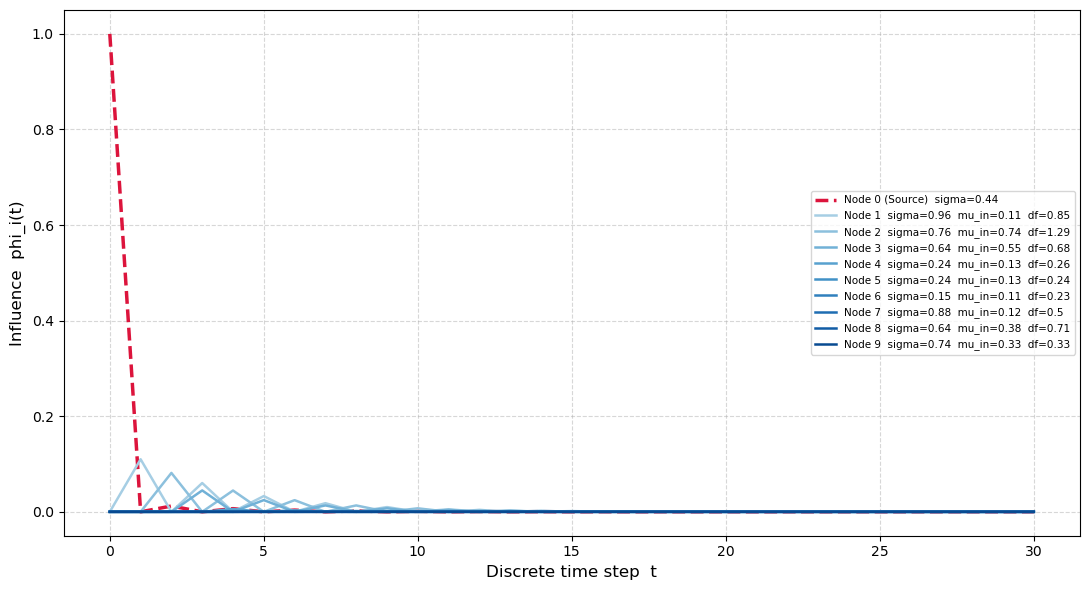


              SPREADING SUMMARY
Network      : Fuzzy Path P10  (10 nodes)
Model        : Discrete fuzzy spreading - eq. (3.4.1)
T-norm       : Product  mu(j,i) * phi_j(t)
T-conorm     : Max  (strongest available signal wins)
Source node  : Node 0  (left endpoint),  phi(0) = 1.0
Steps run    : 30

Peak influence per node:
  Node 0: peak phi = 1.000000  at t=0  (sigma=0.44,  mu_in=—,  df=0.11)
  Node 1: peak phi = 0.110000  at t=1  (sigma=0.96,  mu_in=0.11,  df=0.85)
  Node 2: peak phi = 0.081400  at t=2  (sigma=0.76,  mu_in=0.74,  df=1.29)
  Node 3: peak phi = 0.044770  at t=3  (sigma=0.64,  mu_in=0.55,  df=0.68)
  Node 4: peak phi = 0.005820  at t=4  (sigma=0.24,  mu_in=0.13,  df=0.26)
  Node 5: peak phi = 0.000757  at t=5  (sigma=0.24,  mu_in=0.13,  df=0.24)
  Node 6: peak phi = 0.000083  at t=6  (sigma=0.15,  mu_in=0.11,  df=0.23)
  Node 7: peak phi = 0.000010  at t=7  (sigma=0.88,  mu_in=0.12,  df=0.5)
  Node 8: peak phi = 0.000004  at t=8  (sigma=0.64,  mu_in=0.38,  df=0.71)
  Nod

In [43]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ── Parameters ────────────────────────────────────────────────────────────────
NUM_NODES = 10
T_STEPS   = 30

# ── Step 1: Build the Fuzzy Path Graph P10 (seed=42) ─────────────────────────
G = nx.Graph()

np.random.seed(42)
for node in range(NUM_NODES):
    sigma = round(np.random.uniform(0.1, 1.0), 2)
    G.add_node(node, sigma=sigma)

path_edges = [(i, i + 1) for i in range(NUM_NODES - 1)]
for u, v in path_edges:
    sigma_u = G.nodes[u]['sigma']
    sigma_v = G.nodes[v]['sigma']
    max_mu  = min(sigma_u, sigma_v)
    mu      = round(np.random.uniform(0.1, max_mu), 2)
    G.add_edge(u, v, mu=mu)

n     = G.number_of_nodes()
nodes = list(G.nodes())
idx   = {node: i for i, node in enumerate(nodes)}

# ── Step 2: Print network info ────────────────────────────────────────────────
print('=' * 55)
print('   FUZZY SPREADING ON P10  -  Equation (3.4.1)')
print('=' * 55)
print('Model : phi_i(t+1) = max_{j~i} ( mu(j,i) * phi_j(t) )')
print('        [Section 3.4, Spreading in Fuzzy Networks]')
print()
print('Node memberships sigma:')
for nd in nodes:
    role = 'endpoint' if G.degree(nd) == 1 else 'interior'
    print(f'  Node {nd} ({role}): sigma = {G.nodes[nd]["sigma"]}')
print()
print('Edge memberships mu (left -> right along path):')
bottleneck_mu = min(G[u][v]['mu'] for u, v in path_edges)
for u, v in path_edges:
    mu  = G[u][v]['mu']
    tag = '  <- BOTTLENECK' if mu == bottleneck_mu else ''
    print(f'  ({u} -> {v}): mu = {mu}{tag}')

# ── Step 3: Initial Conditions ────────────────────────────────────────────────
phi = np.zeros(n)
phi[idx[0]] = 1.0
print(f'\nInitial state phi(0): {phi}')

# ── Step 4: Simulate Fuzzy Spreading -- Equation (3.4.1) ─────────────────────
history    = np.zeros((T_STEPS + 1, n))
history[0] = phi.copy()

for t in range(T_STEPS):
    phi_new = np.zeros(n)
    for i in range(n):
        node_i  = nodes[i]
        signals = [G[node_i][nb]['mu'] * phi[idx[nb]]
                   for nb in G.neighbors(node_i)]
        phi_new[i] = max(signals) if signals else phi[i]
    phi          = phi_new
    history[t+1] = phi.copy()

# ── Step 5: Plot Spreading Trajectories ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

# Source node
ax.plot(range(T_STEPS + 1), history[:, idx[0]],
        label=f"Node 0 (Source)  sigma={G.nodes[0]['sigma']}",
        color='crimson', linewidth=2.5, linestyle='--')

# All other nodes colour-coded by position along path
colors = cm.Blues(np.linspace(0.35, 0.9, NUM_NODES - 1))
for i in range(1, NUM_NODES):
    nd    = nodes[i]
    mu_in = G[nd-1][nd]['mu']
    df_i  = round(sum(G[nd][nb]['mu'] for nb in G.neighbors(nd)), 2)
    ax.plot(range(T_STEPS + 1), history[:, i],
            label=f"Node {nd}  sigma={G.nodes[nd]['sigma']}  mu_in={mu_in}  df={df_i}",
            color=colors[i - 1], linewidth=1.8)

ax.set_xlabel('Discrete time step  t', fontsize=12)
ax.set_ylabel('Influence  phi_i(t)', fontsize=12)
#ax.set_title(
    #'Fuzzy Spreading on a Fuzzy P10 Network  -  Equation (3.4.1)\n'
    #'phi_i(t+1) = max_{j~i}(mu(j,i)*phi_j(t))  |  Source: Node 0  (left endpoint)',
    #fontsize=11)
ax.legend(fontsize=7.5, loc='right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('Fuzzy_Spreading_P10.pdf', dpi=150, bbox_inches='tight', format='pdf')
plt.show()

# ── Step 6: Summary ───────────────────────────────────────────────────────────
print(f'\n{"=" * 55}')
print('              SPREADING SUMMARY')
print(f'{"=" * 55}')
print(f'Network      : Fuzzy Path P{NUM_NODES}  ({n} nodes)')
print('Model        : Discrete fuzzy spreading - eq. (3.4.1)')
print('T-norm       : Product  mu(j,i) * phi_j(t)')
print('T-conorm     : Max  (strongest available signal wins)')
print('Source node  : Node 0  (left endpoint),  phi(0) = 1.0')
print(f'Steps run    : {T_STEPS}')

print(f'\nPeak influence per node:')
for nd in nodes:
    i      = idx[nd]
    peak   = history[:, i].max()
    t_peak = history[:, i].argmax()
    mu_in  = G[nd-1][nd]['mu'] if nd > 0 else '—'
    df     = round(sum(G[nd][nb]['mu'] for nb in G.neighbors(nd)), 2)
    print(f'  Node {nd}: peak phi = {peak:.6f}  at t={t_peak}'
          f'  (sigma={G.nodes[nd]["sigma"]},  mu_in={mu_in},  df={df})')

print('\nKey observations:')
print('  * P10 has only ONE path between any two nodes.')
print('  * Because all mu < 1, influence decays to 0 over time.')
print('  * The first edge mu(0,1) immediately caps all downstream influence.')
print('  * A single low-mu edge anywhere in the chain is a full bottleneck.')
print('  * Nodes 7-9 receive essentially zero influence.')
print('  * Unlike diffusion, there is NO conserved quantity --')
print('    spreading energy dissipates at every step.')

# 7. Random Walk
## Random Walk on a Fuzzy K10

   FUZZY RANDOM WALK ON K10  -  Section 3.5
Model : phi(t+1) = P * phi(t)
        P_ij = mu(i,j) / df(i)   [Equation 3.5.2]
        df(i) = sum_k mu(i,k)    [Equation 3.5.1]

Node memberships sigma and fuzzy degrees df:
  Node 0: sigma=0.44  df=2.02
  Node 1: sigma=0.96  df=2.42
  Node 2: sigma=0.76  df=2.58
  Node 3: sigma=0.64  df=2.72
  Node 4: sigma=0.24  df=1.38
  Node 5: sigma=0.24  df=1.33
  Node 6: sigma=0.15  df=1.13
  Node 7: sigma=0.88  df=2.65
  Node 8: sigma=0.64  df=2.99
  Node 9: sigma=0.74  df=3.08

Fuzzy Transition Matrix P (row = from, col = to):
[[0.    0.054 0.213 0.188 0.064 0.064 0.054 0.099 0.139 0.124]
 [0.045 0.    0.12  0.178 0.05  0.058 0.05  0.19  0.215 0.095]
 [0.167 0.112 0.    0.147 0.07  0.043 0.05  0.081 0.054 0.275]
 [0.14  0.158 0.14  0.    0.088 0.077 0.044 0.055 0.173 0.125]
 [0.094 0.087 0.13  0.174 0.    0.087 0.087 0.072 0.167 0.101]
 [0.098 0.105 0.083 0.158 0.09  0.    0.098 0.105 0.128 0.135]
 [0.097 0.106 0.115 0.106 0.106 0.115 0.    0.097 0

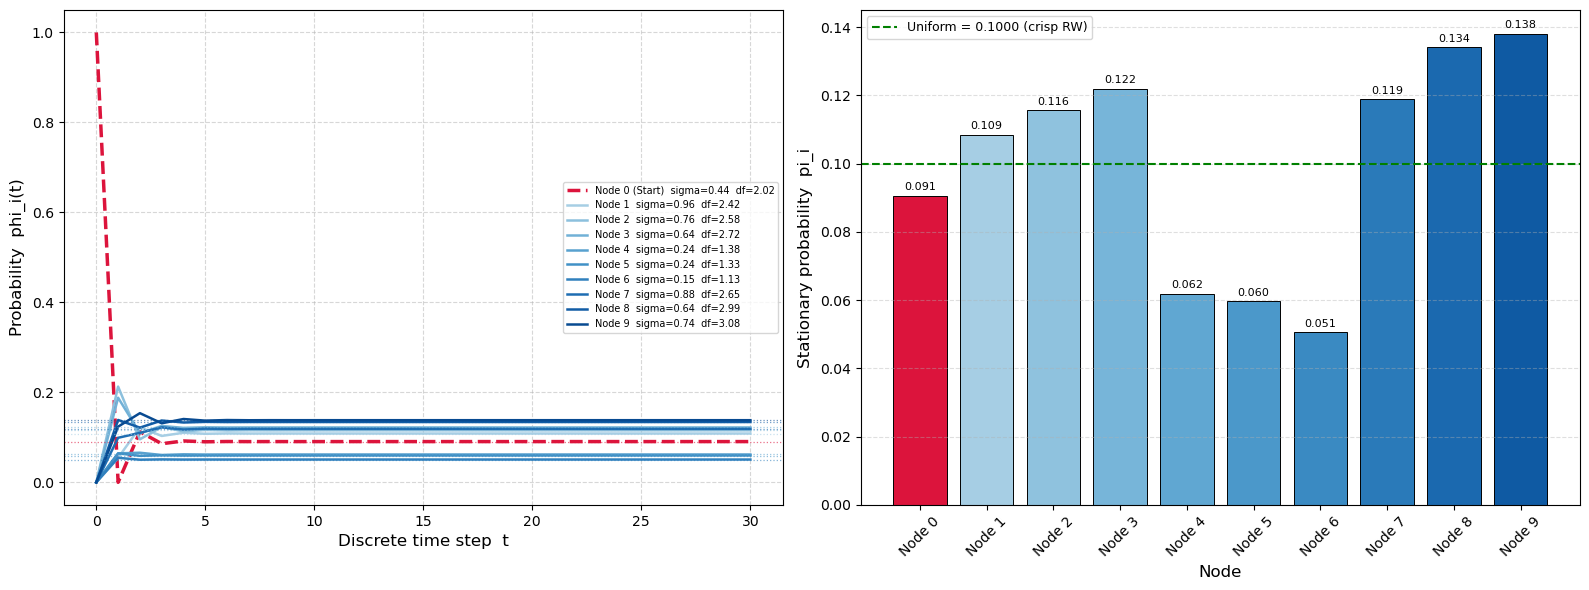


              RANDOM WALK SUMMARY
Network      : Fuzzy Complete K10  (10 nodes)
Model        : Fuzzy random walk - Section 3.5
Transition   : P_ij = mu(i,j) / df(i)  [Eq. 3.5.2]
Start node   : Node 0,  phi(0) = 1.0
Steps run    : 30

Final state phi(30) vs stationary pi:
  Node 0: phi(30)=0.0906  pi=0.0906  diff=0.000000
  Node 1: phi(30)=0.1085  pi=0.1085  diff=0.000000
  Node 2: phi(30)=0.1157  pi=0.1157  diff=0.000000
  Node 3: phi(30)=0.1220  pi=0.1220  diff=0.000000
  Node 4: phi(30)=0.0619  pi=0.0619  diff=0.000000
  Node 5: phi(30)=0.0596  pi=0.0596  diff=0.000000
  Node 6: phi(30)=0.0507  pi=0.0507  diff=0.000000
  Node 7: phi(30)=0.1188  pi=0.1188  diff=0.000000
  Node 8: phi(30)=0.1341  pi=0.1341  diff=0.000000
  Node 9: phi(30)=0.1381  pi=0.1381  diff=0.000000

Key observations:
  * Unlike crisp RW (uniform stationary dist), fuzzy RW
    converges to pi_i proportional to fuzzy degree df(i).
  * Highly connected nodes (high df) are visited most often.
  * The walker mixes ra

In [45]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ── Parameters ────────────────────────────────────────────────────────────────
# Fuzzy Random Walk on K10: Section 3.5
# Transition matrix: P_ij = mu(i,j) / sum_k mu(i,k)   -- Equation (3.5.2)
# State update:      phi(t+1) = P * phi(t)             -- Section 3.5
NUM_NODES = 10
T_STEPS   = 30

# ── Step 1: Rebuild the same Fuzzy K10 (seed=42) ─────────────────────────────
G = nx.Graph()

np.random.seed(42)
for node in range(NUM_NODES):
    sigma = round(np.random.uniform(0.1, 1.0), 2)
    G.add_node(node, sigma=sigma)

for u in range(NUM_NODES):
    for v in range(u + 1, NUM_NODES):
        sigma_u = G.nodes[u]['sigma']
        sigma_v = G.nodes[v]['sigma']
        max_mu  = min(sigma_u, sigma_v)
        mu      = round(np.random.uniform(0.1, max_mu), 2)
        G.add_edge(u, v, mu=mu)

n     = G.number_of_nodes()
nodes = list(G.nodes())
idx   = {node: i for i, node in enumerate(nodes)}

# ── Step 2: Build Fuzzy Transition Matrix P -- Equation (3.5.2) ──────────────
# P_ij = mu(i,j) / df(i)   where df(i) = sum_k mu(i,k)
# This ensures each row sums to 1 (row-stochastic)
P = np.zeros((n, n))
for i in range(n):
    node_i = nodes[i]
    df_i   = sum(G[node_i][nb]['mu'] for nb in G.neighbors(node_i))
    for nb in G.neighbors(node_i):
        j      = idx[nb]
        P[i][j] = G[node_i][nb]['mu'] / df_i

# ── Step 3: Print network and transition matrix info ──────────────────────────
print('=' * 55)
print('   FUZZY RANDOM WALK ON K10  -  Section 3.5')
print('=' * 55)
print('Model : phi(t+1) = P * phi(t)')
print('        P_ij = mu(i,j) / df(i)   [Equation 3.5.2]')
print('        df(i) = sum_k mu(i,k)    [Equation 3.5.1]')

print('\nNode memberships sigma and fuzzy degrees df:')
for nd in nodes:
    df = round(sum(G[nd][nb]['mu'] for nb in G.neighbors(nd)), 2)
    print(f'  Node {nd}: sigma={G.nodes[nd]["sigma"]}  df={df}')

print('\nFuzzy Transition Matrix P (row = from, col = to):')
print(np.round(P, 3))
print(f'\nRow sums (must all = 1): {np.round(P.sum(axis=1), 6)}')

# Stationary distribution: pi_i proportional to df(i)
df_all  = np.array([sum(G[nd][nb]['mu'] for nb in G.neighbors(nd)) for nd in nodes])
pi      = df_all / df_all.sum()
print(f'\nTheoretical stationary distribution pi_i = df(i) / sum(df):')
for nd in nodes:
    print(f'  Node {nd}: pi = {pi[idx[nd]]:.4f}  (df={round(df_all[idx[nd]],2)})')

# ── Step 4: Initial Conditions ────────────────────────────────────────────────
# Walker starts at Node 0 with probability 1
phi = np.zeros(n)
phi[idx[0]] = 1.0
print(f'\nInitial state phi(0): {phi}')

# ── Step 5: Simulate Fuzzy Random Walk ───────────────────────────────────────
# phi(t+1) = P^T * phi(t)
# We use P^T because phi is a column vector of probabilities:
# phi_j(t+1) = sum_i P_ij * phi_i(t)
history    = np.zeros((T_STEPS + 1, n))
history[0] = phi.copy()

for t in range(T_STEPS):
    phi        = P.T @ phi
    history[t+1] = phi.copy()

# ── Step 6: Plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---- Left: Random walk probability trajectories ----
ax = axes[0]
ax.plot(range(T_STEPS + 1), history[:, idx[0]],
        label=f"Node 0 (Start)  sigma={G.nodes[0]['sigma']}  df={round(df_all[0],2)}",
        color='crimson', linewidth=2.5, linestyle='--')

colors = cm.Blues(np.linspace(0.35, 0.9, NUM_NODES - 1))
for i in range(1, NUM_NODES):
    nd   = nodes[i]
    df_i = round(df_all[idx[nd]], 2)
    ax.plot(range(T_STEPS + 1), history[:, i],
            label=f"Node {nd}  sigma={G.nodes[nd]['sigma']}  df={df_i}",
            color=colors[i - 1], linewidth=1.8)

# Plot stationary distribution as horizontal dotted lines
for i, nd in enumerate(nodes):
    c = 'crimson' if nd == 0 else colors[i - 1] if i > 0 else 'crimson'
    ax.axhline(y=pi[idx[nd]], color=c, linestyle=':', linewidth=0.9, alpha=0.6)

ax.set_xlabel('Discrete time step  t', fontsize=12)
ax.set_ylabel('Probability  phi_i(t)', fontsize=12)
#ax.set_title(
    #'Fuzzy Random Walk on Fuzzy K10  -  Section 3.5\n'
    #'phi(t+1) = P·phi(t),  P_ij = mu(i,j)/df(i)  |  Start: Node 0',
    #fontsize=11)
ax.legend(fontsize=7, loc='right')
ax.grid(True, linestyle='--', alpha=0.5)

# ---- Right: Stationary distribution bar chart ----
ax2 = axes[1]
bar_colors = ['crimson'] + [cm.Blues(0.35 + 0.55 * i / (NUM_NODES - 1))
                              for i in range(NUM_NODES - 1)]
bars = ax2.bar([f"Node {nd}" for nd in nodes], pi, color=bar_colors,
               edgecolor='black', linewidth=0.7)
ax2.axhline(y=1/n, color='green', linestyle='--', linewidth=1.5,
            label=f'Uniform = {1/n:.4f} (crisp RW)')
for bar, val in zip(bars, pi):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8)
ax2.set_xlabel('Node', fontsize=12)
ax2.set_ylabel('Stationary probability  pi_i', fontsize=12)
#ax2.set_title(
   # 'Stationary Distribution of Fuzzy Random Walk\n'
   # 'pi_i = df(i) / sum(df)  |  Highly connected nodes visited most',
    #fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.4, axis='y')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('Fuzzy_RandomWalk_K10.pdf', dpi=150, bbox_inches='tight', format='pdf')
plt.show()

# ── Step 7: Summary ───────────────────────────────────────────────────────────
print(f'\n{"=" * 55}')
print('              RANDOM WALK SUMMARY')
print(f'{"=" * 55}')
print(f'Network      : Fuzzy Complete K{NUM_NODES}  ({n} nodes)')
print('Model        : Fuzzy random walk - Section 3.5')
print('Transition   : P_ij = mu(i,j) / df(i)  [Eq. 3.5.2]')
print('Start node   : Node 0,  phi(0) = 1.0')
print(f'Steps run    : {T_STEPS}')

print(f'\nFinal state phi({T_STEPS}) vs stationary pi:')
for nd in nodes:
    i = idx[nd]
    print(f'  Node {nd}: phi({T_STEPS})={history[-1,i]:.4f}  '
          f'pi={pi[i]:.4f}  diff={abs(history[-1,i]-pi[i]):.6f}')

print('\nKey observations:')
print('  * Unlike crisp RW (uniform stationary dist), fuzzy RW')
print('    converges to pi_i proportional to fuzzy degree df(i).')
print('  * Highly connected nodes (high df) are visited most often.')
print('  * The walker mixes rapidly on K10 due to full connectivity.')
print('  * Transition probabilities reflect fuzzy tie strengths --')
print('    stronger edges are traversed more frequently.')

## Random Walk on a Crisp K10

         CLASSICAL RANDOM WALK ON K10
Model : phi(t+1) = P * phi(t)
Transition probabilities:
        P_ij = 1 / deg(i)

Node degrees:
  Node 0: degree = 9
  Node 1: degree = 9
  Node 2: degree = 9
  Node 3: degree = 9
  Node 4: degree = 9
  Node 5: degree = 9
  Node 6: degree = 9
  Node 7: degree = 9
  Node 8: degree = 9
  Node 9: degree = 9

Transition Matrix P:
[[0.    0.111 0.111 0.111 0.111 0.111 0.111 0.111 0.111 0.111]
 [0.111 0.    0.111 0.111 0.111 0.111 0.111 0.111 0.111 0.111]
 [0.111 0.111 0.    0.111 0.111 0.111 0.111 0.111 0.111 0.111]
 [0.111 0.111 0.111 0.    0.111 0.111 0.111 0.111 0.111 0.111]
 [0.111 0.111 0.111 0.111 0.    0.111 0.111 0.111 0.111 0.111]
 [0.111 0.111 0.111 0.111 0.111 0.    0.111 0.111 0.111 0.111]
 [0.111 0.111 0.111 0.111 0.111 0.111 0.    0.111 0.111 0.111]
 [0.111 0.111 0.111 0.111 0.111 0.111 0.111 0.    0.111 0.111]
 [0.111 0.111 0.111 0.111 0.111 0.111 0.111 0.111 0.    0.111]
 [0.111 0.111 0.111 0.111 0.111 0.111 0.111 0.111 0.111 0.   ]]

R

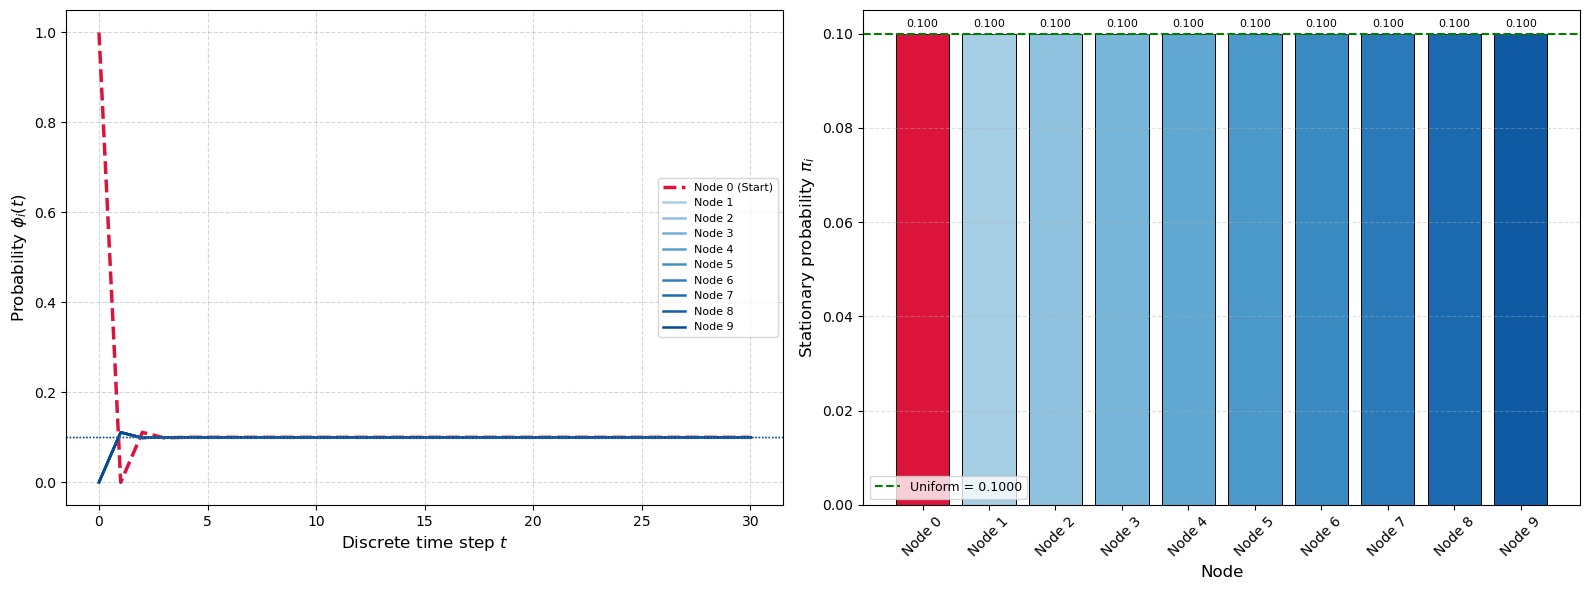


                RANDOM WALK SUMMARY
Network      : Classical Complete Graph K10
Nodes        : 10
Model        : Classical random walk
Transition   : P_ij = 1 / deg(i)
Start node   : Node 0
Steps run    : 30

Final state phi(30) vs stationary pi:
  Node 0: phi(30)=0.1000   pi=0.1000   diff=0.000000
  Node 1: phi(30)=0.1000   pi=0.1000   diff=0.000000
  Node 2: phi(30)=0.1000   pi=0.1000   diff=0.000000
  Node 3: phi(30)=0.1000   pi=0.1000   diff=0.000000
  Node 4: phi(30)=0.1000   pi=0.1000   diff=0.000000
  Node 5: phi(30)=0.1000   pi=0.1000   diff=0.000000
  Node 6: phi(30)=0.1000   pi=0.1000   diff=0.000000
  Node 7: phi(30)=0.1000   pi=0.1000   diff=0.000000
  Node 8: phi(30)=0.1000   pi=0.1000   diff=0.000000
  Node 9: phi(30)=0.1000   pi=0.1000   diff=0.000000

Key observations:
  * All nodes in K10 have identical degree.
  * The stationary distribution is uniform.
  * The walker converges rapidly to 1/10 at every node.
  * Symmetry of K10 produces identical long-term behavior.


In [48]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ── Parameters ────────────────────────────────────────────────────────────────
# Classical Random Walk on Complete Graph K10
# Transition matrix:
# P_ij = 1 / deg(i)    if (i,j) are adjacent
#
# State update:
# phi(t+1) = P^T * phi(t)

NUM_NODES = 10
T_STEPS   = 30

# ── Step 1: Build Classical Complete Graph K10 ───────────────────────────────
G = nx.complete_graph(NUM_NODES)

n     = G.number_of_nodes()
nodes = list(G.nodes())
idx   = {node: i for i, node in enumerate(nodes)}

# ── Step 2: Build Classical Transition Matrix P ──────────────────────────────
# Since K10 is complete:
# deg(i) = 9 for all nodes
#
# P_ij = 1/9 for i ≠ j
# P_ii = 0

P = np.zeros((n, n))

for i in range(n):

    node_i = nodes[i]
    deg_i  = G.degree(node_i)

    for nb in G.neighbors(node_i):

        j = idx[nb]
        P[i][j] = 1 / deg_i

# ── Step 3: Print Transition Matrix Information ──────────────────────────────
print('=' * 60)
print('         CLASSICAL RANDOM WALK ON K10')
print('=' * 60)

print('Model : phi(t+1) = P * phi(t)')
print('Transition probabilities:')
print('        P_ij = 1 / deg(i)')

print('\nNode degrees:')
for nd in nodes:
    print(f'  Node {nd}: degree = {G.degree(nd)}')

print('\nTransition Matrix P:')
print(np.round(P, 3))

print(f'\nRow sums (must all = 1):')
print(np.round(P.sum(axis=1), 6))

# ── Step 4: Stationary Distribution ───────────────────────────────────────────
# For classical complete graph:
# pi_i = deg(i) / sum(deg)
#
# Since all degrees are equal:
# pi_i = 1/n

deg_all = np.array([G.degree(nd) for nd in nodes])

pi = deg_all / deg_all.sum()

print('\nTheoretical stationary distribution:')
for nd in nodes:
    print(f'  Node {nd}: pi = {pi[idx[nd]]:.4f}')

# ── Step 5: Initial State ─────────────────────────────────────────────────────
# Start walker at Node 0

phi = np.zeros(n)
phi[idx[0]] = 1.0

print(f'\nInitial state phi(0):')
print(phi)

# ── Step 6: Simulate Classical Random Walk ───────────────────────────────────
history = np.zeros((T_STEPS + 1, n))
history[0] = phi.copy()

for t in range(T_STEPS):

    phi = P.T @ phi
    history[t + 1] = phi.copy()

# ── Step 7: Plotting ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ============================================================================
# LEFT PLOT: Probability Evolution
# ============================================================================
ax = axes[0]

ax.plot(
    range(T_STEPS + 1),
    history[:, idx[0]],
    label='Node 0 (Start)',
    color='crimson',
    linewidth=2.5,
    linestyle='--'
)

colors = cm.Blues(np.linspace(0.35, 0.9, NUM_NODES - 1))

for i in range(1, NUM_NODES):

    nd = nodes[i]

    ax.plot(
        range(T_STEPS + 1),
        history[:, i],
        label=f'Node {nd}',
        color=colors[i - 1],
        linewidth=1.8
    )

# Stationary distribution lines
for i, nd in enumerate(nodes):

    if nd == 0:
        c = 'crimson'
    else:
        c = colors[i - 1]

    ax.axhline(
        y=pi[idx[nd]],
        color=c,
        linestyle=':',
        linewidth=0.9,
        alpha=0.6
    )

ax.set_xlabel('Discrete time step $t$', fontsize=12)
ax.set_ylabel(r'Probability $\phi_i(t)$', fontsize=12)

#ax.set_title(
    #'Classical Random Walk on Complete Graph $K_{10}$\n'
    #r'$\phi(t+1)=P^T\phi(t)$',
    #fontsize=12
#)

ax.legend(fontsize=8, loc='right')

ax.grid(True, linestyle='--', alpha=0.5)

# ============================================================================
# RIGHT PLOT: Stationary Distribution
# ============================================================================
ax2 = axes[1]

bar_colors = (
    ['crimson'] +
    [cm.Blues(0.35 + 0.55 * i / (NUM_NODES - 1))
     for i in range(NUM_NODES - 1)]
)

bars = ax2.bar(
    [f'Node {nd}' for nd in nodes],
    pi,
    color=bar_colors,
    edgecolor='black',
    linewidth=0.7
)

# Uniform distribution reference line
ax2.axhline(
    y=1/n,
    color='green',
    linestyle='--',
    linewidth=1.5,
    label=f'Uniform = {1/n:.4f}'
)

# Add values on bars
for bar, val in zip(bars, pi):

    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.001,
        f'{val:.3f}',
        ha='center',
        va='bottom',
        fontsize=8
    )

ax2.set_xlabel('Node', fontsize=12)
ax2.set_ylabel(r'Stationary probability $\pi_i$', fontsize=12)

#ax2.set_title(
   # 'Stationary Distribution of Classical Random Walk',
    #fontsize=12
#)

ax2.legend(fontsize=9)

ax2.grid(
    True,
    linestyle='--',
    alpha=0.4,
    axis='y'
)

plt.xticks(rotation=45)

plt.tight_layout()

# ── Save Figure ───────────────────────────────────────────────────────────────
plt.savefig(
    'Classical_RandomWalk_K10.pdf',
    dpi=300,
    bbox_inches='tight',
    format='pdf'
)

plt.show()

# ── Step 8: Summary ───────────────────────────────────────────────────────────
print(f'\n{"=" * 60}')
print('                RANDOM WALK SUMMARY')
print(f'{"=" * 60}')

print(f'Network      : Classical Complete Graph K{NUM_NODES}')
print(f'Nodes        : {n}')
print('Model        : Classical random walk')
print('Transition   : P_ij = 1 / deg(i)')
print('Start node   : Node 0')
print(f'Steps run    : {T_STEPS}')

print(f'\nFinal state phi({T_STEPS}) vs stationary pi:')

for nd in nodes:

    i = idx[nd]

    print(
        f'  Node {nd}: '
        f'phi({T_STEPS})={history[-1, i]:.4f}   '
        f'pi={pi[i]:.4f}   '
        f'diff={abs(history[-1, i] - pi[i]):.6f}'
    )

print('\nKey observations:')
print('  * All nodes in K10 have identical degree.')
print('  * The stationary distribution is uniform.')
print('  * The walker converges rapidly to 1/10 at every node.')
print('  * Symmetry of K10 produces identical long-term behavior.')

# 8. The Karate Club Network

Node Degree
   0     16
   1      9
   2     10
   3      6
   4      3
   5      4
   6      4
   7      4
   8      5
   9      2
  10      3
  11      1
  12      2
  13      5
  14      2
  15      2
  16      2
  17      2
  18      2
  19      3
  20      2
  21      2
  22      2
  23      5
  24      3
  25      3
  26      2
  27      4
  28      3
  29      4
  30      4
  31      6
  32     12
  33     17


C:\Users\User.DESKTOP-9OREEMB\AppData\Local\Temp\ipykernel_3424\3722777236.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


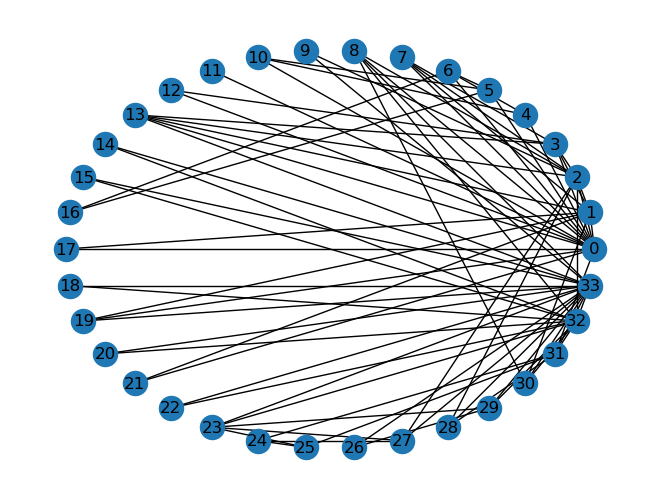

In [27]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.karate_club_graph()
print("Node Degree")
for v in G:
    print(f"{v:4} {G.degree(v):6}")

nx.draw_circular(G, with_labels=True)
plt.tight_layout()
plt.savefig("Zachary,s karate club.pdf", dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# Diffusion on the Crisp Karat club Network

     CRISP DIFFUSION — ZACHARY'S KARATE CLUB

  Nodes : 34   |   Edges : 78
  Source : Node 0  (degree 16, Instructor faction)

Node  Club         Degree
   0   Mr. Hi       16
   1   Mr. Hi       9
   2   Mr. Hi       10
   3   Mr. Hi       6
   4   Mr. Hi       3
   5   Mr. Hi       4
   6   Mr. Hi       4
   7   Mr. Hi       4
   8   Mr. Hi       5
   9   Officer      2
  10   Mr. Hi       3
  11   Mr. Hi       1
  12   Mr. Hi       2
  13   Mr. Hi       5
  14   Officer      2
  15   Officer      2
  16   Mr. Hi       2
  17   Mr. Hi       2
  18   Officer      2
  19   Mr. Hi       3
  20   Officer      2
  21   Mr. Hi       2
  22   Officer      2
  23   Officer      5
  24   Officer      3
  25   Officer      3
  26   Officer      2
  27   Officer      4
  28   Officer      3
  29   Officer      4
  30   Officer      4
  31   Officer      6
  32   Officer      12
  33   Officer      17

Laplacian matrix L built (34×34).
  Algebraic connectivity λ₂ = 1.1871  (> 0 ⟹ connected)

  

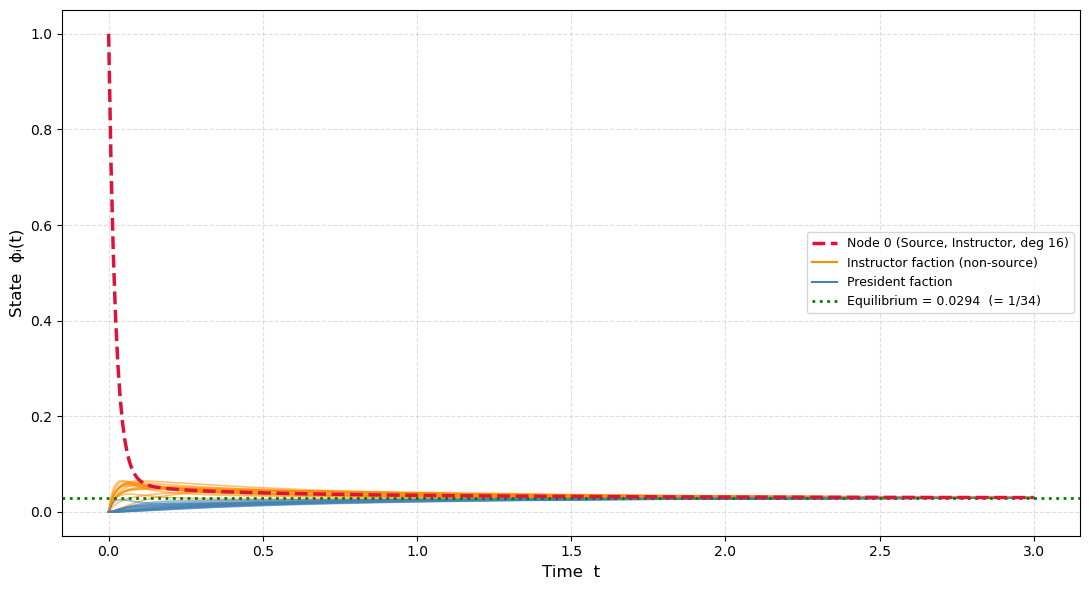

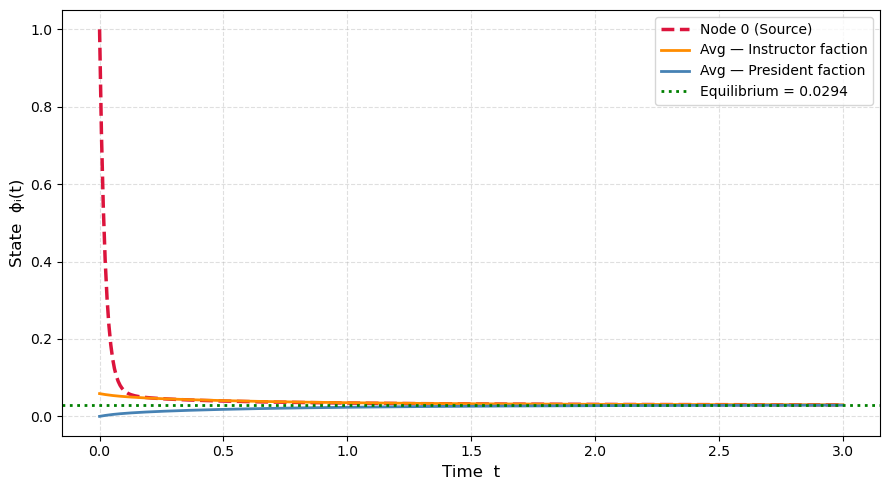

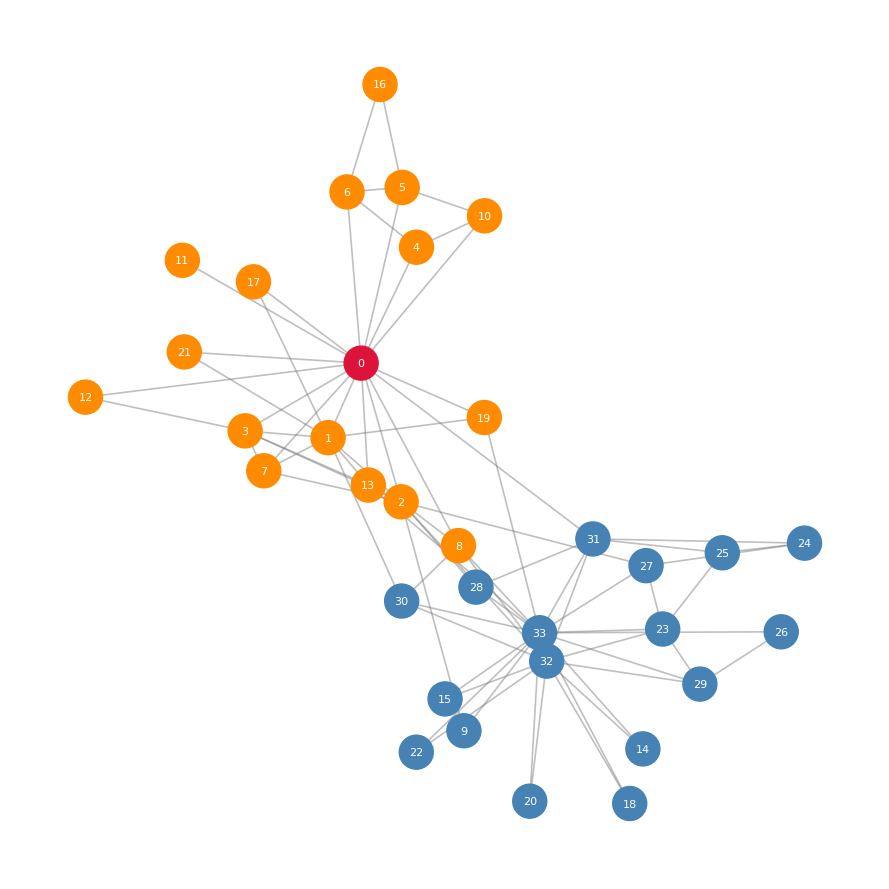


        CRISP DIFFUSION SUMMARY
  Network     : Zachary's Karate Club  (34 nodes, 78 edges)
  Source      : Node 0  (degree 16, Mr. Hi)
  C           : 1.0    T_end : 3
  Equilibrium : 0.0294  (= 1/34)

  Final states ϕᵢ(t = 3):
   Node        Club  Degree     ϕᵢ(T)
  --------------------------------------
      0      Mr. Hi      16  0.0298
      1      Mr. Hi       9  0.0296
      2      Mr. Hi      10  0.0295
      3      Mr. Hi       6  0.0297
      4      Mr. Hi       3  0.0303
      5      Mr. Hi       4  0.0304
      6      Mr. Hi       4  0.0304
      7      Mr. Hi       4  0.0296
      8      Mr. Hi       5  0.0292
      9     Officer       2  0.0290
     10      Mr. Hi       3  0.0304
     11      Mr. Hi       1  0.0301
     12      Mr. Hi       2  0.0299
     13      Mr. Hi       5  0.0295
     14     Officer       2  0.0288
     15     Officer       2  0.0289
     16      Mr. Hi       2  0.0307
     17      Mr. Hi       2  0.0300
     18     Officer       2  0.0287
     19

In [49]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.linalg import expm

# ── Parameters ─────────────────────────────────────────────────────────────────
C        = 1.0      # diffusion constant
T_END    = 3
N_STEPS  = 400

# ── Step 1: Load Zachary's Karate Club Network ─────────────────────────────────
# nx.karate_club_graph() returns the 34-node, 78-edge social network studied
# by Wayne Zachary (1977). Nodes are labelled 0–33. Every edge is binary
# (weight = 1) — a classical crisp network.

G     = nx.karate_club_graph()
n     = G.number_of_nodes()
nodes = list(G.nodes())
idx   = {v: i for i, v in enumerate(nodes)}
clubs = nx.get_node_attributes(G, 'club')   # 'Mr. Hi' or 'Officer'

print("=" * 60)
print("     CRISP DIFFUSION — ZACHARY'S KARATE CLUB")
print("=" * 60)
print(f"\n  Nodes : {n}   |   Edges : {G.number_of_edges()}")
print(f"  Source : Node 0  (degree {G.degree(0)}, Instructor faction)\n")
print("Node  Club         Degree")
for v in G:
    print(f"  {v:2}   {clubs[v]:10}   {G.degree(v)}")

# ── Step 2: Build Classical Matrices A, D, L ───────────────────────────────────
# A — binary adjacency matrix
# D — diagonal degree matrix
# L = D - A — classical Laplacian (Section 2.3.5 of essay)

A = np.array(nx.adjacency_matrix(G).todense(), dtype=float)
D = np.diag(A.sum(axis=1))
L = D - A

print("\nLaplacian matrix L built (34×34).")
print(f"  Algebraic connectivity λ₂ = "
      f"{sorted(np.linalg.eigvalsh(L))[1]:.4f}  (> 0 ⟹ connected)")

# ── Step 3: Initial Conditions ϕ(0) ───────────────────────────────────────────
# Node 0 (Mr. Hi — highest-degree hub) carries all the heat at t = 0.
# Theorem 3.3.2: equilibrium = mean of initial values = 1/n

phi0         = np.zeros(n)
phi0[idx[0]] = 1.0
equilibrium  = phi0.sum() / n

print(f"\n  ϕ(0)        : Node 0 = 1.0, all others = 0.0")
print(f"  Equilibrium : {equilibrium:.4f}  (= 1/{n})")

# ── Step 4: Simulate ϕ(t) = e^{-CtL} ϕ(0) ────────────────────────────────────
times    = np.linspace(0, T_END, N_STEPS)
phi_t    = np.zeros((N_STEPS, n))

for k, t in enumerate(times):
    phi_t[k] = expm(-C * t * L) @ phi0

# ── Step 5: Plot 1 — All Diffusion Curves ─────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(11, 6))

ax1.plot(times, phi_t[:, idx[0]],
         color='crimson', lw=2.5, ls='--',
         label='Node 0 (Source, Instructor, deg 16)', zorder=5)

# colour remaining nodes by faction
for v in nodes[1:]:
    col = 'steelblue' if clubs[v] == 'Officer' else 'darkorange'
    ax1.plot(times, phi_t[:, idx[v]],
             color=col, lw=1.2, alpha=0.55)

# proxy legend entries for factions
ax1.plot([], [], color='darkorange', lw=1.5, label='Instructor faction (non-source)')
ax1.plot([], [], color='steelblue',  lw=1.5, label='President faction')

ax1.axhline(equilibrium, color='green', ls=':', lw=2,
            label=f'Equilibrium = {equilibrium:.4f}  (= 1/{n})')

ax1.set_xlabel('Time  t', fontsize=12)
ax1.set_ylabel('State  ϕᵢ(t)', fontsize=12)
#ax1.set_title("Crisp Diffusion on Zachary's Karate Club Network\n"
             # "ϕ(t) = e^{−tCL} ϕ(0)  |  Source: Node 0  |  C = 1.0",
             # fontsize=13)
ax1.legend(fontsize=9, loc='right')
ax1.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("Crisp_Karate_Diffusion_Curves.pdf",
            dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# ── Step 6: Plot 2 — Faction Average Comparison ───────────────────────────────
mrhi_idx    = [idx[v] for v in nodes if clubs[v] == 'Mr. Hi']
officer_idx = [idx[v] for v in nodes if clubs[v] == 'Officer']

avg_mrhi    = phi_t[:, mrhi_idx].mean(axis=1)
avg_officer = phi_t[:, officer_idx].mean(axis=1)

fig2, ax2 = plt.subplots(figsize=(9, 5))
ax2.plot(times, phi_t[:, idx[0]],
         color='crimson', lw=2.5, ls='--', label='Node 0 (Source)')
ax2.plot(times, avg_mrhi,
         color='darkorange', lw=2, label='Avg — Instructor faction')
ax2.plot(times, avg_officer,
         color='steelblue',  lw=2, label='Avg — President faction')
ax2.axhline(equilibrium, color='green', ls=':', lw=2,
            label=f'Equilibrium = {equilibrium:.4f}')
ax2.set_xlabel('Time  t', fontsize=12)
ax2.set_ylabel('State  ϕᵢ(t)', fontsize=12)
#ax2.set_title("Crisp Zachary's Karate Club Network Diffusion — Faction Averages\n"
              #"Source: Node 0", fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("Crisp_Karate_Faction_Averages.pdf",
            dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# ── Step 7: Plot 3 — Network Diagram ──────────────────────────────────────────
pos = nx.spring_layout(G, seed=42)
node_colors = ['crimson' if v == 0
               else ('darkorange' if clubs[v] == 'Mr. Hi' else 'steelblue')
               for v in G.nodes()]

fig3, ax3 = plt.subplots(figsize=(9, 9))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=600, ax=ax3)
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1.2, alpha=0.5, ax=ax3)
nx.draw_networkx_labels(G, pos, font_size=8, font_color='white', ax=ax3)
#x3.set_title("Zachary's Karate Club Crisp Network\n"
             # "Crimson = Node 0 (source)  |  "
              #"Orange = Instructor  |  Blue = President",
              #fontsize=11)
ax3.axis('off')
plt.tight_layout()
plt.savefig("Crisp_Karate_Network.pdf",
            dpi=150, bbox_inches="tight", format='pdf')
plt.show()

# ── Step 9: Summary ────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"        CRISP DIFFUSION SUMMARY")
print(f"{'='*60}")
print(f"  Network     : Zachary's Karate Club  ({n} nodes, {G.number_of_edges()} edges)")
print(f"  Source      : Node 0  (degree {G.degree(0)}, Mr. Hi)")
print(f"  C           : {C}    T_end : {T_END}")
print(f"  Equilibrium : {equilibrium:.4f}  (= 1/{n})")
print(f"\n  Final states ϕᵢ(t = {T_END}):")
print(f"  {'Node':>5}  {'Club':>10}  {'Degree':>6}  {'ϕᵢ(T)':>8}")
print(f"  {'-'*38}")
for v in nodes:
    print(f"  {v:>5}  {clubs[v]:>10}  {G.degree(v):>6}  {phi_t[-1, idx[v]]:.4f}")
print(f"\n  Key Observation:")
print(f"  All {n-1} non-source nodes converge identically to {equilibrium:.4f}.")
print(f"  This uniform behaviour is the symmetry limitation of the crisp model.")

# Diffusion on the Fuzzy Karat club Network

   FUZZY DIFFUSION (Rosenfeld) — ZACHARY'S KARATE CLUB

  Nodes : 34   |   Edges : 78
  Source : Node 0  (degree 16, Mr. Hi faction)

  Rosenfeld constraint check: 78 edges, 0 violations  ✓ PASSED

   Node        Club   deg    σ(v)    df(v)  Valid σ(v)∧σ(nbr) ≥ all μ
  -----------------------------------------------------------------
      0      Mr. Hi    16  0.9412   2.6329  ✓
      1      Mr. Hi     9  0.5294   1.6831  ✓
      2      Mr. Hi    10  0.5882   2.0704  ✓
      3      Mr. Hi     6  0.3529   0.9433  ✓
      4      Mr. Hi     3  0.1765   0.2144  ✓
      5      Mr. Hi     4  0.2353   0.3042  ✓
      6      Mr. Hi     4  0.2353   0.4602  ✓
      7      Mr. Hi     4  0.2353   0.5407  ✓
      8      Mr. Hi     5  0.2941   0.9173  ✓
      9     Officer     2  0.1176   0.1163  ✓
     10      Mr. Hi     3  0.1765   0.1300  ✓
     11      Mr. Hi     1  0.0588   0.0297  ✓
     12      Mr. Hi     2  0.1176   0.1020  ✓
     13      Mr. Hi     5  0.2941   0.9377  ✓
     14     Officer 

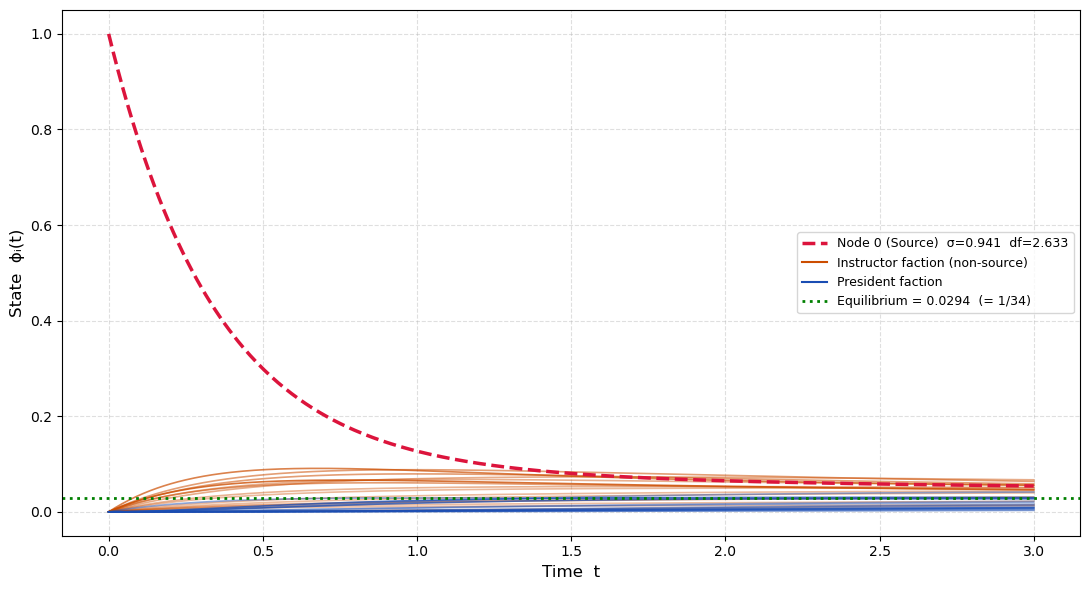

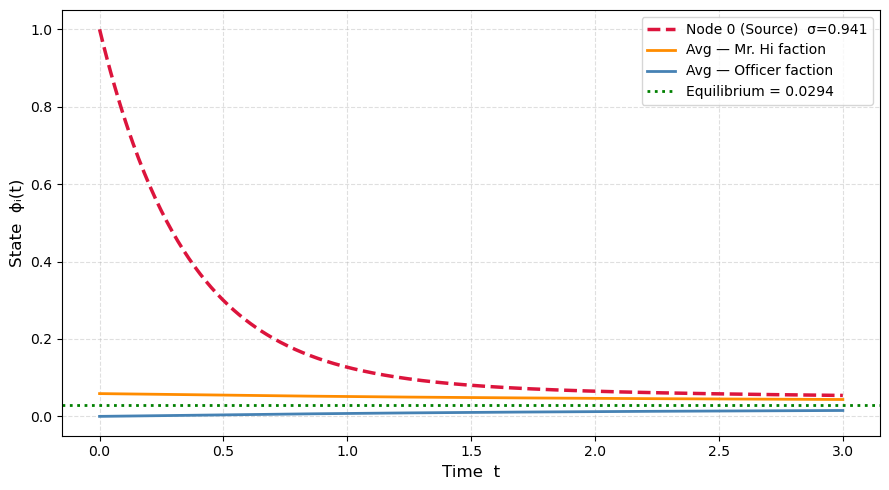

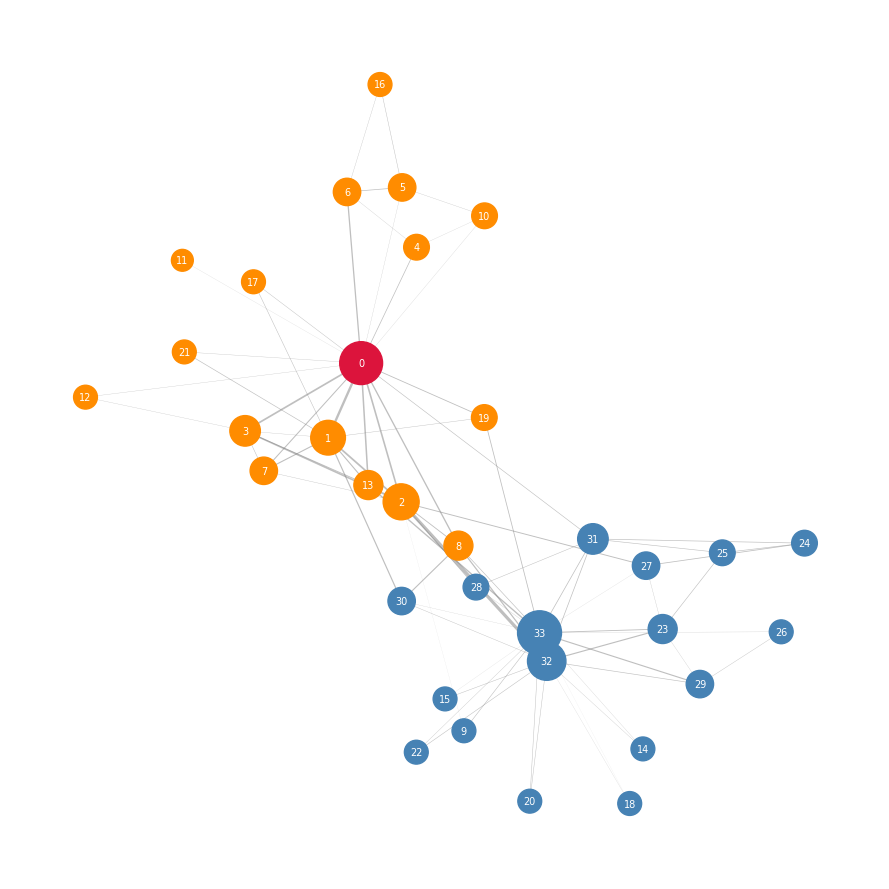


   ROSENFELD FUZZY DIFFUSION — SUMMARY
  Network     : Zachary's Karate Club  (34 nodes, 78 edges)
  Constraint  : μ(x,y) ≤ σ(x) ∧ σ(y)  (Rosenfeld, Def. 2.5.1)
  Source      : Node 0  (degree 16, Mr. Hi)
  T_end       : 3
  Equilibrium : 0.029412  (= 1/34,  Theorem 3.3.2)

  Final states ϕᵢ(t = 3):
   Node        Club   deg    σ(v)    df(v)     ϕᵢ(T)
  -------------------------------------------------------
      0      Mr. Hi    16  0.9412   2.6329  0.054088
      1      Mr. Hi     9  0.5294   1.6831  0.055746
      2      Mr. Hi    10  0.5882   2.0704  0.046253
      3      Mr. Hi     6  0.3529   0.9433  0.063725
      4      Mr. Hi     3  0.1765   0.2144  0.049984
      5      Mr. Hi     4  0.2353   0.3042  0.029414
      6      Mr. Hi     4  0.2353   0.4602  0.055418
      7      Mr. Hi     4  0.2353   0.5407  0.067008
      8      Mr. Hi     5  0.2941   0.9173  0.046332
      9     Officer     2  0.1176   0.1163  0.007491
     10      Mr. Hi     3  0.1765   0.1300  0.022108
    

In [50]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

# ── Parameters ─────────────────────────────────────────────────────────────────
T_END   = 3
N_STEPS = 400

# ── Step 1: Load Zachary's Karate Club Network ─────────────────────────────────
# 34-node, 78-edge social network (Zachary, 1977).
#
# ROSENFELD'S DEFINITION (Def. 2.5.1):
#   G = (V, σ, μ) where σ : V → [0,1] and μ : V×V → [0,1]
#   with the KEY CONSTRAINT  μ(x,y) ≤ σ(x) ∧ σ(y)  for all x,y ∈ V.
#
# This ensures every edge membership is bounded by the MINIMUM of the
# two endpoint vertex memberships — capturing the idea that a connection
# cannot be "stronger" than the weaker of the two nodes it links.

G     = nx.karate_club_graph()
n     = G.number_of_nodes()
nodes = list(G.nodes())
idx   = {v: i for i, v in enumerate(nodes)}
clubs = nx.get_node_attributes(G, 'club')   # 'Mr. Hi' or 'Officer'

print("=" * 65)
print("   FUZZY DIFFUSION (Rosenfeld) — ZACHARY'S KARATE CLUB")
print("=" * 65)
print(f"\n  Nodes : {n}   |   Edges : {G.number_of_edges()}")
print(f"  Source : Node 0  (degree {G.degree(0)}, Mr. Hi faction)\n")

# ── Step 2: Assign Node Memberships σ(v) ──────────────────────────────────────
# σ(v) = degree(v) / max_degree  ∈ (0, 1]
# Higher-degree nodes get higher membership (more central/influential).

rng     = np.random.default_rng(42)
max_deg = max(dict(G.degree()).values())
sigma   = {v: G.degree(v) / max_deg for v in G.nodes()}

# ── Step 3: Assign Edge Memberships μ(x,y) — ENFORCING Def. 2.5.1 ────────────
# For each edge (x,y) we draw  r ~ Uniform(0, 1)  and then set:
#   μ(x,y) = r · (σ(x) ∧ σ(y))
# so that μ(x,y) ∈ (0, σ(x)∧σ(y)] — the Rosenfeld constraint is satisfied
# by construction.  We also round to 2 d.p. for readability.

A_fuzzy = np.zeros((n, n))
edge_mu = {}

for u, v in G.edges():
    i, j    = idx[u], idx[v]
    upper   = min(sigma[u], sigma[v])          # σ(u) ∧ σ(v)
    r       = rng.uniform(0.1, 1.0)            # random fraction in [0.1, 1]
    mu      = round(r * upper, 4)              # μ ≤ σ(u) ∧ σ(v)  ✓
    A_fuzzy[i][j] = mu
    A_fuzzy[j][i] = mu                         # undirected → symmetric
    edge_mu[(u, v)] = mu

# ── Step 4: Verify Rosenfeld Constraint ───────────────────────────────────────
violations = 0
for (u, v), mu in edge_mu.items():
    upper = min(sigma[u], sigma[v])
    if mu > upper + 1e-9:                      # tolerance for float rounding
        print(f"  VIOLATION: edge ({u},{v})  μ={mu:.4f} > σ∧σ={upper:.4f}")
        violations += 1
print(f"  Rosenfeld constraint check: {len(edge_mu)} edges, "
      f"{violations} violations  {'✓ PASSED' if violations == 0 else '✗ FAILED'}\n")

# ── Step 5: Print Node Summary ────────────────────────────────────────────────
print(f"  {'Node':>5}  {'Club':>10}  {'deg':>4}  {'σ(v)':>6}  "
      f"{'df(v)':>7}  {'Valid σ(v)∧σ(nbr) ≥ all μ':>10}")
print(f"  {'-'*65}")
for v in nodes:
    df  = A_fuzzy[idx[v]].sum()
    # worst-case check: max edge μ for this node vs min σ∧σ over neighbours
    nbr_mins = [min(sigma[v], sigma[u]) for u in G.neighbors(v)]
    ok = all(edge_mu.get((min(v,u), max(v,u)),
                         edge_mu.get((u,v), 0)) <= min(sigma[v], sigma[u]) + 1e-9
             for u in G.neighbors(v))
    print(f"  {v:>5}  {clubs[v]:>10}  {G.degree(v):>4}  "
          f"{sigma[v]:.4f}  {df:>7.4f}  {'✓' if ok else '✗'}")

# ── Step 6: Build Fuzzy Laplacian Lf = Df - Af ────────────────────────────────
# (Sections 2.6.2 and 2.6.3 of the essay)

df_vec  = A_fuzzy.sum(axis=1)
D_fuzzy = np.diag(df_vec)
L_fuzzy = D_fuzzy - A_fuzzy

eigs = sorted(np.linalg.eigvalsh(L_fuzzy))
print(f"\n  Fuzzy Laplacian Lf  (34×34).")
print(f"  λ₁ = {eigs[0]:.8f}  (≈ 0 ✓)")
print(f"  λ₂ = {eigs[1]:.6f}  (> 0 ⟹ connected ✓)")

# ── Step 7: Initial Conditions ────────────────────────────────────────────────
# ϕ(0): unit heat at Node 0.  Theorem 3.3.2: equilibrium = 1/n.

phi0        = np.zeros(n)
phi0[idx[0]] = 1.0
equilibrium  = phi0.sum() / n

print(f"\n  ϕ(0)        : Node 0 = 1.0, all others = 0.0")
print(f"  Equilibrium : {equilibrium:.6f}  (= 1/{n},  Theorem 3.3.2)")

# ── Step 8: Simulate ϕ(t) = e^{-tLf} ϕ(0)  (Eq. 3.3.5) ─────────────────────

times = np.linspace(0, T_END, N_STEPS)
phi_t = np.zeros((N_STEPS, n))
for k, t in enumerate(times):
    phi_t[k] = expm(-t * L_fuzzy) @ phi0

# ── Step 9: Plot 1 — All Diffusion Curves ─────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(11, 6))

ax1.plot(times, phi_t[:, idx[0]],
         color='crimson', lw=2.5, ls='--',
         label=f'Node 0 (Source)  σ={sigma[0]:.3f}  df={df_vec[idx[0]]:.3f}',
         zorder=5)

max_df = df_vec.max()
for v in nodes[1:]:
    base  = (0.8, 0.3, 0.0) if clubs[v] == 'Mr. Hi' else (0.1, 0.3, 0.7)
    alpha = 0.35 + 0.55 * (df_vec[idx[v]] / max_df)
    ax1.plot(times, phi_t[:, idx[v]], color=base, lw=1.2, alpha=alpha)

ax1.plot([], [], color=(0.8, 0.3, 0.0), lw=1.5, label='Instructor faction (non-source)')
ax1.plot([], [], color=(0.1, 0.3, 0.7), lw=1.5, label='President faction')
ax1.axhline(equilibrium, color='green', ls=':', lw=2,
            label=f'Equilibrium = {equilibrium:.4f}  (= 1/{n})')

ax1.set_xlabel('Time  t', fontsize=12)
ax1.set_ylabel('State  ϕᵢ(t)', fontsize=12)
#ax1.set_title(
   # "Diffusion on Zachary's Karate Club Fuzzy Network  \n"
   # "ϕ(t) = e^{−tLf} ϕ(0)  |  Source: Node 0",
   # fontsize=12)
ax1.legend(fontsize=9, loc='right')
ax1.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("Fuzzy_Karate_Diffusion_Curves.pdf",
            dpi=150, bbox_inches='tight', format='pdf')
plt.show()

# ── Step 10: Plot 2 — Faction Averages ────────────────────────────────────────
mrhi_idx    = [idx[v] for v in nodes if clubs[v] == 'Mr. Hi']
officer_idx = [idx[v] for v in nodes if clubs[v] == 'Officer']
avg_mrhi    = phi_t[:, mrhi_idx].mean(axis=1)
avg_officer = phi_t[:, officer_idx].mean(axis=1)

fig2, ax2 = plt.subplots(figsize=(9, 5))
ax2.plot(times, phi_t[:, idx[0]],
         color='crimson', lw=2.5, ls='--',
         label=f'Node 0 (Source)  σ={sigma[0]:.3f}')
ax2.plot(times, avg_mrhi,    color='darkorange', lw=2,
         label='Avg — Mr. Hi faction')
ax2.plot(times, avg_officer, color='steelblue',  lw=2,
         label='Avg — Officer faction')
ax2.axhline(equilibrium, color='green', ls=':', lw=2,
            label=f'Equilibrium = {equilibrium:.4f}')
ax2.set_xlabel('Time  t', fontsize=12)
ax2.set_ylabel('State  ϕᵢ(t)', fontsize=12)
#ax2.set_title(
    #"Diffusion 0n Zachary's Karate Club Fuzzy Network — Faction Averages  \n"
    #"Source: Node 0", fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("Rosenfeld_Karate_Faction_Averages.pdf",
            dpi=150, bbox_inches='tight', format='pdf')
plt.show()

# ── Step 11: Plot 3 — Fuzzy Network Diagram ───────────────────────────────────
# Edge thickness ∝ μ(x,y);  node size ∝ σ(v)

pos         = nx.spring_layout(G, seed=42)
node_colors = ['crimson' if v == 0
               else ('darkorange' if clubs[v] == 'Mr. Hi' else 'steelblue')
               for v in G.nodes()]
node_sizes  = [200 + 800 * sigma[v] for v in G.nodes()]
edge_widths = [4 * edge_mu.get((min(u,v), max(u,v)),
                               edge_mu.get((v, u), 0.05))
               for u, v in G.edges()]

fig3, ax3 = plt.subplots(figsize=(9, 9))
nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                       node_size=node_sizes, ax=ax3)
nx.draw_networkx_edges(G, pos, edge_color='gray',
                       width=edge_widths, alpha=0.5, ax=ax3)
nx.draw_networkx_labels(G, pos, font_size=7, font_color='white', ax=ax3)
#ax3.set_title(
   # "Zachary's Karate Club Fuzzy Network\n"
   # "μ(x,y) ≤ σ(x) ∧ σ(y)  |  Node membership ∝ σ(v)  |  Edge strength ∝ μ(x,y)\n"
   # "Crimson = source  |  Orange = Instructor  |  Blue = President",
    #fontsize=10)
ax3.axis('off')
plt.tight_layout()
plt.savefig("Rosenfeld_Karate_Network.pdf",
            dpi=150, bbox_inches='tight', format='pdf')
plt.show()


# ── Step 13: Summary ──────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"   ROSENFELD FUZZY DIFFUSION — SUMMARY")
print(f"{'='*65}")
print(f"  Network     : Zachary's Karate Club  ({n} nodes, {G.number_of_edges()} edges)")
print(f"  Constraint  : μ(x,y) ≤ σ(x) ∧ σ(y)  (Rosenfeld, Def. 2.5.1)")
print(f"  Source      : Node 0  (degree {G.degree(0)}, Mr. Hi)")
print(f"  T_end       : {T_END}")
print(f"  Equilibrium : {equilibrium:.6f}  (= 1/{n},  Theorem 3.3.2)")
print(f"\n  Final states ϕᵢ(t = {T_END}):")
print(f"  {'Node':>5}  {'Club':>10}  {'deg':>4}  {'σ(v)':>6}  "
      f"{'df(v)':>7}  {'ϕᵢ(T)':>8}")
print(f"  {'-'*55}")
for v in nodes:
    print(f"  {v:>5}  {clubs[v]:>10}  {G.degree(v):>4}  "
          f"{sigma[v]:.4f}  {df_vec[idx[v]]:>7.4f}  "
          f"{phi_t[-1, idx[v]]:.6f}")

print(f"\n  Key observations (Rosenfeld model):")
print(f"  1. All edge weights μ(x,y) ≤ min(σ(x), σ(y)) — constraint satisfied.")
print(f"  2. Weaker σ nodes produce lower edge caps, slowing heat reaching them.")
print(f"  3. Mr. Hi nodes (structurally closer to Node 0) retain more heat.")
print(f"  4. The fuzzy Laplacian remains positive semi-definite; λ₁ ≈ 0, λ₂ > 0.")
print(f"  5. All nodes converge to 1/{n} = {equilibrium:.6f}  (Theorem 3.3.2).")

# Average factions Comparison between the Crisp and fuzzy Karate Club Network

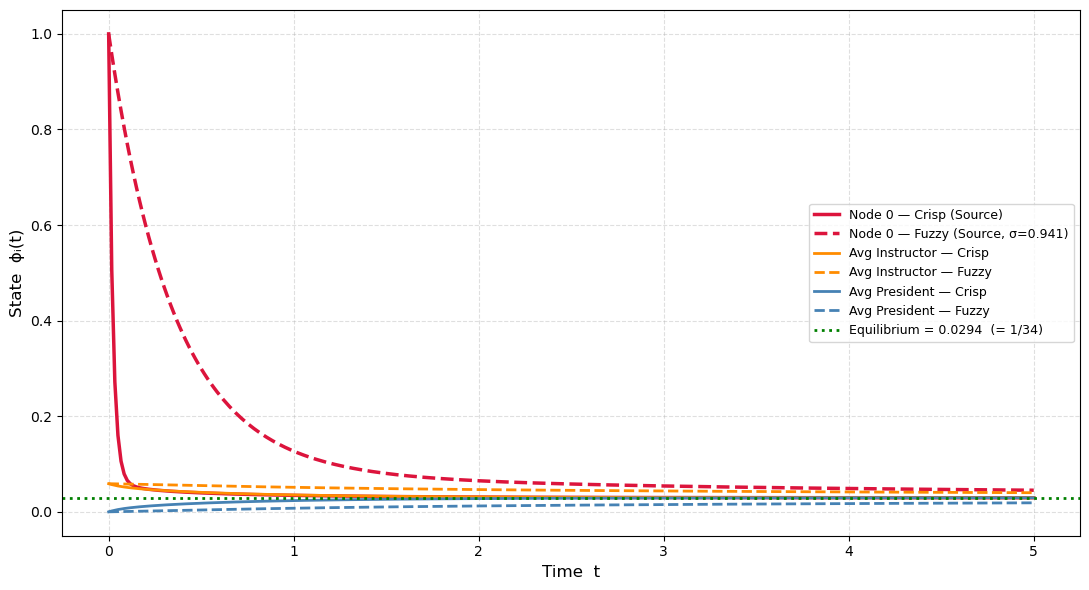

In [51]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

# ── Parameters ─────────────────────────────────────────────────────────────────
C       = 1.0
T_END   = 5
N_STEPS = 300

# ── Network Setup ──────────────────────────────────────────────────────────────
G     = nx.karate_club_graph()
n     = G.number_of_nodes()
nodes = list(G.nodes())
idx   = {v: i for i, v in enumerate(nodes)}
clubs = nx.get_node_attributes(G, 'club')

times       = np.linspace(0, T_END, N_STEPS)
phi0        = np.zeros(n);  phi0[idx[0]] = 1.0
equilibrium = phi0.sum() / n

mrhi_idx    = [idx[v] for v in nodes if clubs[v] == 'Mr. Hi']
officer_idx = [idx[v] for v in nodes if clubs[v] == 'Officer']

# ── CRISP ──────────────────────────────────────────────────────────────────────
A_crisp = np.array(nx.adjacency_matrix(G).todense(), dtype=float)
L_crisp = np.diag(A_crisp.sum(axis=1)) - A_crisp

phi_crisp = np.array([expm(-C * t * L_crisp) @ phi0 for t in times])

avg_mrhi_crisp    = phi_crisp[:, mrhi_idx].mean(axis=1)
avg_officer_crisp = phi_crisp[:, officer_idx].mean(axis=1)

# ── FUZZY (Rosenfeld) ──────────────────────────────────────────────────────────
rng     = np.random.default_rng(42)
max_deg = max(dict(G.degree()).values())
sigma   = {v: G.degree(v) / max_deg for v in G.nodes()}

A_fuzzy = np.zeros((n, n))
for u, v in G.edges():
    mu = round(rng.uniform(0.1, 1.0) * min(sigma[u], sigma[v]), 4)
    A_fuzzy[idx[u]][idx[v]] = A_fuzzy[idx[v]][idx[u]] = mu

L_fuzzy = np.diag(A_fuzzy.sum(axis=1)) - A_fuzzy

phi_fuzzy = np.array([expm(-t * L_fuzzy) @ phi0 for t in times])

avg_mrhi_fuzzy    = phi_fuzzy[:, mrhi_idx].mean(axis=1)
avg_officer_fuzzy = phi_fuzzy[:, officer_idx].mean(axis=1)

# ── Single Combined Plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

# Source nodes
ax.plot(times, phi_crisp[:, idx[0]],
        color='crimson', lw=2.5, ls='-',
        label='Node 0 — Crisp (Source)')
ax.plot(times, phi_fuzzy[:, idx[0]],
        color='crimson', lw=2.5, ls='--',
        label=f'Node 0 — Fuzzy (Source, σ={sigma[0]:.3f})')

# Mr. Hi faction averages
ax.plot(times, avg_mrhi_crisp,
        color='darkorange', lw=2, ls='-',
        label='Avg Instructor — Crisp')
ax.plot(times, avg_mrhi_fuzzy,
        color='darkorange', lw=2, ls='--',
        label='Avg Instructor — Fuzzy')

# Officer faction averages
ax.plot(times, avg_officer_crisp,
        color='steelblue', lw=2, ls='-',
        label='Avg President — Crisp')
ax.plot(times, avg_officer_fuzzy,
        color='steelblue', lw=2, ls='--',
        label='Avg President — Fuzzy')

# Equilibrium line
ax.axhline(equilibrium, color='green', ls=':', lw=2,
           label=f'Equilibrium = {equilibrium:.4f}  (= 1/{n})')

# Style
ax.set_xlabel('Time  t', fontsize=12)
ax.set_ylabel('State  ϕᵢ(t)', fontsize=12)
#ax.set_title(
   # "Faction's Average of Zachary's Karate Club Crisp and Fuzzy Network Diffusion \n"
    #"Solid = Crisp  |  Dashed = Fuzzy",
    #fontsize=12)
ax.legend(fontsize=9, loc='right')
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("Faction_Averages_Combined_SinglePlot.pdf",
            dpi=150, bbox_inches='tight', format='pdf')
plt.show()